# Phyloseq analysis
- repeat 2.2Phyloseq.ipynb at family level
- reran bracken at F level- see 2.0Taxa-Kraken script

In [1]:
getwd()

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld"

In [2]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-5

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:s

## Upload Data

In [3]:
LEVEL="F"
setwd(paste0("/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken/",LEVEL))

### Taxonomy 

In [4]:
LEVEL="F"
taxa = read.csv(paste0('otu_id_',LEVEL,'.csv'),header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<lgl>
1,641,Vibrionaceae,FALSE
2,135620,Oceanospirillaceae,FALSE
3,28256,Halomonadaceae,FALSE
4,2066474,Endozoicomonadaceae,FALSE
5,224379,Hahellaceae,FALSE
6,2823145,Pleioneaceae,FALSE


In [5]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","family")

In [6]:
head(taxa)

,otuid,family
,<int>,<chr>
1,641,Vibrionaceae
2,135620,Oceanospirillaceae
3,28256,Halomonadaceae
4,2066474,Endozoicomonadaceae
5,224379,Hahellaceae
6,2823145,Pleioneaceae


In [7]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,family
,<chr>
641,Vibrionaceae
135620,Oceanospirillaceae
28256,Halomonadaceae
2066474,Endozoicomonadaceae
224379,Hahellaceae
2823145,Pleioneaceae


In [8]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy)    

 chr [1:915, 1] "Vibrionaceae" "Oceanospirillaceae" "Halomonadaceae" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:915] "641" "135620" "28256" "2066474" ...
  ..$ : chr "family"


#### OTU Raw

In [9]:
#read in raw otu table
otu_raw = read.csv(paste0("otu_table_",LEVEL,".csv"),header=TRUE)
# remove prefix and suffixes from sampleIDs
 
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), paste0(".kreport2_",LEVEL,".bracken_num"), "")
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), "X", "")

In [10]:
head(otu_raw)

,taxonomy_id,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,641,40619,23213,11748,1619,1987,4350,4381,6956,4567,⋯,5666,4116,5487,4738,14100,5276,18601,6408,4402,13434
2,135620,26514,11141,8824,500,958,1951,3334,8152,4847,⋯,22725,9534,20569,12581,53159,21127,46984,1202,450,334
3,28256,1943,1662,1567,543,707,3810,704,594,889,⋯,1288,1005,1929,1442,2413,2136,2614,8079,1809,6402
4,2066474,324,225,224,52,4116,852,138,85,30,⋯,500,153,316,144,713,278,688,0,0,56
5,224379,132,124,112,50,118,240,148,76,35,⋯,62,352,77,447,115,43,184,61,47,67
6,2823145,131,89,44,18,22,100,103,63,41,⋯,75,48,88,54,175,68,622,0,0,0


In [11]:
# rename first col as otu
names(otu_raw)[1] <- "otu"

# make the index the otus
row.names(otu_raw) <- otu_raw$otu
otu_raw$otu <- NULL

# sort by most abundant OTUs
otu_raw_sorted <- otu_raw[order(rowSums(otu_raw), decreasing = TRUE), ]

# Convert to matrix
otus_raw=as.matrix(otu_raw_sorted)
head(otus_raw)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
41294,2747,2149,281456,40597,39477,26877,3493,90606,63753,876,⋯,11823,33530,601977,21917,18331,609141,4410,11392569,3251159,559069
31957,405,474,12406,1039,6974,2815,386,712,1497,171,⋯,269,2807,122705,738,538,11120,2079,31976,30521,6713937
2062,10722,7532,12823,4624,1925,37063,8158,4570,2628,3943,⋯,7475,6154,12510,8244,16645,11787,19399,153473,34745,29121
2844375,85,60,103,28,12,883,86,10825,0,0,⋯,1871,86,53130,5862,7650,80228,77,2663184,580831,230
2854170,11074,2552,7921,688,338,23438,2355,3639,535,413,⋯,1059,552,4895,1031,2382,2402,2593,33991,7817,3919
31989,4958,1459,4143,586,270,17230,1438,1639,422,197,⋯,674,526,3872,890,1840,2253,2286,40453,10358,32923


In [12]:
# look what most abundant is 
indices<-c("374", "1912216", "1883","445219","286")
taxa[indices,]
# cutibacterium is human skin microbe but the rest seem ok

[1] NA              NA              "Mymonaviridae" NA             
[5] NA

### Metadata

In [13]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken/F"

In [14]:
#read in metadata
# in pstr version i directly uploaded cbc samples and cbc colony data
# going to try my already merged meta+sampleid table that I made in read_counts..

metadata=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/reads_meta.csv', header=TRUE)

# index the SampleIDs and remove raw read counts
metadata$raw <- NULL
metadata$trimmed <- NULL
metadata$pct_yield <- NULL

# row.names(metadata) <- metadata$sampleid
# metadata$sampleid <- NULL
head(metadata)

,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,052022_BEL_CBC_T1_10_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,10,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
2,052022_BEL_CBC_T1_11_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,11,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
3,052022_BEL_CBC_T1_12_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,12,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
4,052022_BEL_CBC_T1_13_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,13,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
5,052022_BEL_CBC_T1_1_PAST,52022,5/21/22,CBC30N,1,2,PAST,1,Healthy,T1_2_PAST,52022_PAST_Healthy
6,052022_BEL_CBC_T1_34_PAST,52022,5/21/22,CBC30N,1,21,PAST,34,Healthy,T1_21_PAST,52022_PAST_Healthy


In [15]:
# create list of colony IDs in sample set 
colony_list<-unique(metadata$colony_id)
# NAs are all negative controls

In [16]:
unique(metadata$Month_year)
# what months do we need conditions from colonydata

[1]  52022  62019 102019 122022     NA

In [17]:
# upload colony data to add Resistant vs Susceptible category

colony=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_ColonyData.csv',header=TRUE)

In [18]:
# add colony id and filter for target colonies
colony$colony_id<-paste0("T", colony$TransectNum, "_", colony$NewTagNum,"_",colony$Species)

# remove cols
colony_filtered<-colony %>%
    select(colony_id, Date_InitialTag, Date_DocumentedDisease, Date_DocumentedMortality, X062019_Condition,X102019_Condition, X052022_Condition,X122022_Condition,X092023_Condition)

# filter for target samples' colony IDs
colony_filtered<-colony_filtered %>%
    filter(colony_id %in% colony_list)

In [19]:
# merge sample and colony data 
sample_colony=merge(metadata, colony_filtered, by="colony_id")

In [20]:
# add labels to negative and remove accidental sample
sample_colony<-sample_colony %>%
    filter(NewTagNum != "AS") %>%
    mutate(colony_id = case_when(
        sampleid == "7_3_Neg" ~ "Neg1",
        sampleid == "7_11_Neg" ~ "Neg2",
        sampleid == "Negative_extract_11-2-24" ~ "Neg3",
        TRUE ~ colony_id
    ))

In [21]:
sample_colony<-sample_colony %>%
    mutate(RS = case_when(
        X052022_Condition=="Diseased" ~ "Susceptible",
        X052022_Condition=="Dead" ~ "Susceptible",
        X122022_Condition=="Healthy" ~ "Resistant",
        X122022_Condition=="Diseased" ~ "Susceptible",
        X122022_Condition=="Dead" ~ "Susceptible",
        Date_DocumentedDisease=="Healthy" ~ "Resistant",
        Date_DocumentedMortality=="Healthy" ~ "Resistant"))

In [22]:
unique(sample_colony$RS)

[1] "Resistant"   "Susceptible" NA

In [23]:
# remove past that we never found again 
    # (only colony that is NA in RS category)

sample_colony<-sample_colony %>%
    filter(!is.na(RS))

# reset all PASTs to resistant
sample_colony<-sample_colony %>%
    mutate(RS = if_else(Species == "PAST", "Resistant",RS))

In [24]:
table(sample_colony$RS)


  Resistant Susceptible 
        125          92 

In [25]:
# add year
sample_colony<-sample_colony %>%
    mutate(year = format(my(Month_year), "%Y")) %>%
    mutate(month_year = factor(format(my(Month_year), "%b %Y"), levels = c("Jun 2019","Oct 2019","May 2022","Dec 2022")))

In [26]:
# set sampleids as rownames
rownames(sample_colony)=sample_colony$sampleid
# sample_colony$sampleid<-NULL # keep sampleids as col for now

In [27]:
# remove bel cbc from sampleid
sample_colony<-sample_colony %>%
    mutate(sampleid = str_replace(sampleid, "_BEL_CBC",""))
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
052022_BEL_CBC_T1_55_PSTR,T1_12_PSTR,052022_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,May 2022
102019_BEL_CBC_T1_29_PSTR,T1_12_PSTR,102019_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2019,Oct 2019
122022_BEL_CBC_T1_122_PSTR,T1_12_PSTR,122022_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
122022_BEL_CBC_T1_152_PAST,T1_13_PAST,122022_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
052022_BEL_CBC_T1_53_PAST,T1_13_PAST,052022_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,May 2022
062019_BEL_CBC_T1_12_PAST,T1_13_PAST,062019_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2019,Jun 2019


## PhyloSeq

In [28]:
# classify phyloseq objects 
OTU=otu_table((otus_raw), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(sample_colony)

In [29]:
# Create raw phyloseq object
sctld_raw<-phyloseq(OTU, SAMP, TAX)
sctld_raw

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 915 taxa and 217 samples ]
sample_data() Sample Data:       [ 217 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 915 taxa by 1 taxonomic ranks ]

In [30]:
# sctld_raw.ord <- ordinate(sctld_raw, "NMDS", "bray", trymax=1000)

In [31]:
sample_colony %>%
    filter(sampleid == "122022_T2_93_OFAV")

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
122022_BEL_CBC_T2_93_OFAV,T2_76_OFAV,122022_T2_93_OFAV,122022,12/4/22,SR30N,2,76,ORBI,93,Healthy,⋯,Healthy,Healthy,NA,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022


In [32]:
# remove MCAV mistake 
mistake<- c("052022_BEL_CBC_T1_54_MCAV")
sctld_raw <- prune_samples(!(sample_names(sctld_raw) %in% mistake), sctld_raw)
# remove outliers for now??
outlier<- c("122022_BEL_CBC_T2_93_OFAV","102019_BEL_CBC_T1_29_PSTR")
sctld_raw2 <- prune_samples(!(sample_names(sctld_raw) %in% outlier), sctld_raw)

In [33]:
# and remove human skin microbes - cutibacterium acnes
keep <- as.vector(tax_table(sctld_raw2)[, "family"] != "Cutibacterium")
sctld_raw2 <- prune_taxa(keep, sctld_raw2)
sctld_raw <- prune_taxa(keep, sctld_raw)

### Diversity

In [34]:
sctld_raw2.ord <- ordinate(sctld_raw2, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.113049 
Run 1 stress 0.113049 
... Procrustes: rmse 2.700048e-05  max resid 0.0002574779 
... Similar to previous best
Run 2 stress 0.113049 
... Procrustes: rmse 2.008529e-05  max resid 0.0002176417 
... Similar to previous best
Run 3 stress 0.241868 
Run 4 stress 0.113049 
... Procrustes: rmse 3.371058e-05  max resid 0.0003331349 
... Similar to previous best
Run 5 stress 0.113049 
... Procrustes: rmse 3.296235e-05  max resid 0.0003371188 
... Similar to previous best
Run 6 stress 0.1130458 
... New best solution
... Procrustes: rmse 0.0004958964  max resid 0.006001153 
... Similar to previous best
Run 7 stress 0.1130491 
... Procrustes: rmse 0.0005251906  max resid 0.006392617 
... Similar to previous best
Run 8 stress 0.1130458 
... Procrustes: rmse 2.141754e-05  max resid 0.0002391572 
... Similar to previous best
Run 9 stress 0.113049 
... Procrustes: rmse 0.000451316  max resid 0.005419656 
... Similar to

In [35]:
library(paletteer)

In [36]:
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [37]:
custom_list<-c("#7290ba",
"#d77a51",
"#8748c6",
"#759b50",
"#cc5893",
"#b05e3f")

In [38]:
# names(coral_colors) <- unique(metadata$Species)
names(custom_list) <- unique(metadata$Species)

In [39]:
# coral_colors
custom_list

PSTR      MCAV      PAST      ORBI      MMEA       NEG 
"#7290ba" "#d77a51" "#8748c6" "#759b50" "#cc5893" "#b05e3f"

In [40]:
options(repr.plot.width=15, repr.plot.height=10)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


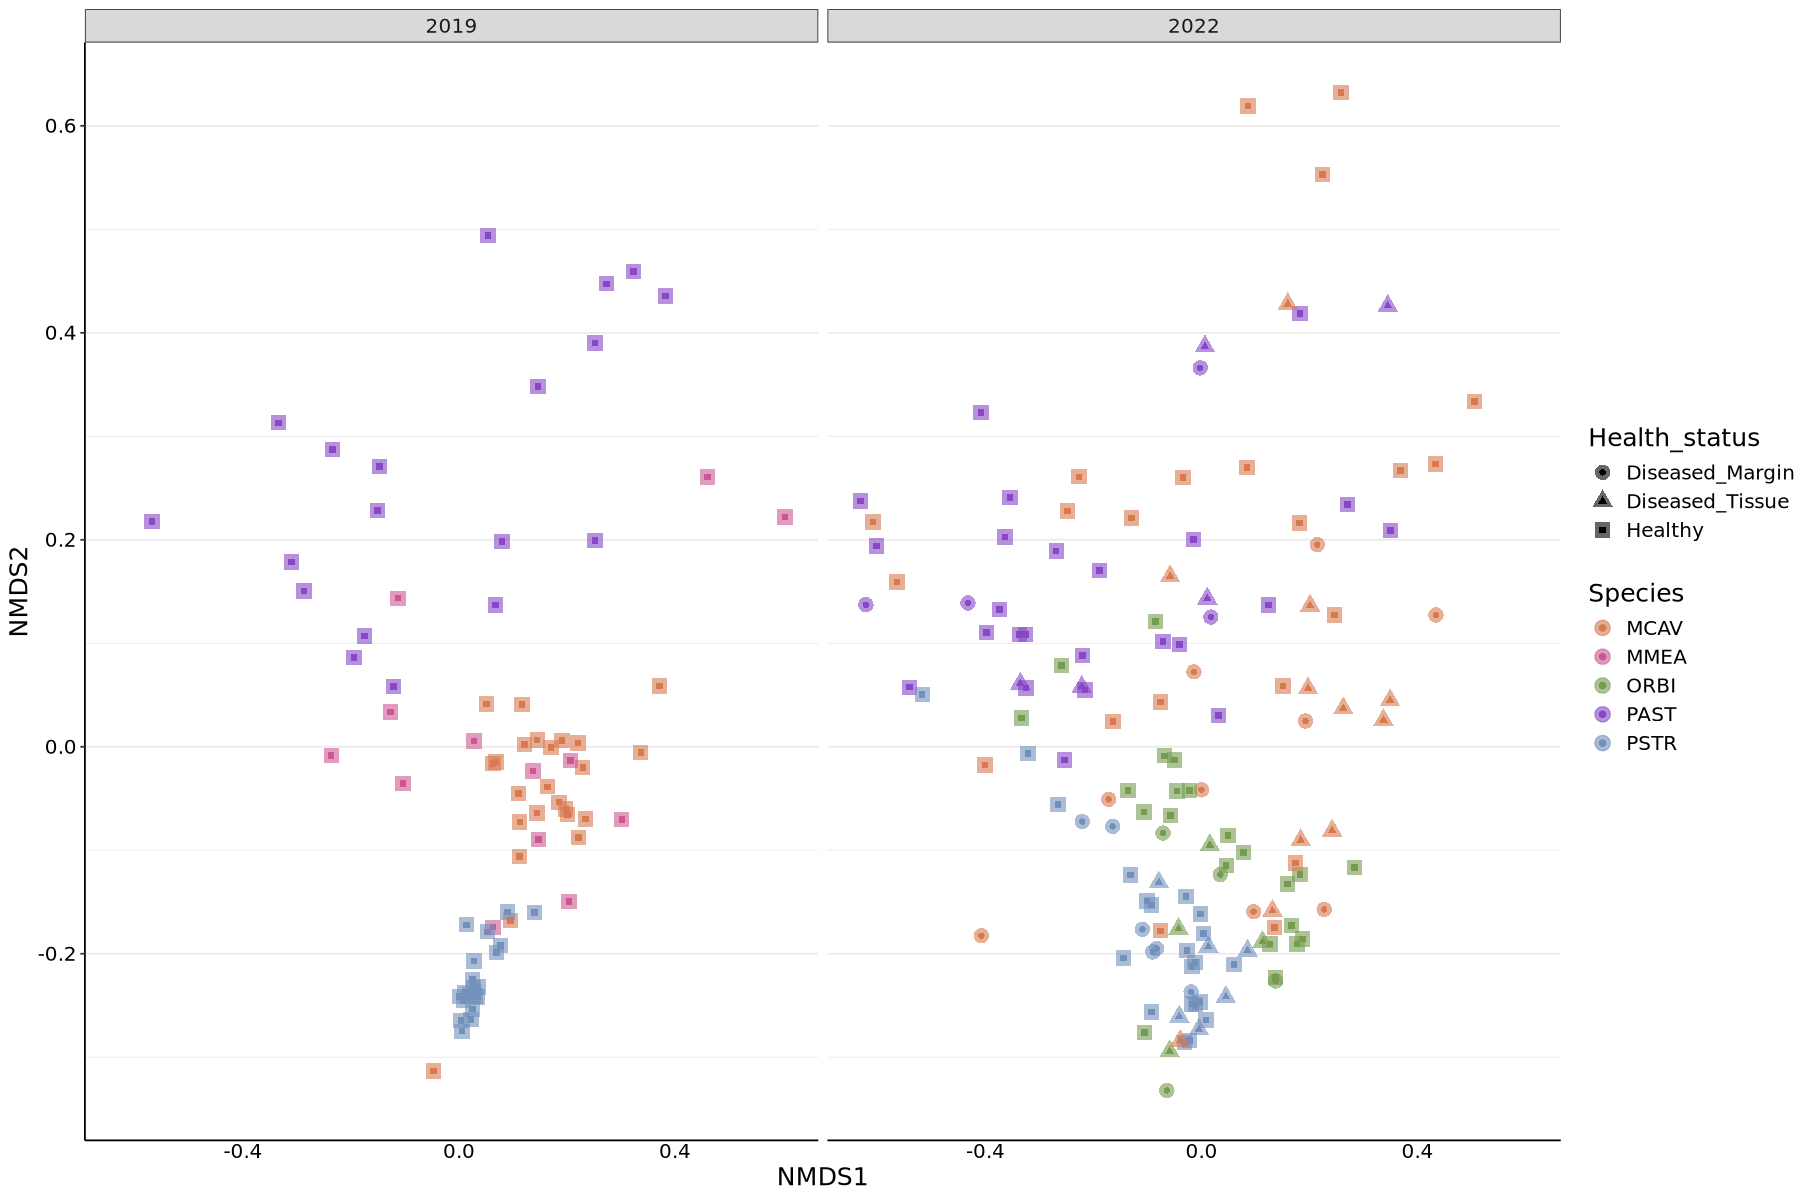

In [41]:
# facet by year
sctld_raw_plot <- plot_ordination(sctld_raw2, sctld_raw2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_raw_plot

# all samples - separated by 2019 and 2022

In [42]:
# 2019 only - RS
RS_ps <- subset_samples(sctld_raw2, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1105056 
Run 1 stress 0.2035144 
Run 2 stress 0.149598 
Run 3 stress 0.1105056 
... New best solution
... Procrustes: rmse 1.054395e-05  max resid 6.257677e-05 
... Similar to previous best
Run 4 stress 0.1105585 
... Procrustes: rmse 0.001846337  max resid 0.01393692 
Run 5 stress 0.1854105 
Run 6 stress 0.1105056 
... Procrustes: rmse 9.058318e-06  max resid 6.263859e-05 
... Similar to previous best
Run 7 stress 0.1105585 
... Procrustes: rmse 0.001848279  max resid 0.01394865 
Run 8 stress 0.2045555 
Run 9 stress 0.151659 
Run 10 stress 0.1105056 
... New best solution
... Procrustes: rmse 3.332176e-06  max resid 1.316649e-05 
... Similar to previous best
Run 11 stress 0.1105056 
... Procrustes: rmse 5.962569e-06  max resid 3.243759e-05 
... Similar to previous best
Run 12 stress 0.195011 
Run 13 stress 0.1105056 
... Procrustes: rmse 9.006746e-06  max resid 4.416008e-05 
... Similar to previous best
Run 14 

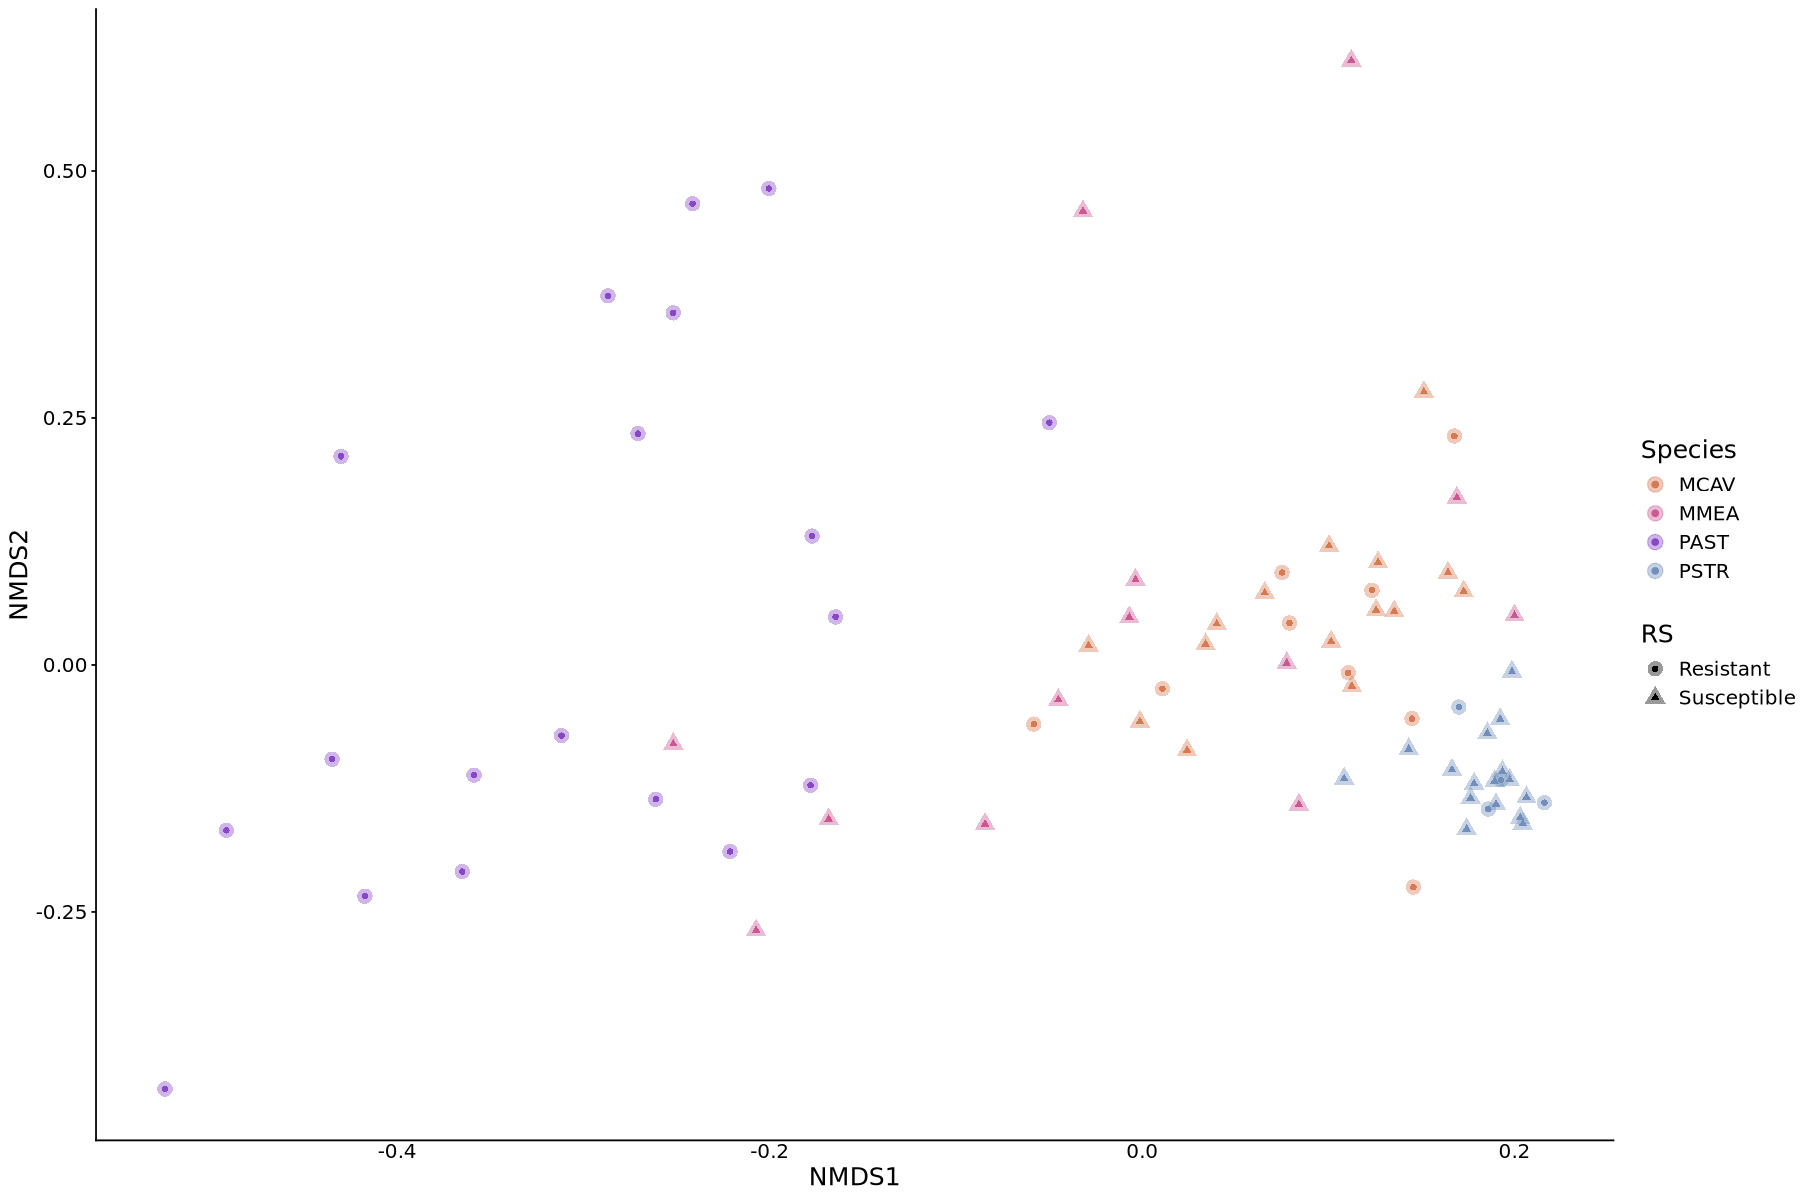

In [43]:
nmds_2019<-plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.4) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
# facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_classic()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
nmds_2019


# 2019 only 

In [44]:
# ggsave(filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/plots/RS_2019_nmds.png", plot = nmds_2019, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

In [45]:
RS.ord
# Stress: 0.108


Call:
metaMDS(comm = veganifyOTU(physeq), distance = distance, trymax = 1000) 

global Multidimensional Scaling using monoMDS

Data:     wisconsin(sqrt(veganifyOTU(physeq))) 
Distance: bray 

Dimensions: 2 
Stress:     0.1105056 
Stress type 1, weak ties
Best solution was repeated 6 times in 20 tries
The best solution was from try 10 (random start)
Scaling: centring, PC rotation, halfchange scaling 
Species: expanded scores based on ‘wisconsin(sqrt(veganifyOTU(physeq)))’ 


Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


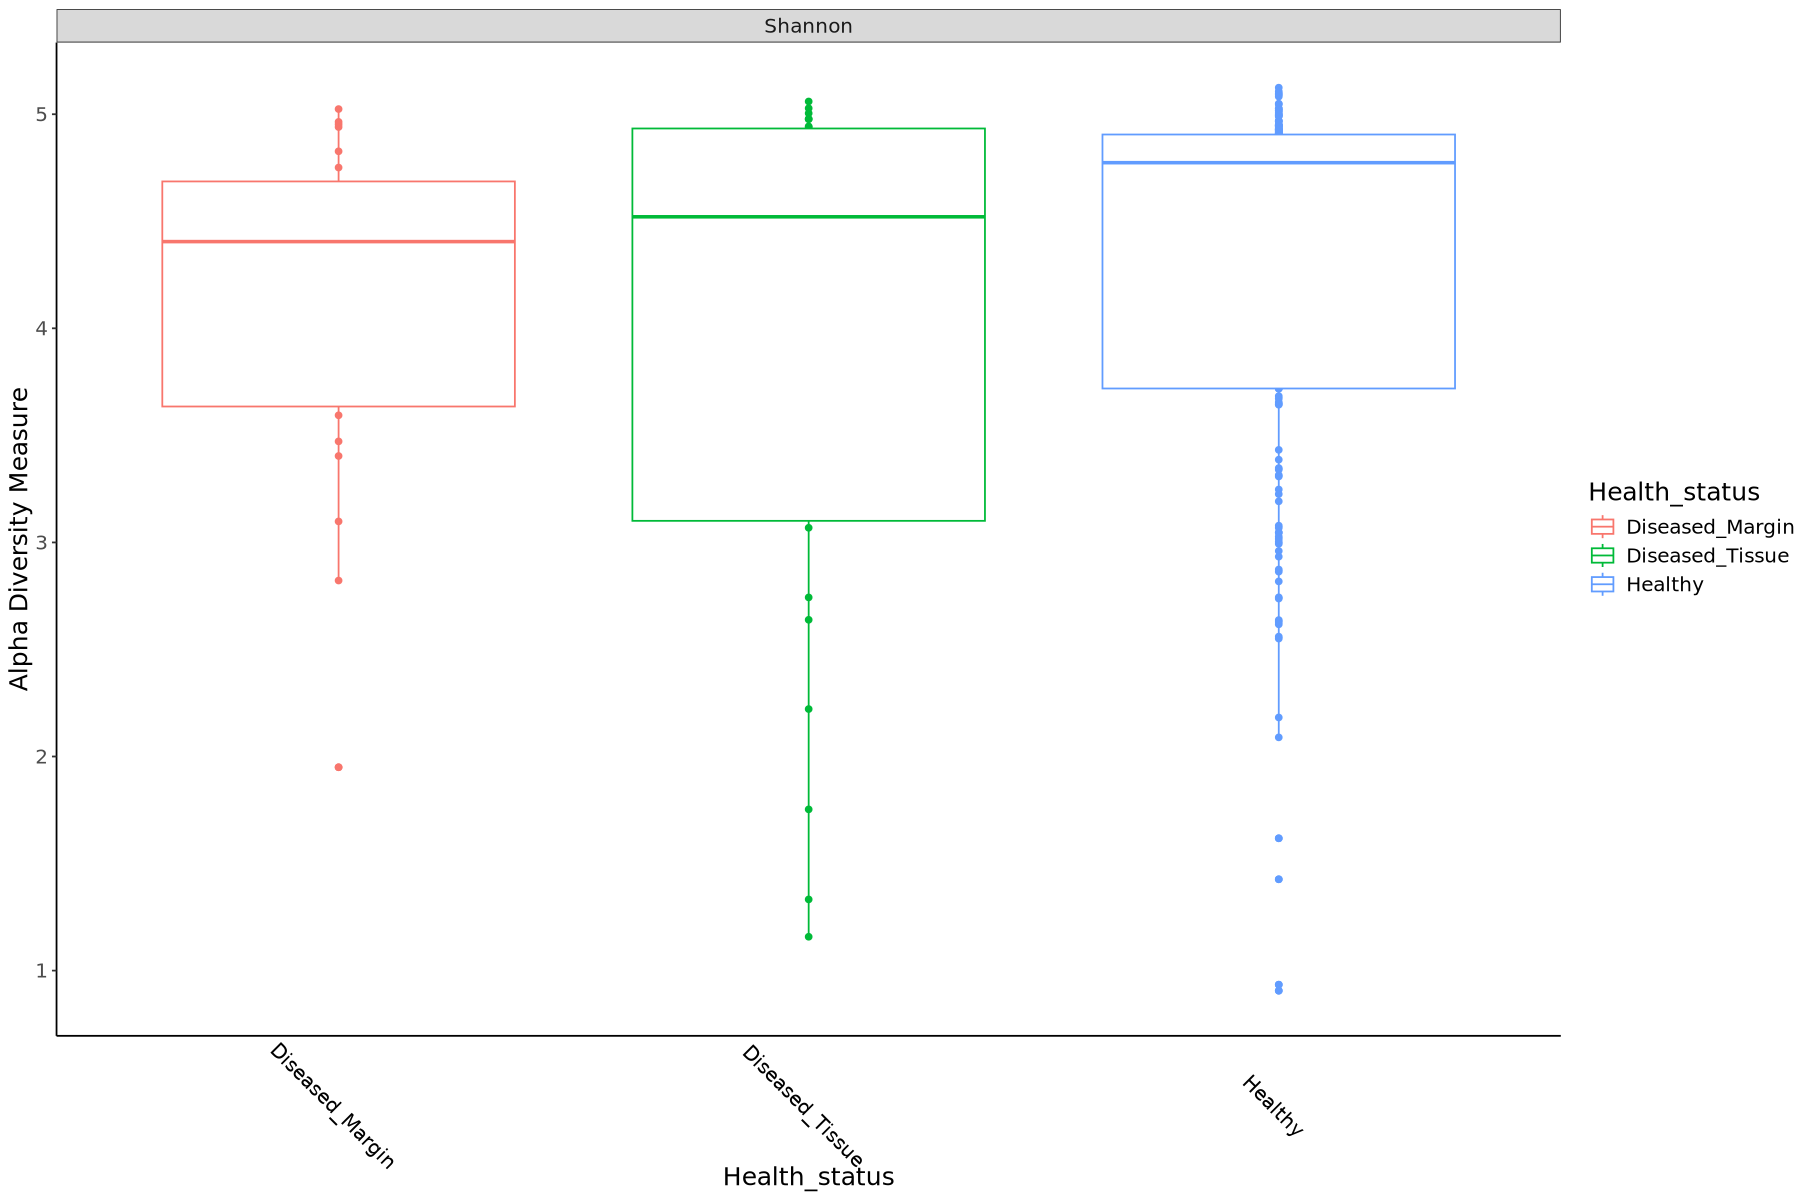

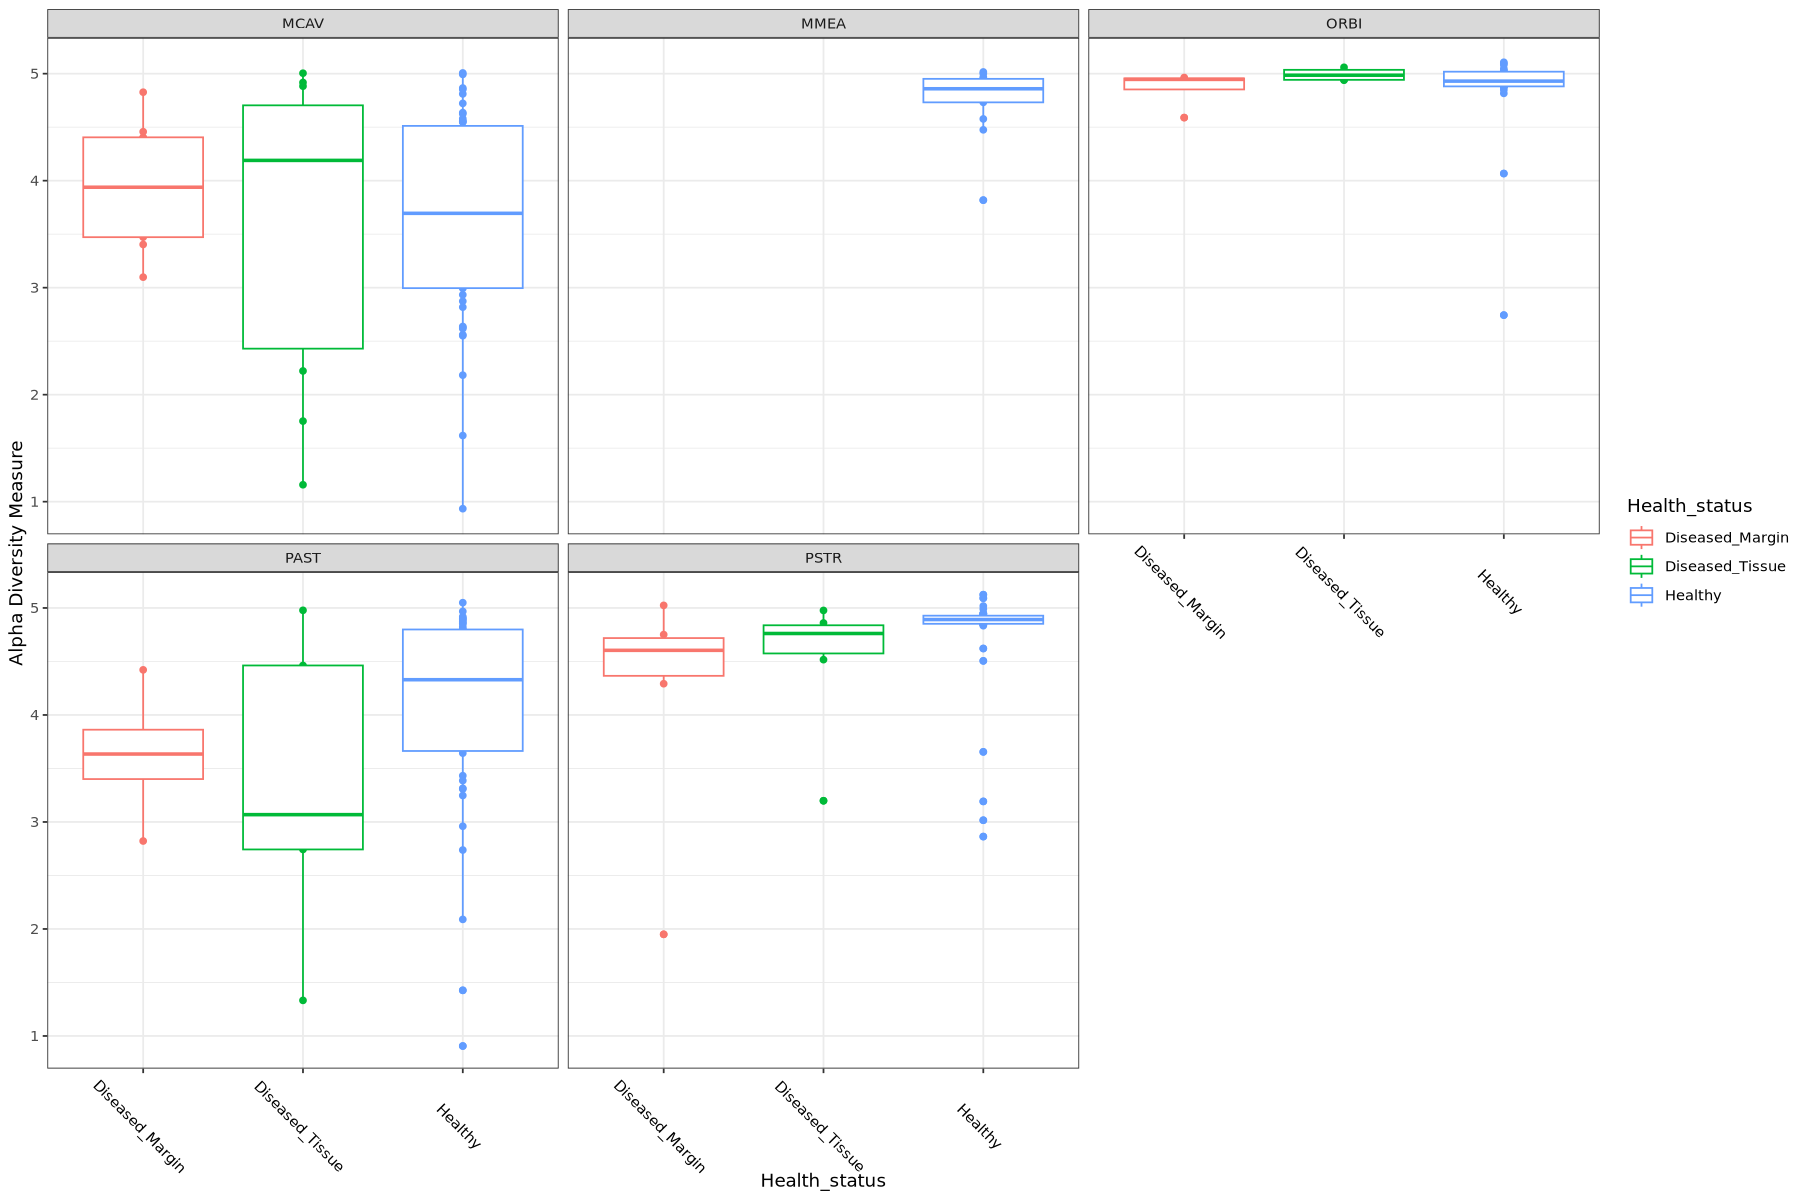

In [46]:
rich_status <- plot_richness(sctld_raw2, x="Health_status", color="Health_status", measures=c("Shannon")) + 
    geom_boxplot() +
    # facet_wrap(~Species)+
    theme_bw()+
     theme(legend.position = "right",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_blank(),
        panel.grid.minor.y = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line = element_line(color = "black"),
        axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
        text = element_text(size = 15))
rich_status

plot_richness(sctld_raw2, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

# all samples - spp x disease status

In [47]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


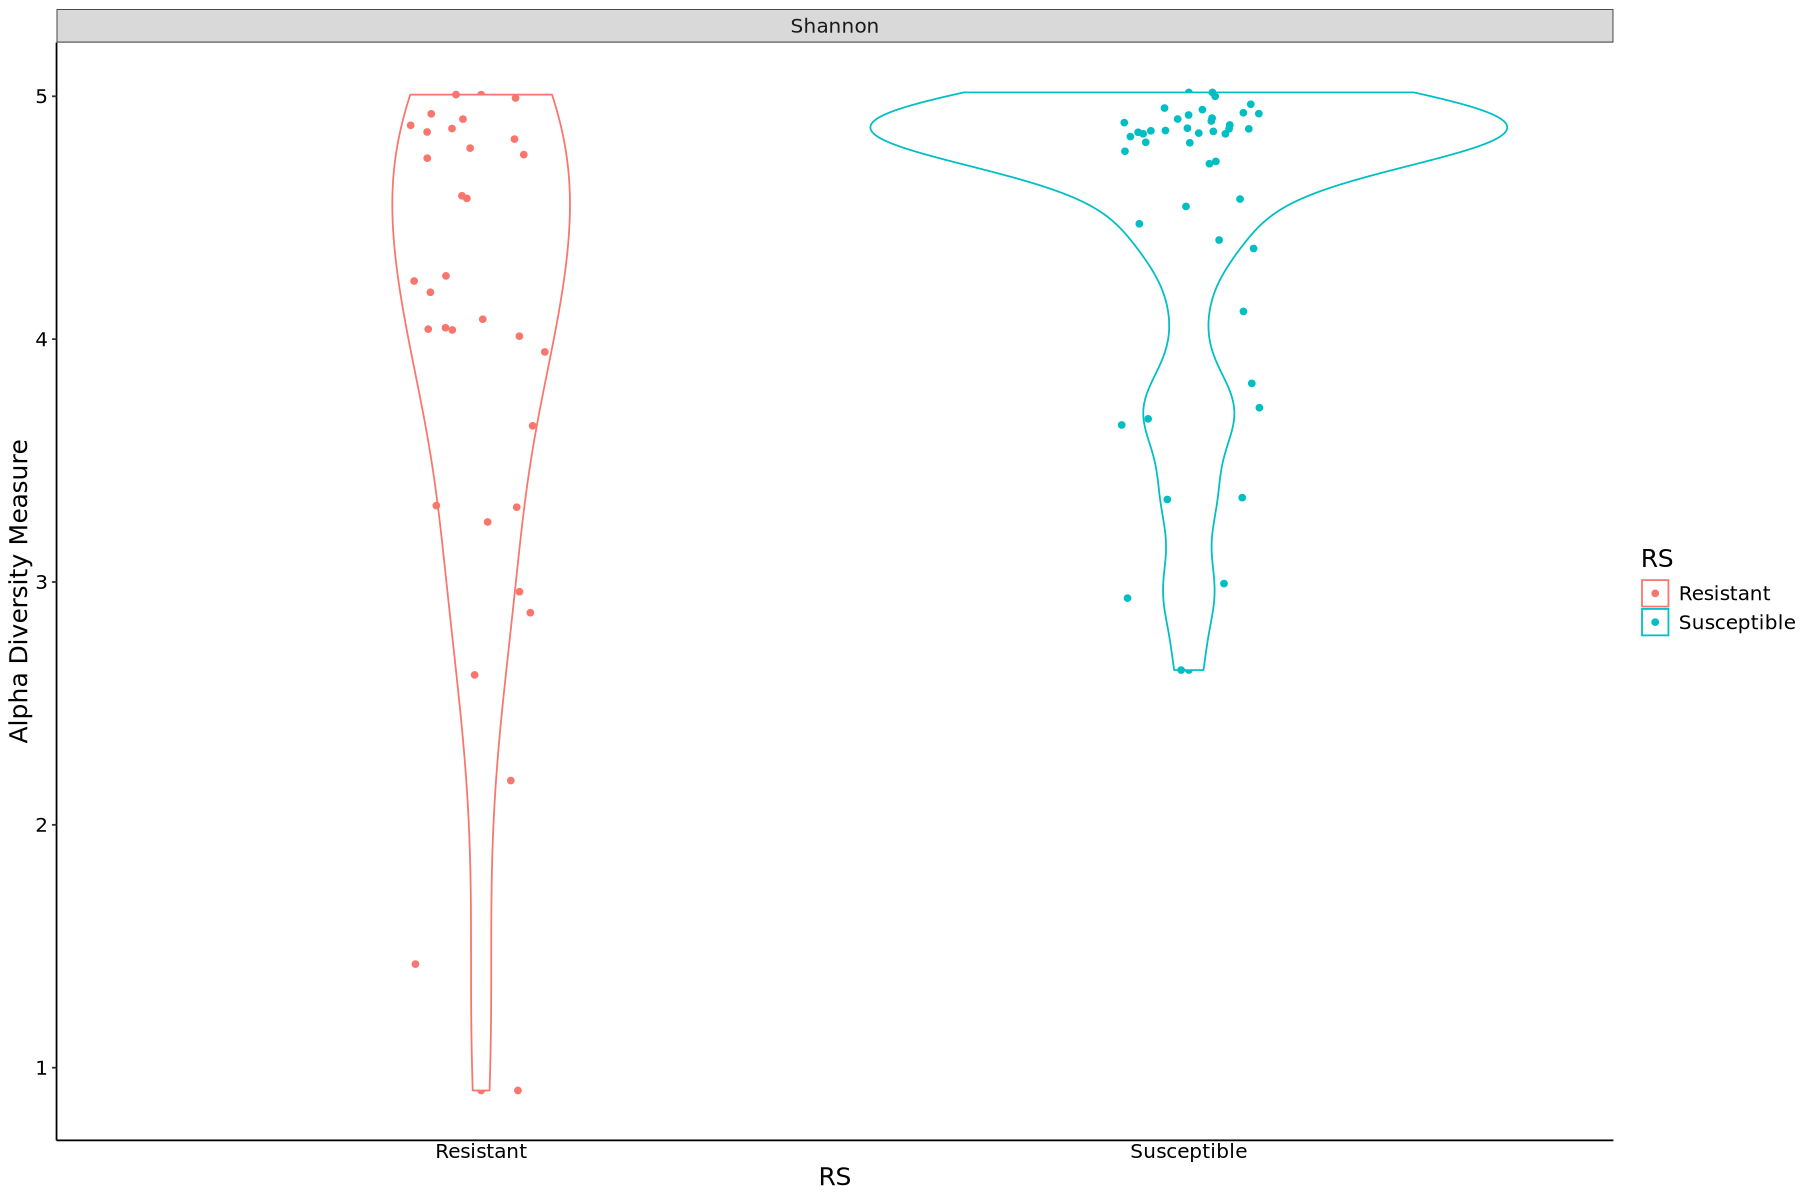

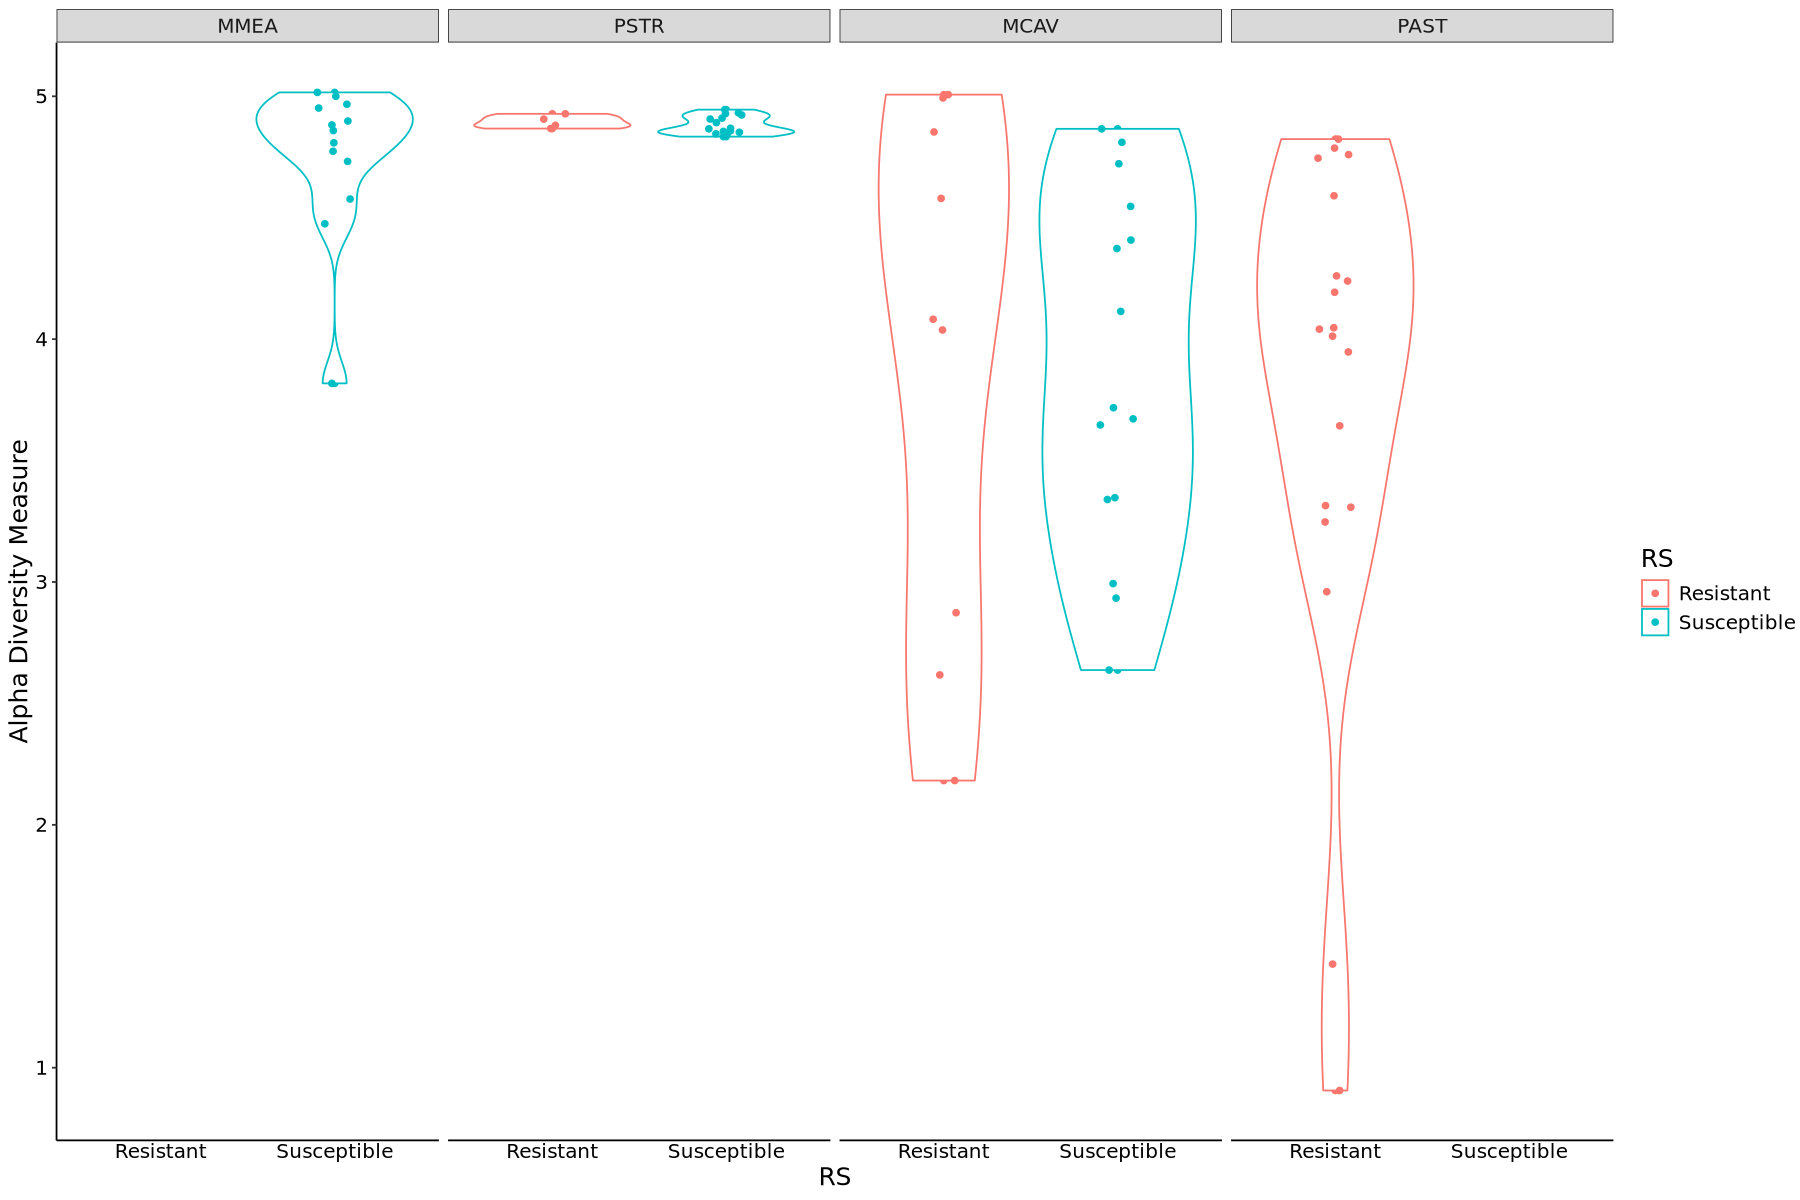

In [48]:
# order of species susceptibility 
# reorder colonies most -> least sus
spp_order<-c("MMEA",'PSTR','MCAV','PAST')
df_meta<-data.frame(sample_data(RS_ps))
sample_data(RS_ps)$Species <-
  factor(sample_data(RS_ps)$Species, levels = spp_order)

rich_status1 <- plot_richness(RS_ps, x="RS", color="RS", measures=c("Shannon")) + geom_violin() +
geom_jitter(height = 0, width = 0.1)+
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_grid(~Species)

# R vs S - 2019 only 

In [49]:
# most susceptible species are more diverse

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


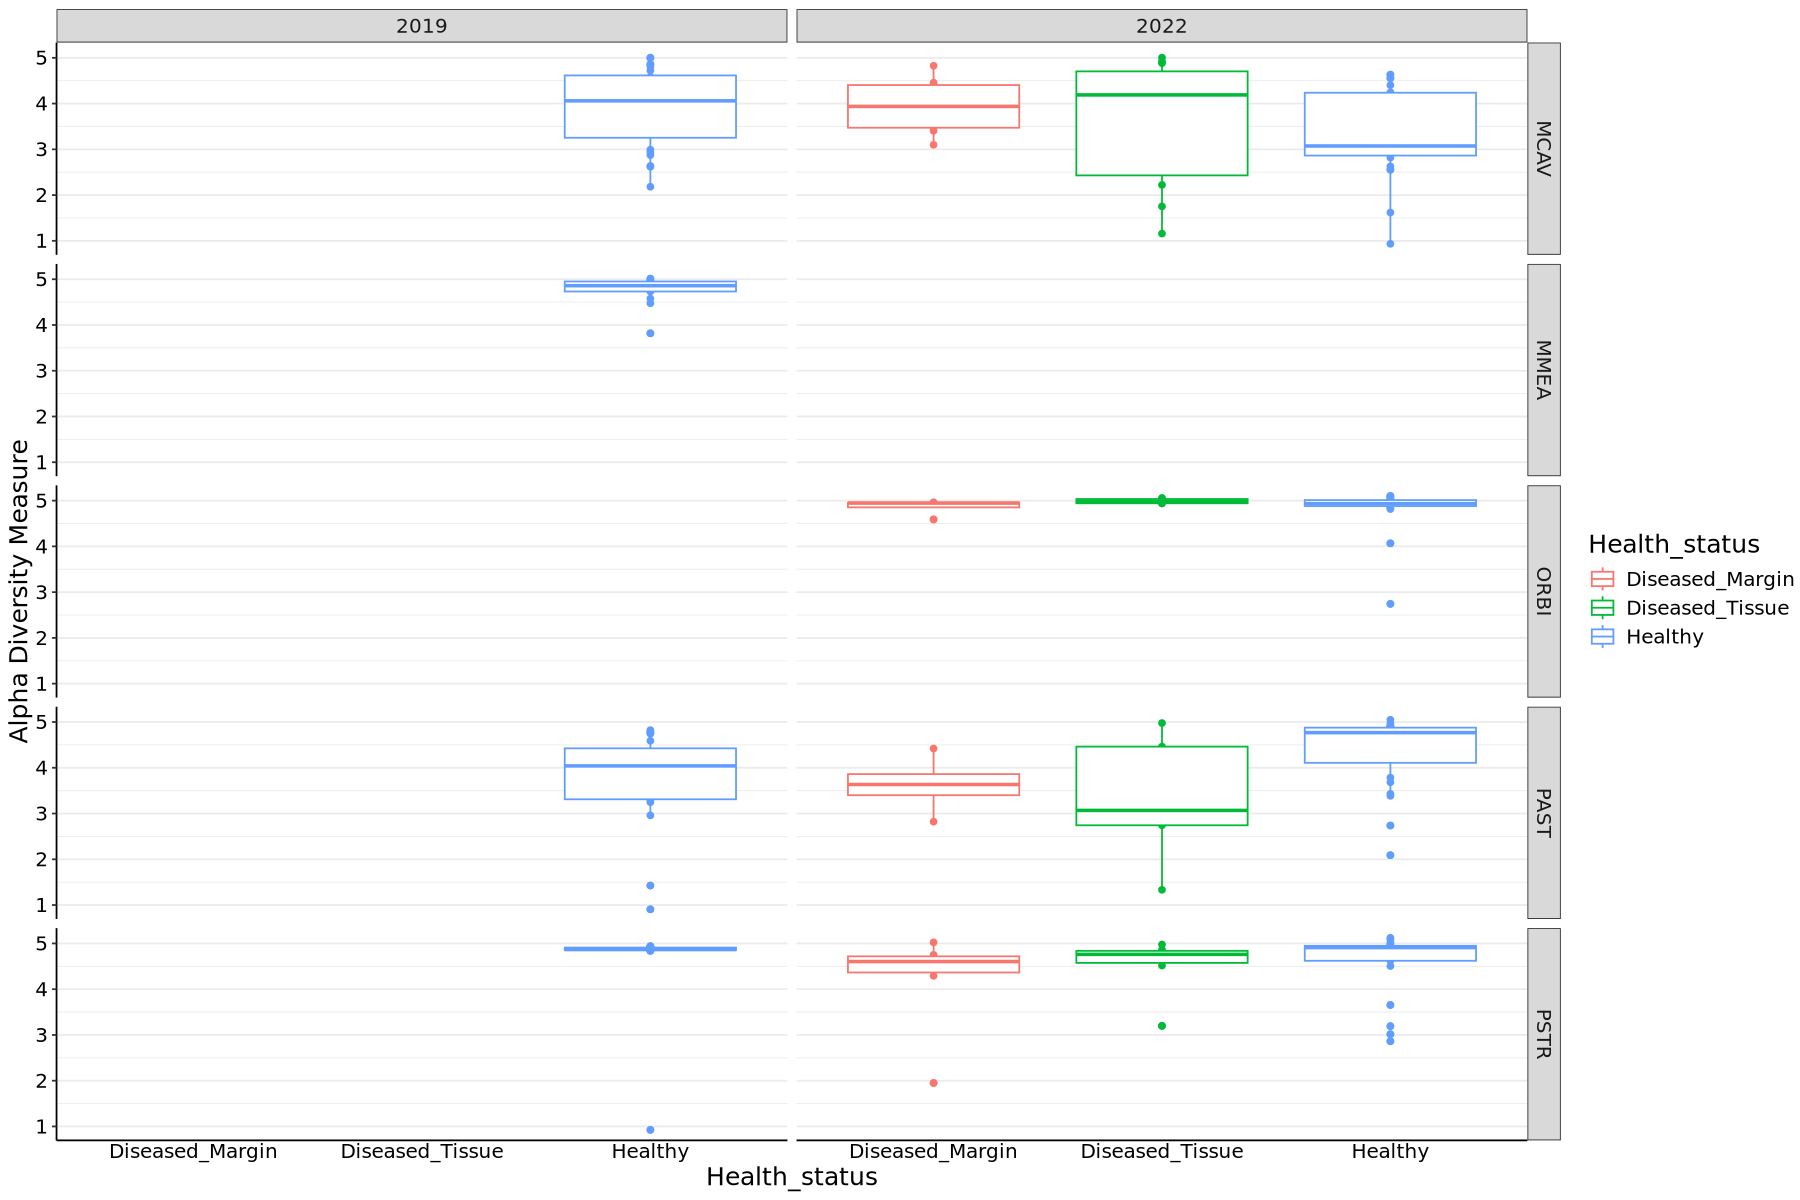

In [50]:
rich_species <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

rich_species+
    facet_grid(Species~year)

# all samples - year x spp x health status

In [51]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(sctld_raw2, method = "bray")
metadata2 <- as(phyloseq::sample_data(sctld_raw2), "data.frame")

In [52]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)
# all samples

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2       F Pr(>F)    
RS                1    1.352 0.03024  8.3573  0.001 ***
Species           4    8.227 0.18401 12.7124  0.001 ***
year              1    1.477 0.03303  9.1290  0.001 ***
RS:Species        2    0.224 0.00501  0.6917  0.760    
RS:year           1    0.116 0.00260  0.7187  0.627    
Species:year      2    0.678 0.01517  2.0964  0.018 *  
RS:Species:year   1    0.116 0.00258  0.7141  0.620    
Residual        201   32.519 0.72735                   
Total           213   44.709 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [53]:
permanova2 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
                       Df SumOfSqs      R2       F Pr(>F)    
Health_status           2    0.683 0.01528  2.1442  0.018 *  
RS                      1    1.747 0.03909 10.9679  0.001 ***
Species                 4    8.093 0.18103 12.6998  0.001 ***
year                    1    1.091 0.02441  6.8488  0.001 ***
Health_status:RS        2    0.294 0.00658  0.9234  0.497    
Health_status:Species   4    0.590 0.01319  0.9255  0.578    
RS:Species              2    0.239 0.00536  0.7516  0.709    
RS:year                 1    0.172 0.00385  1.0793  0.350    
Species:year            2    0.641 0.01434  2.0114  0.031 *  
RS:Species:year         1    0.408 0.00912  2.5588  0.017 *  
Residual              193   30.749 0.68777                   
Total   

In [54]:
permanova3 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.683 0.01528  2.1559  0.018 *  
RS                               1    1.747 0.03909 11.0279  0.001 ***
Species                          4    8.093 0.18103 12.7692  0.001 ***
year                             1    1.091 0.02441  6.8862  0.001 ***
Transect                         3    1.042 0.02330  2.1918  0.004 ** 
Health_status:RS                 2    0.305 0.00683  0.9636  0.458    
Health_status:Species            4    0.553 0.01237  0.8724  0.612    
RS:Species                       2    0.228 0.00510  0.7194  0.714    
RS:year                          1    0.122 0.00273  0.7715  0.577    
Species:year                   

In [55]:
# location is more important than health status?

In [56]:
# look at 2022 subset - how much does health status vary
dis_ps<- subset_samples(sctld_raw2, year == '2022')
bray_dist <- phyloseq::distance(dis_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(dis_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2   0.6193 0.02030  1.7709  0.057 .  
Species                          3   6.0124 0.19707 11.4625  0.001 ***
Transect                         3   1.1970 0.03923  2.2820  0.003 ** 
Health_status:Species            6   1.0060 0.03298  0.9590  0.521    
Health_status:Transect           6   0.9868 0.03234  0.9406  0.568    
Species:Transect                 8   1.9310 0.06330  1.3806  0.052 .  
Health_status:Species:Transect  10   1.4465 0.04741  0.8273  0.807    
Residual                        99  17.3094 0.56736                   
Total                          137  30.5085 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 

In [57]:
# species is more important than health status - same as from prelim results

In [58]:
#mcav only
# look at 2022 subset - how much does health status vary
mcav_ps<- subset_samples(sctld_raw2, Species == "MCAV" & year == '2022')
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.5824 0.06586 1.4835  0.144  
RS                      1   0.4471 0.05055 2.2774  0.033 *
Transect                3   0.7972 0.09015 1.3537  0.152  
Health_status:Transect  4   0.9312 0.10530 1.1860  0.243  
Residual               31   6.0854 0.68813                
Total                  41   8.8434 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [59]:
orbi_ps<- subset_samples(sctld_raw2, Species == "ORBI")
bray_dist <- phyloseq::distance(orbi_ps, method = "bray")
orbi_meta <- as(phyloseq::sample_data(orbi_ps), "data.frame")
orbi_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
print(orbi_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2  0.24200 0.07737 1.1694  0.303  
RS                      1  0.08077 0.02582 0.7806  0.479  
Transect                3  0.59436 0.19002 1.9148  0.068 .
Health_status:Transect  4  0.25989 0.08309 0.6279  0.773  
RS:Transect             1  0.08850 0.02829 0.8553  0.445  
Residual               18  1.86245 0.59542                
Total                  29  3.12798 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [60]:
# maybe we do need to separate out orbi species...

In [61]:
# 2019 only 

In [62]:
bray_dist <- phyloseq::distance(RS_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(RS_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
                    Df SumOfSqs      R2      F Pr(>F)    
RS                   1   0.7277 0.05726 5.7360  0.001 ***
Species              3   3.2591 0.25644 8.5631  0.001 ***
Transect             2   0.1900 0.01495 0.7489  0.672    
RS:Species           1   0.0594 0.00468 0.4685  0.827    
RS:Transect          2   0.1720 0.01353 0.6778  0.788    
Species:Transect     6   0.7174 0.05645 0.9425  0.542    
RS:Species:Transect  1   0.0985 0.00775 0.7761  0.517    
Residual            59   7.4851 0.58895                  
Total               75  12.7092 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [63]:
# within species, how much does RS explain difference

In [64]:
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~  RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Transect, data = mcav_meta, permutations = 999)
            Df SumOfSqs      R2      F Pr(>F)
RS           1  0.12215 0.04344 1.0389  0.374
Transect     2  0.22433 0.07978 0.9540  0.433
RS:Transect  2  0.34928 0.12421 1.4854  0.173
Residual    18  2.11632 0.75258              
Total       23  2.81209 1.00000              


### Taxa Bar Plots

In [65]:
# subset taxa and normalzie out of 100 - family level
sctld_raw_10 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:10]), sctld_raw)
sctld_raw_10_norm <- transform_sample_counts(sctld_raw_10, function(x) x / sum(x))
     
sctld_raw_30 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:30]), sctld_raw)
sctld_raw_30_norm <- transform_sample_counts(sctld_raw_30, function(x) x / sum(x))

sctld_raw_100 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:100]), sctld_raw)
sctld_raw_100_norm <- transform_sample_counts(sctld_raw_100, function(x) x / sum(x))

In [66]:
g_colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )

In [67]:
# add 16S top family list
colors_16s<-readRDS("/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/family16s_colors.rds")

In [68]:
length(colors_16s)

[1] 130

In [69]:
# map list of 100 genera to same color
top100_names <- as.character(tax_table(sctld_raw_100)[, "family"])
names(g_colors) <- top100_names

In [70]:
# which taxa are missing from colors list 
length(setdiff(top100_names, names(colors_16s)))
missing_fam<-setdiff(top100_names, names(colors_16s))

[1] 73

In [71]:
# add more colors 
new_73_colors <- grDevices::colorRampPalette(
  c("#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E", "#E6AB02", "#A6761D", "#666666")
)(73)
colors <- c(colors_16s, new_73_colors)

In [72]:
length(colors)
length(missing_fam)

[1] 203

[1] 73

In [73]:
130+73

[1] 203

In [75]:
# index last named color in the list 
last_named_pos <- length(names(colors)[names(colors) != "" & !is.na(names(colors))])
target_slots <- (last_named_pos + 1):(last_named_pos + length(missing_fam))

# add new colors (from top metagenomics families) to existing colors list
names(colors)[target_slots] <- missing_fam

In [76]:
options(repr.plot.height = 15, repr.plot.width = 30)

In [77]:
sctld_raw
25486 # taxa at species level from pstr and mcav prelim...
15891 # taxa at species level 
3655 # taxa at family level 

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 915 taxa and 216 samples ]
sample_data() Sample Data:       [ 216 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 915 taxa by 1 taxonomic ranks ]

[1] 25486

[1] 15891

[1] 3655

#### All Spp

In [78]:
# try just each spp R vs S in 2019
sctld_100_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:100]), RS_ps)
sctld_100_2019_norm <- transform_sample_counts(sctld_100_2019, function(x) x / sum(x))

sctld_50_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:50]), RS_ps)
sctld_50_2019_norm <- transform_sample_counts(sctld_50_2019, function(x) x / sum(x))

sctld_30_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:30]), RS_ps)
sctld_30_2019_norm <- transform_sample_counts(sctld_30_2019, function(x) x / sum(x))
                                              
sctld_10_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:10]), RS_ps)
sctld_10_2019_norm <- transform_sample_counts(sctld_10_2019, function(x) x / sum(x))

In [79]:
options(repr.plot.height = 15, repr.plot.width = 18)

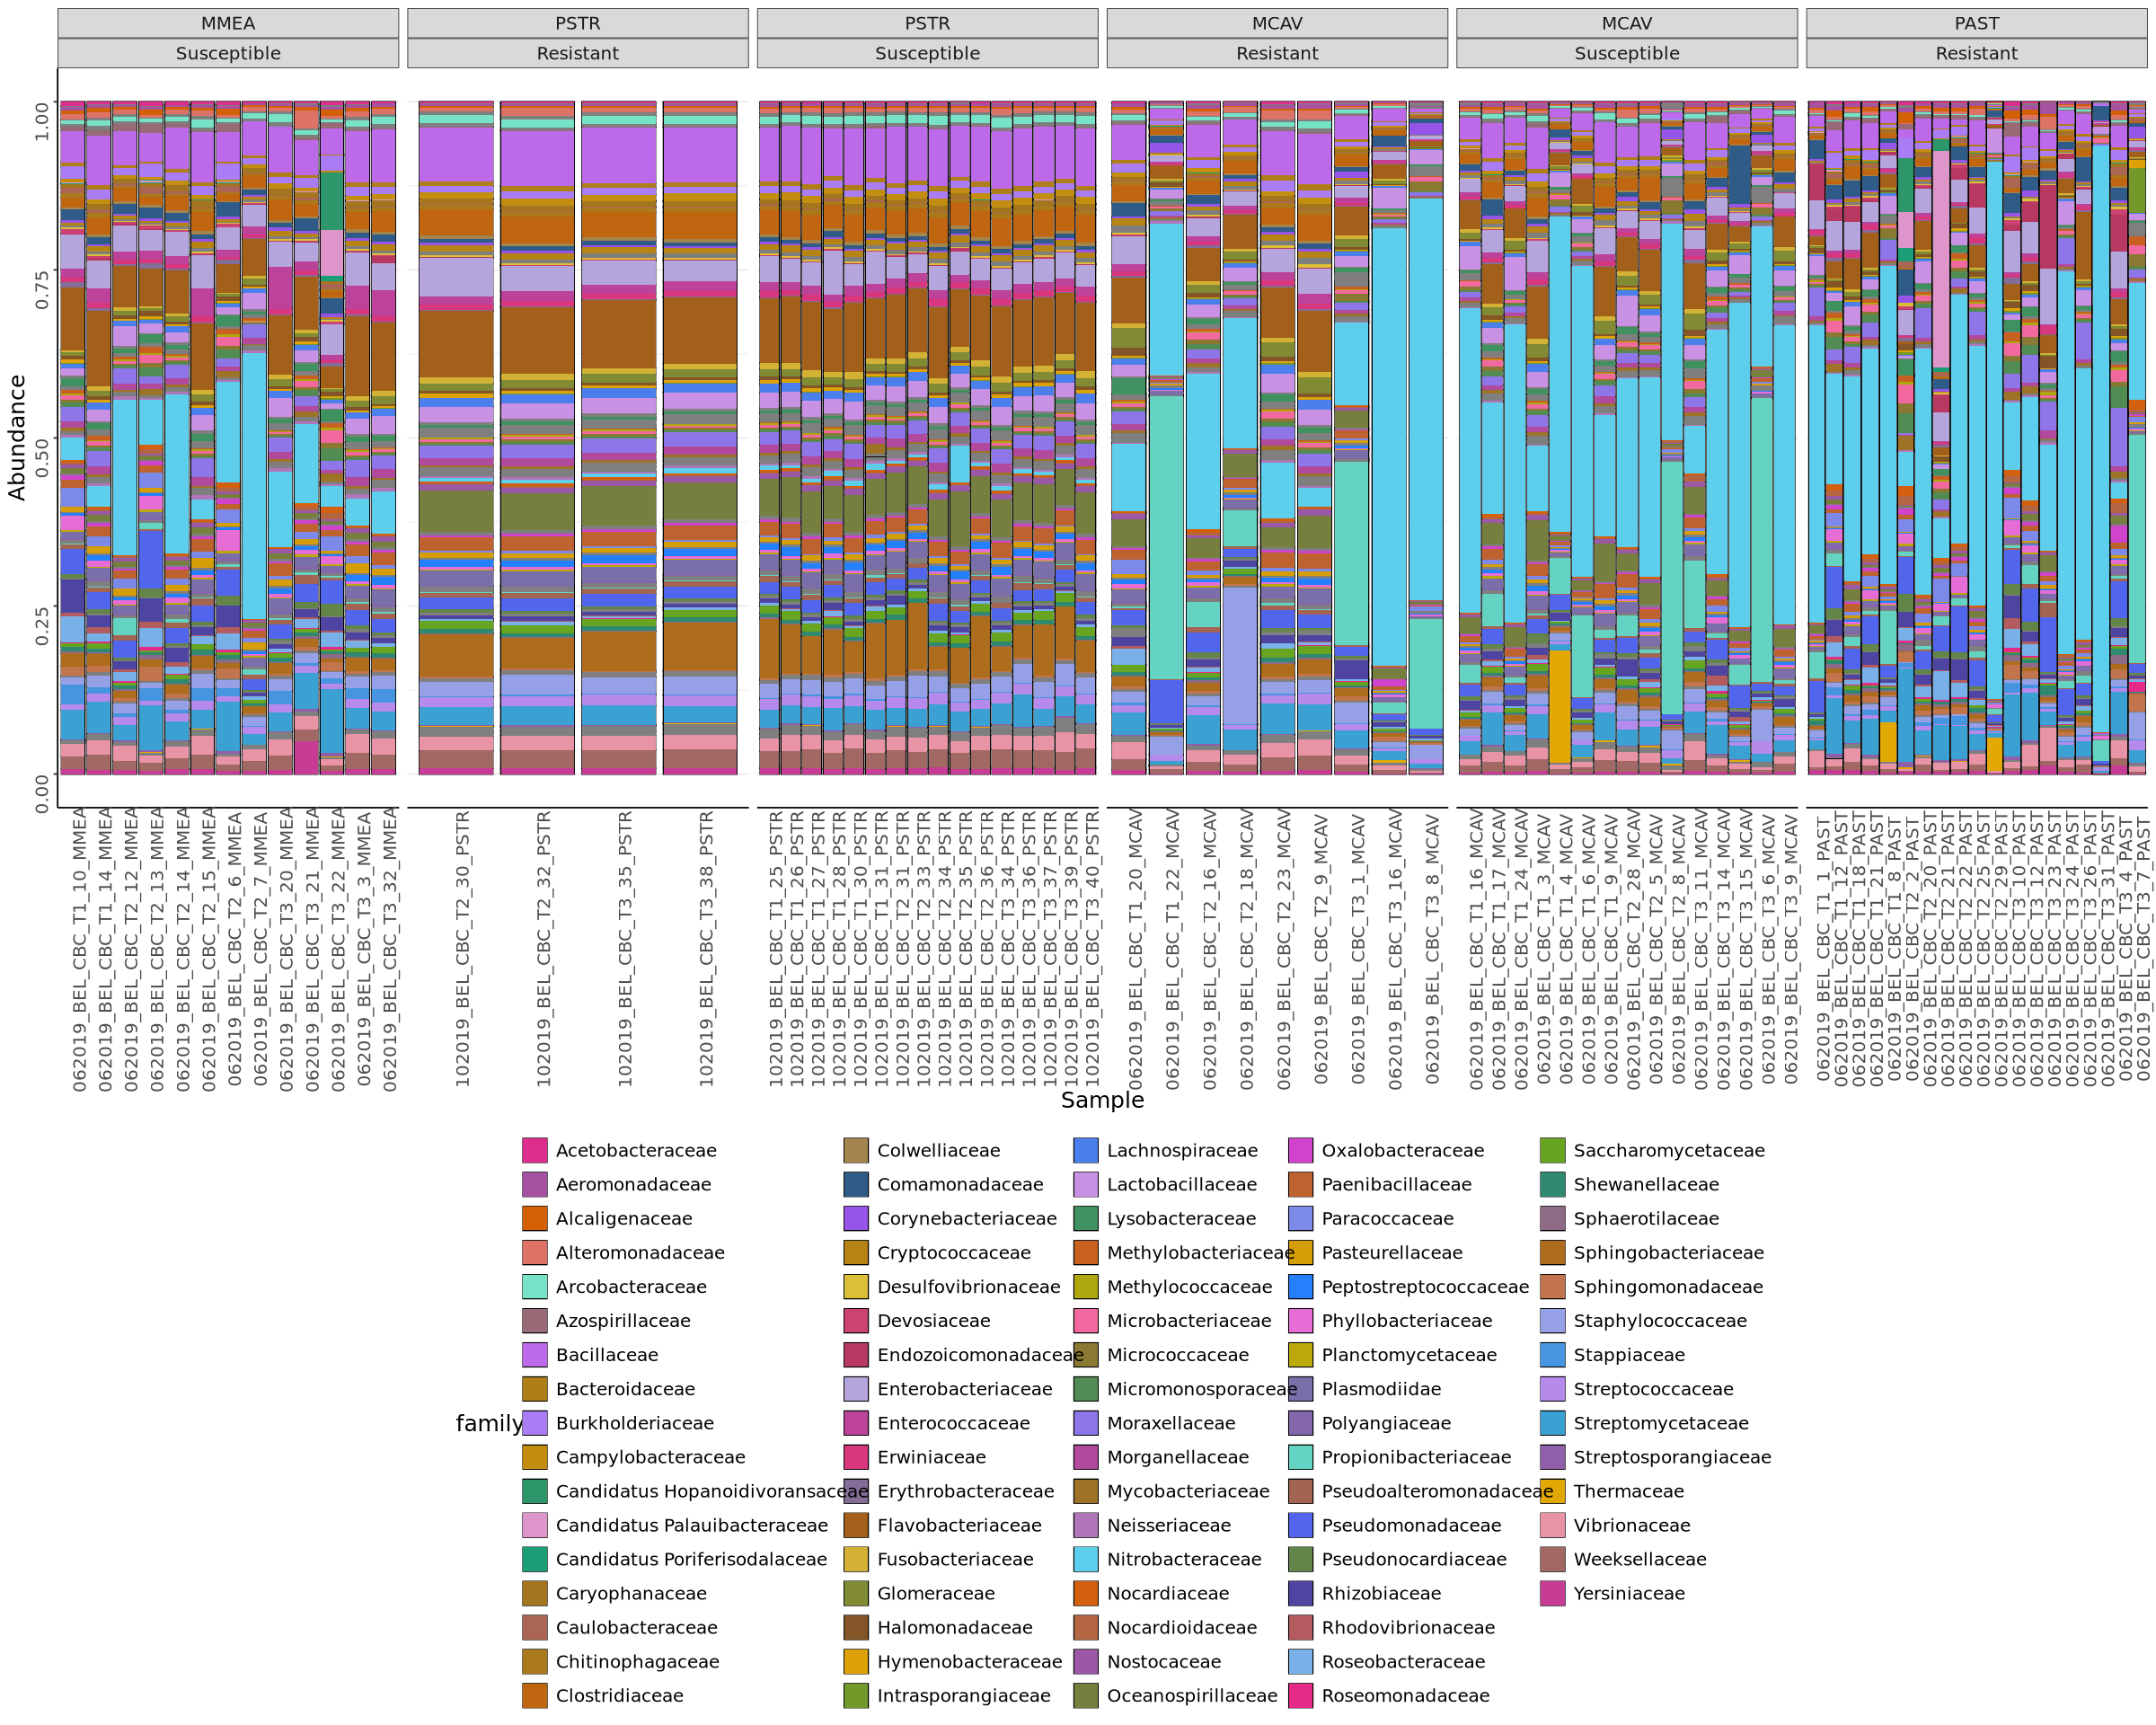

In [124]:
plot_bar(sctld_100_2019_norm,x = "Sample",fill='family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# 2019: Top 100 OTUs (family)

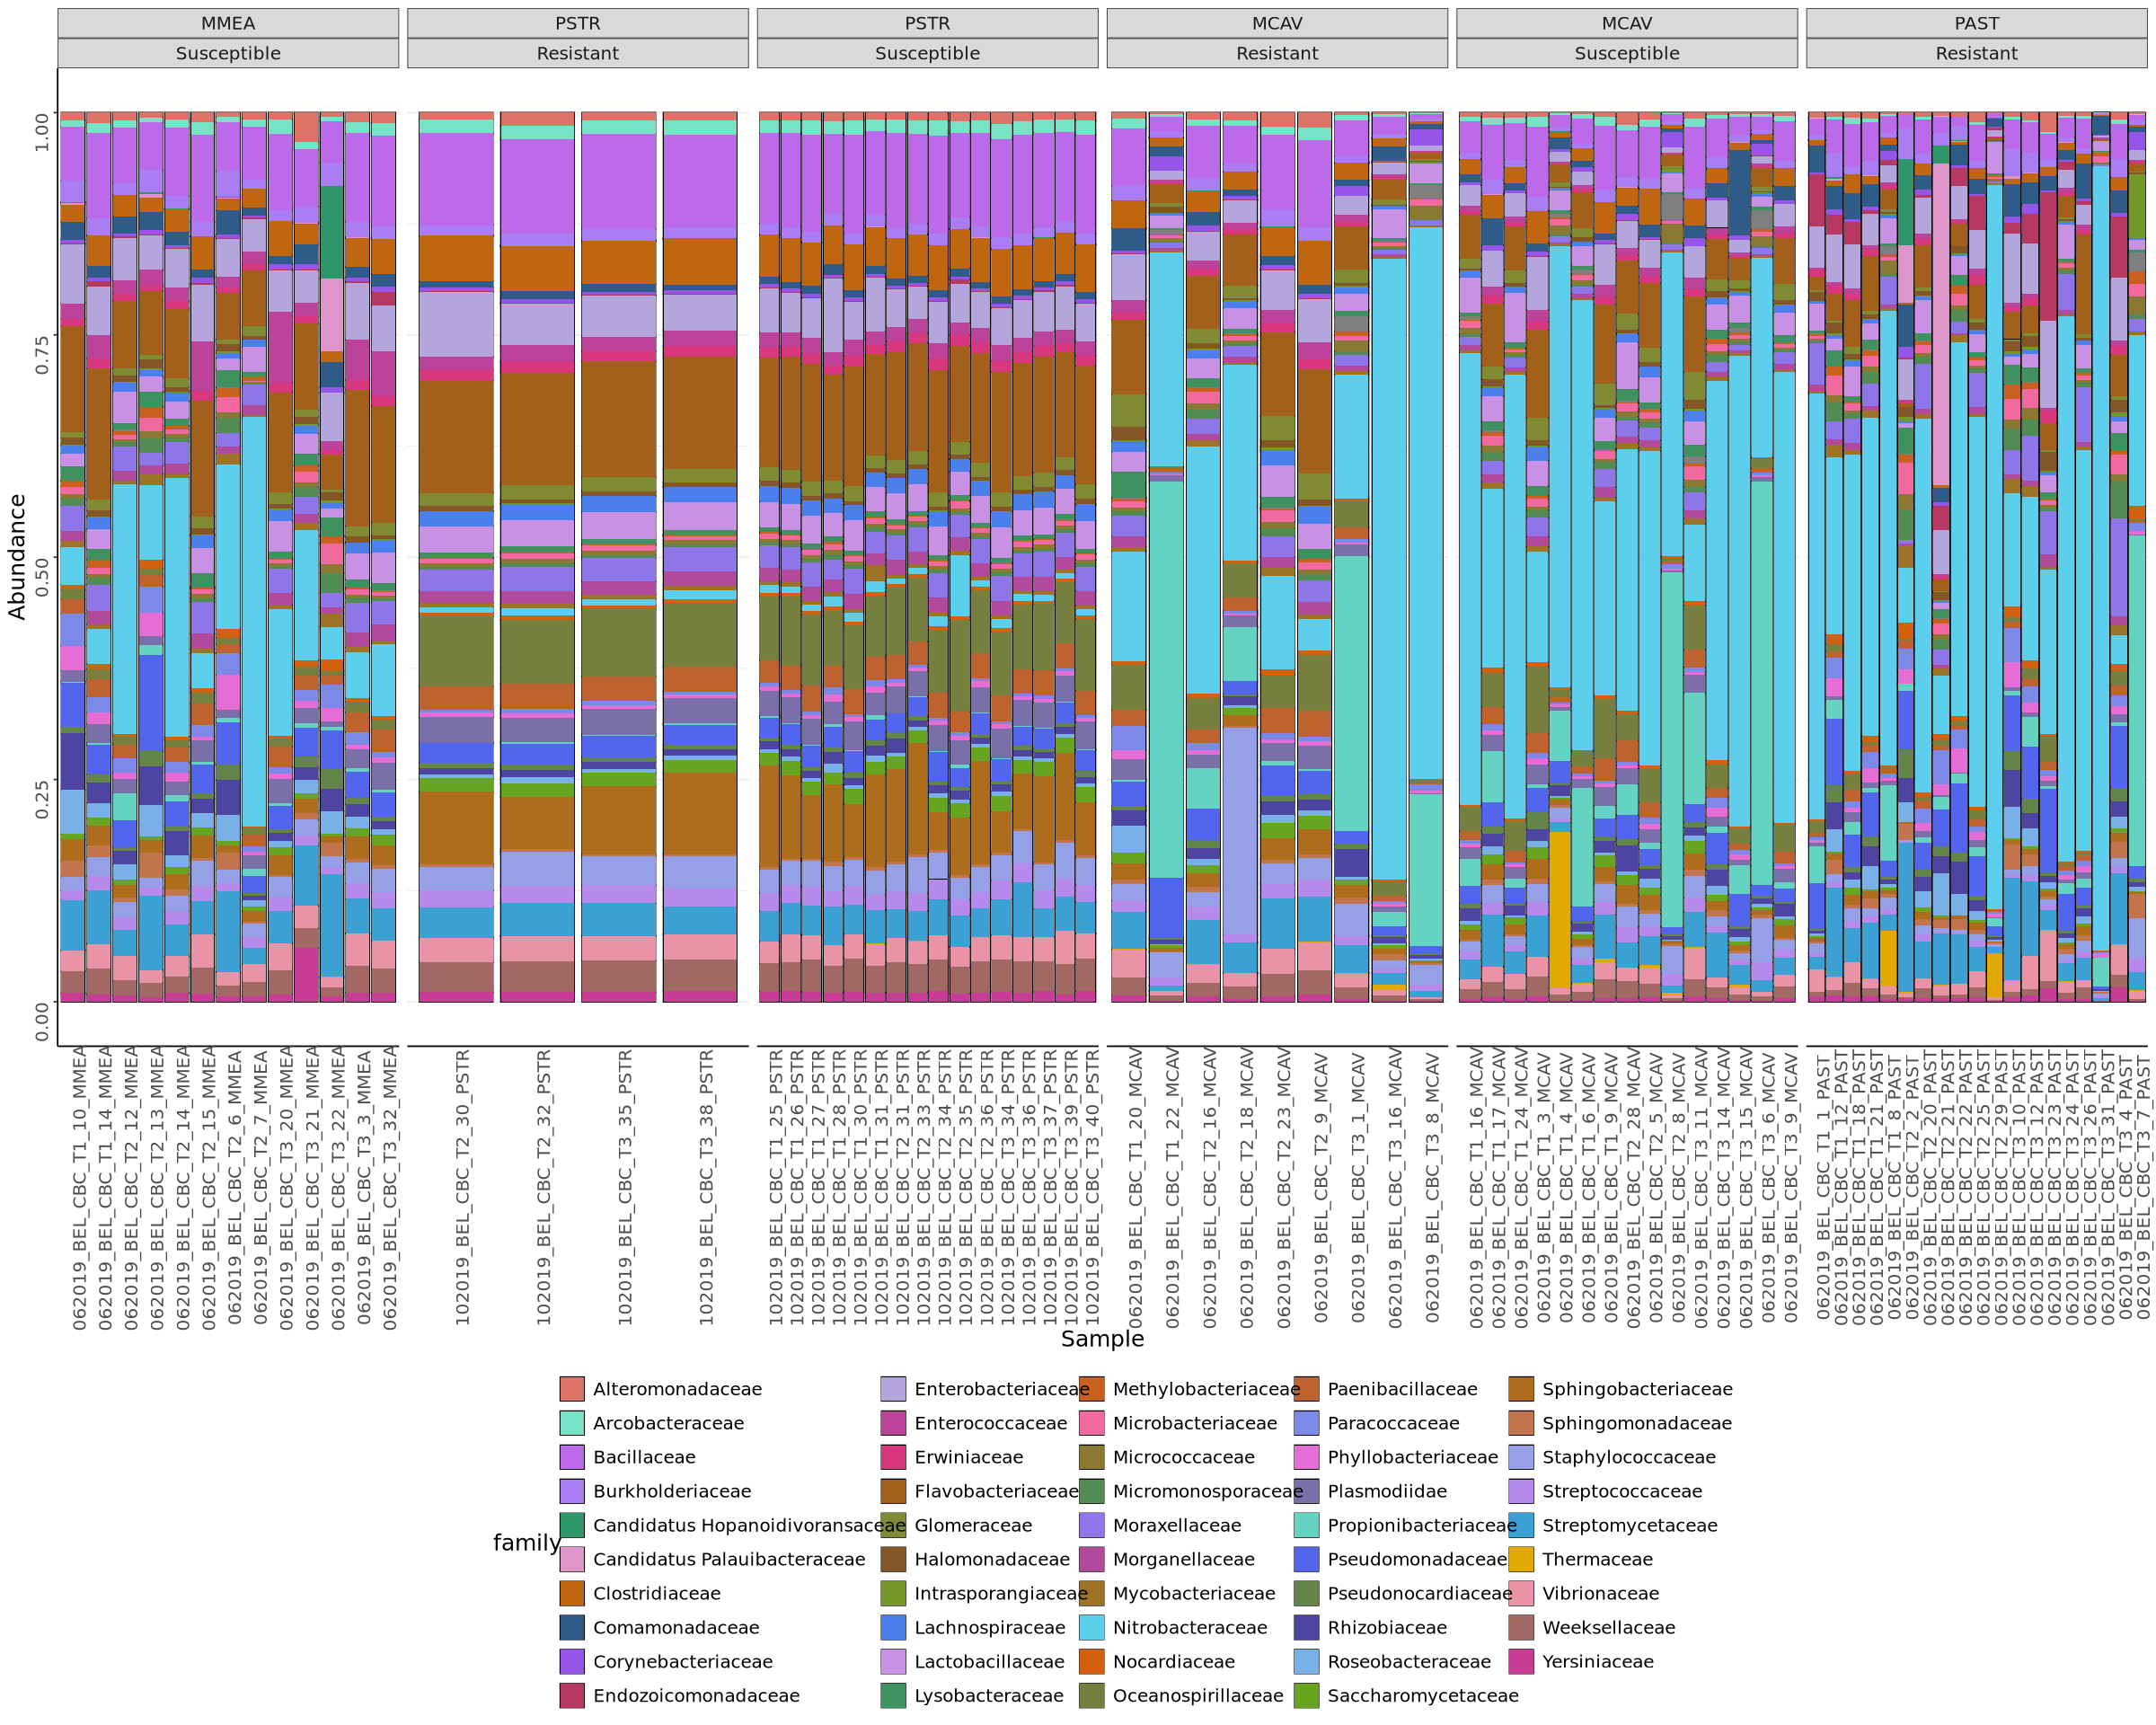

In [125]:
plot_bar(sctld_50_2019_norm,x = "Sample",fill='family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 50 family 2019 only 

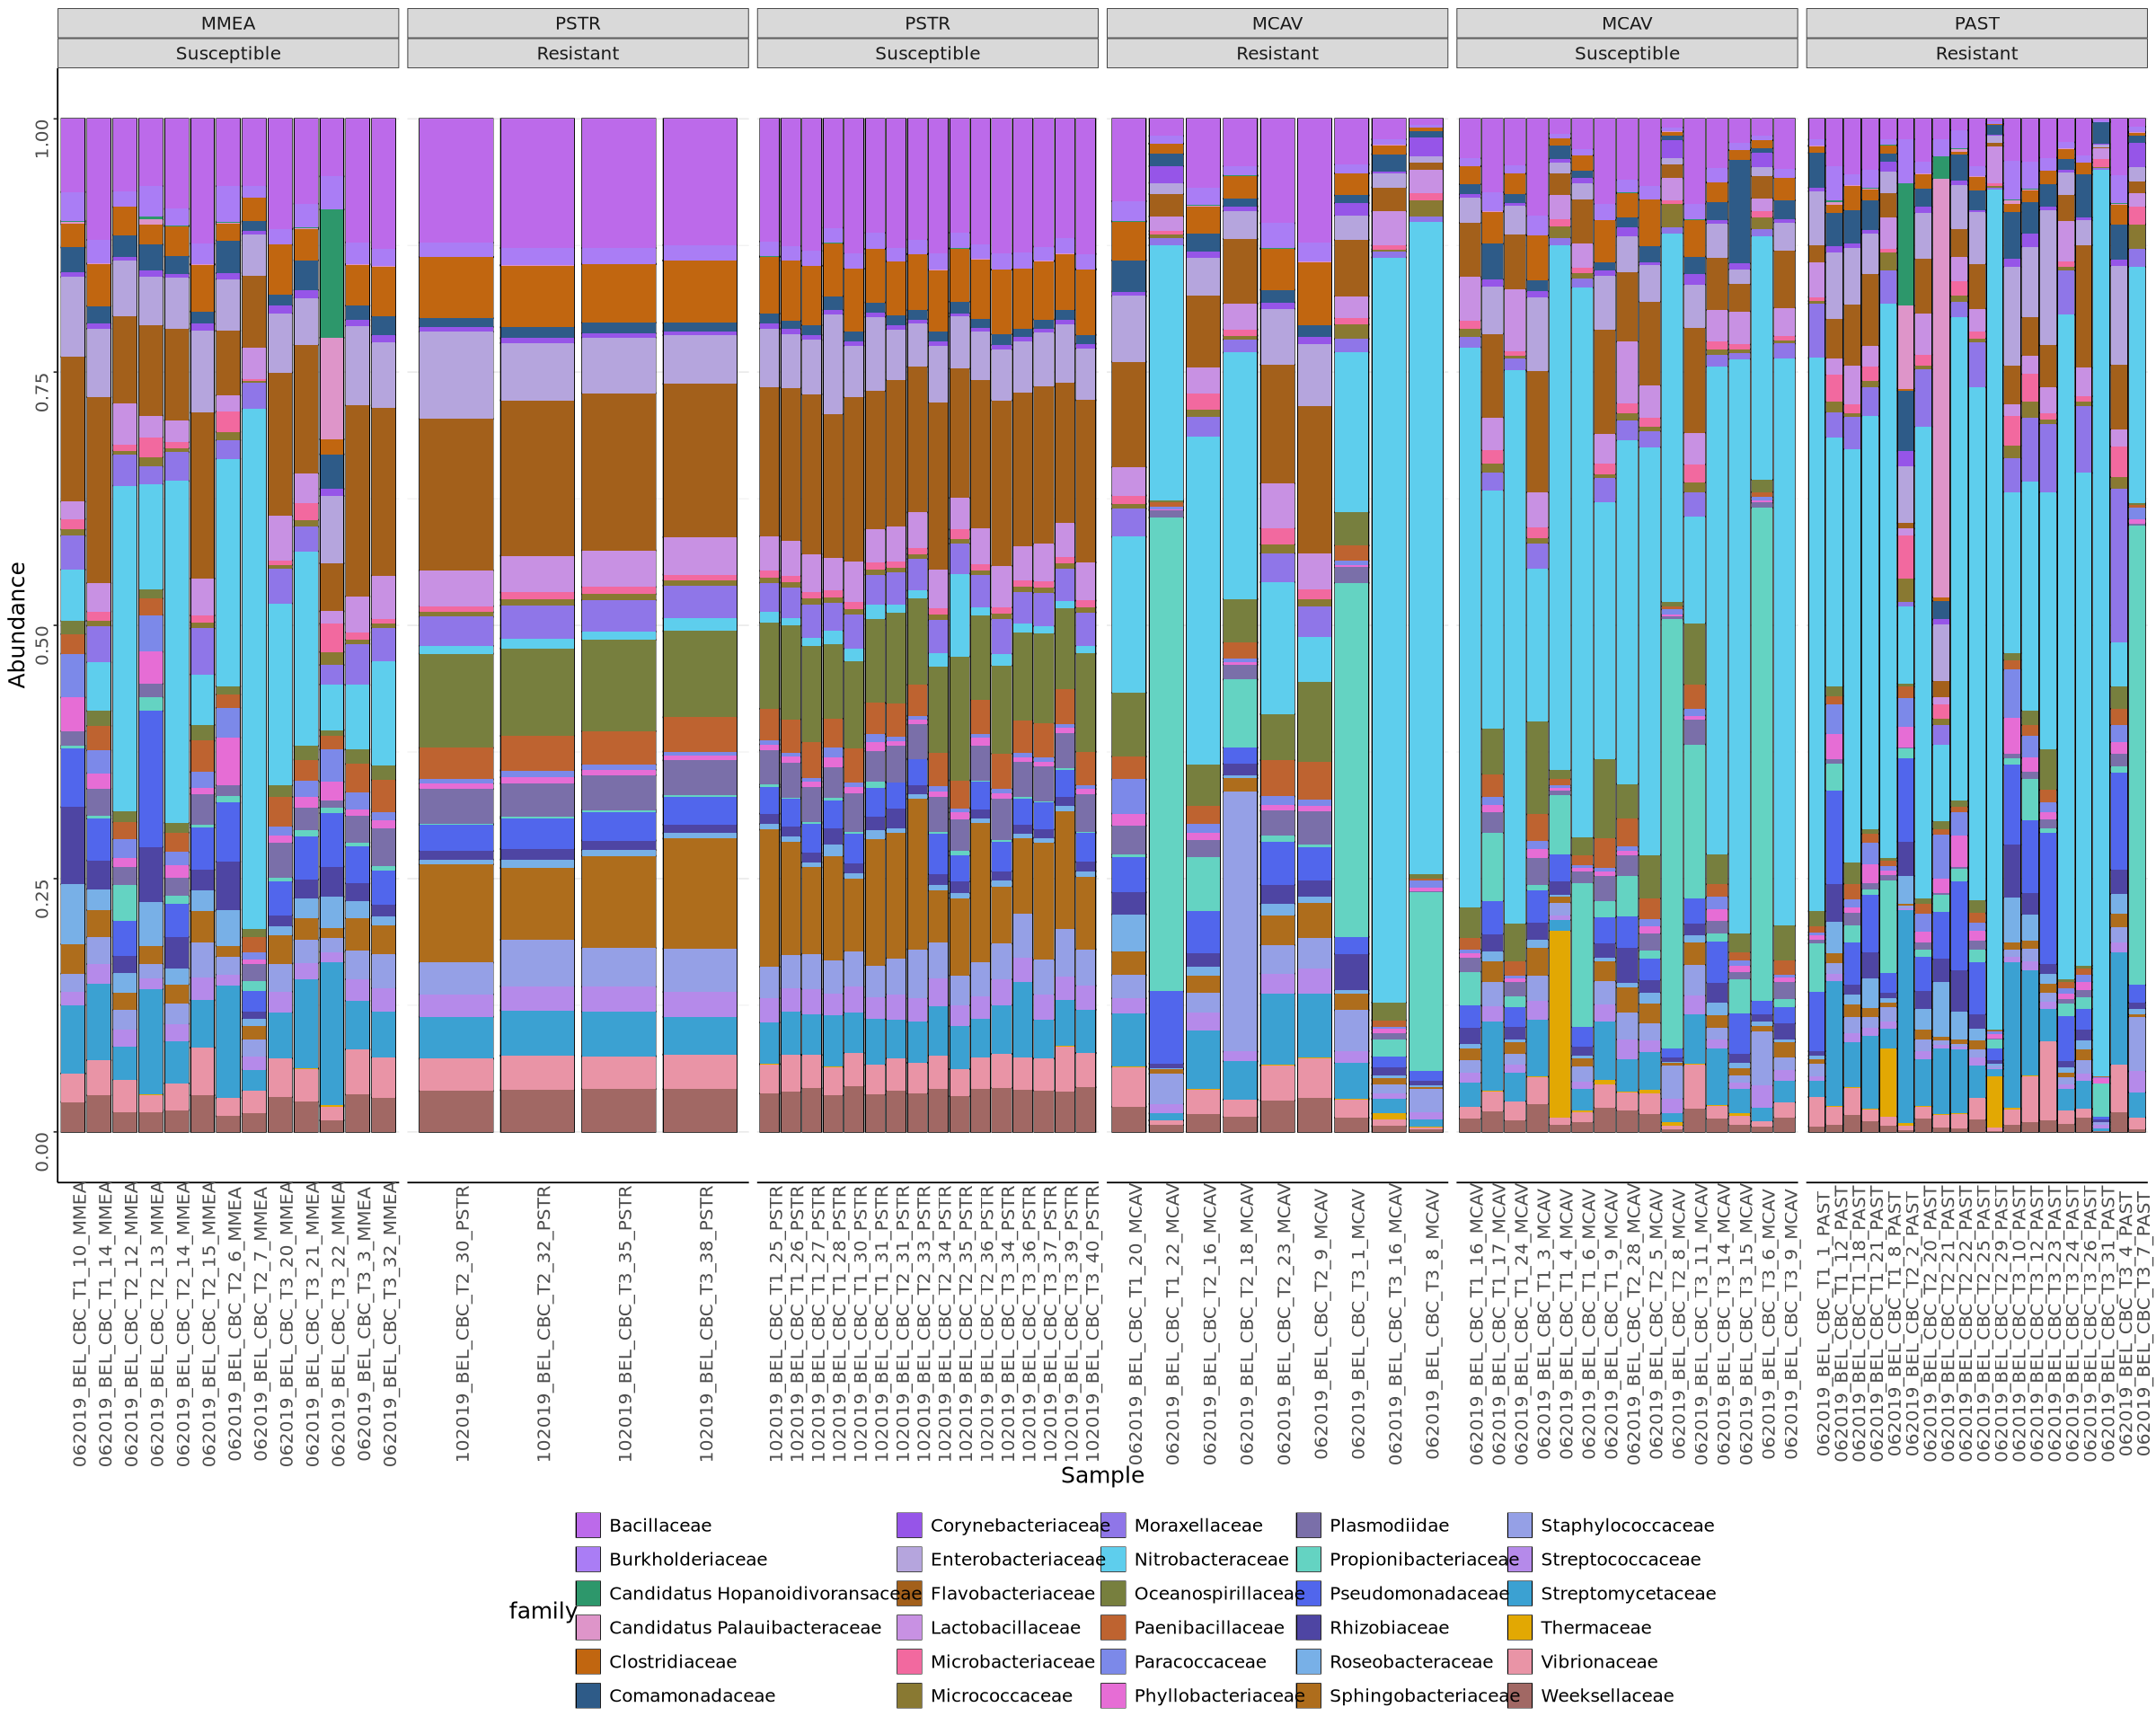

In [126]:
plot_bar(sctld_30_2019_norm,x = "Sample",fill='family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 30 fam 2019 only 

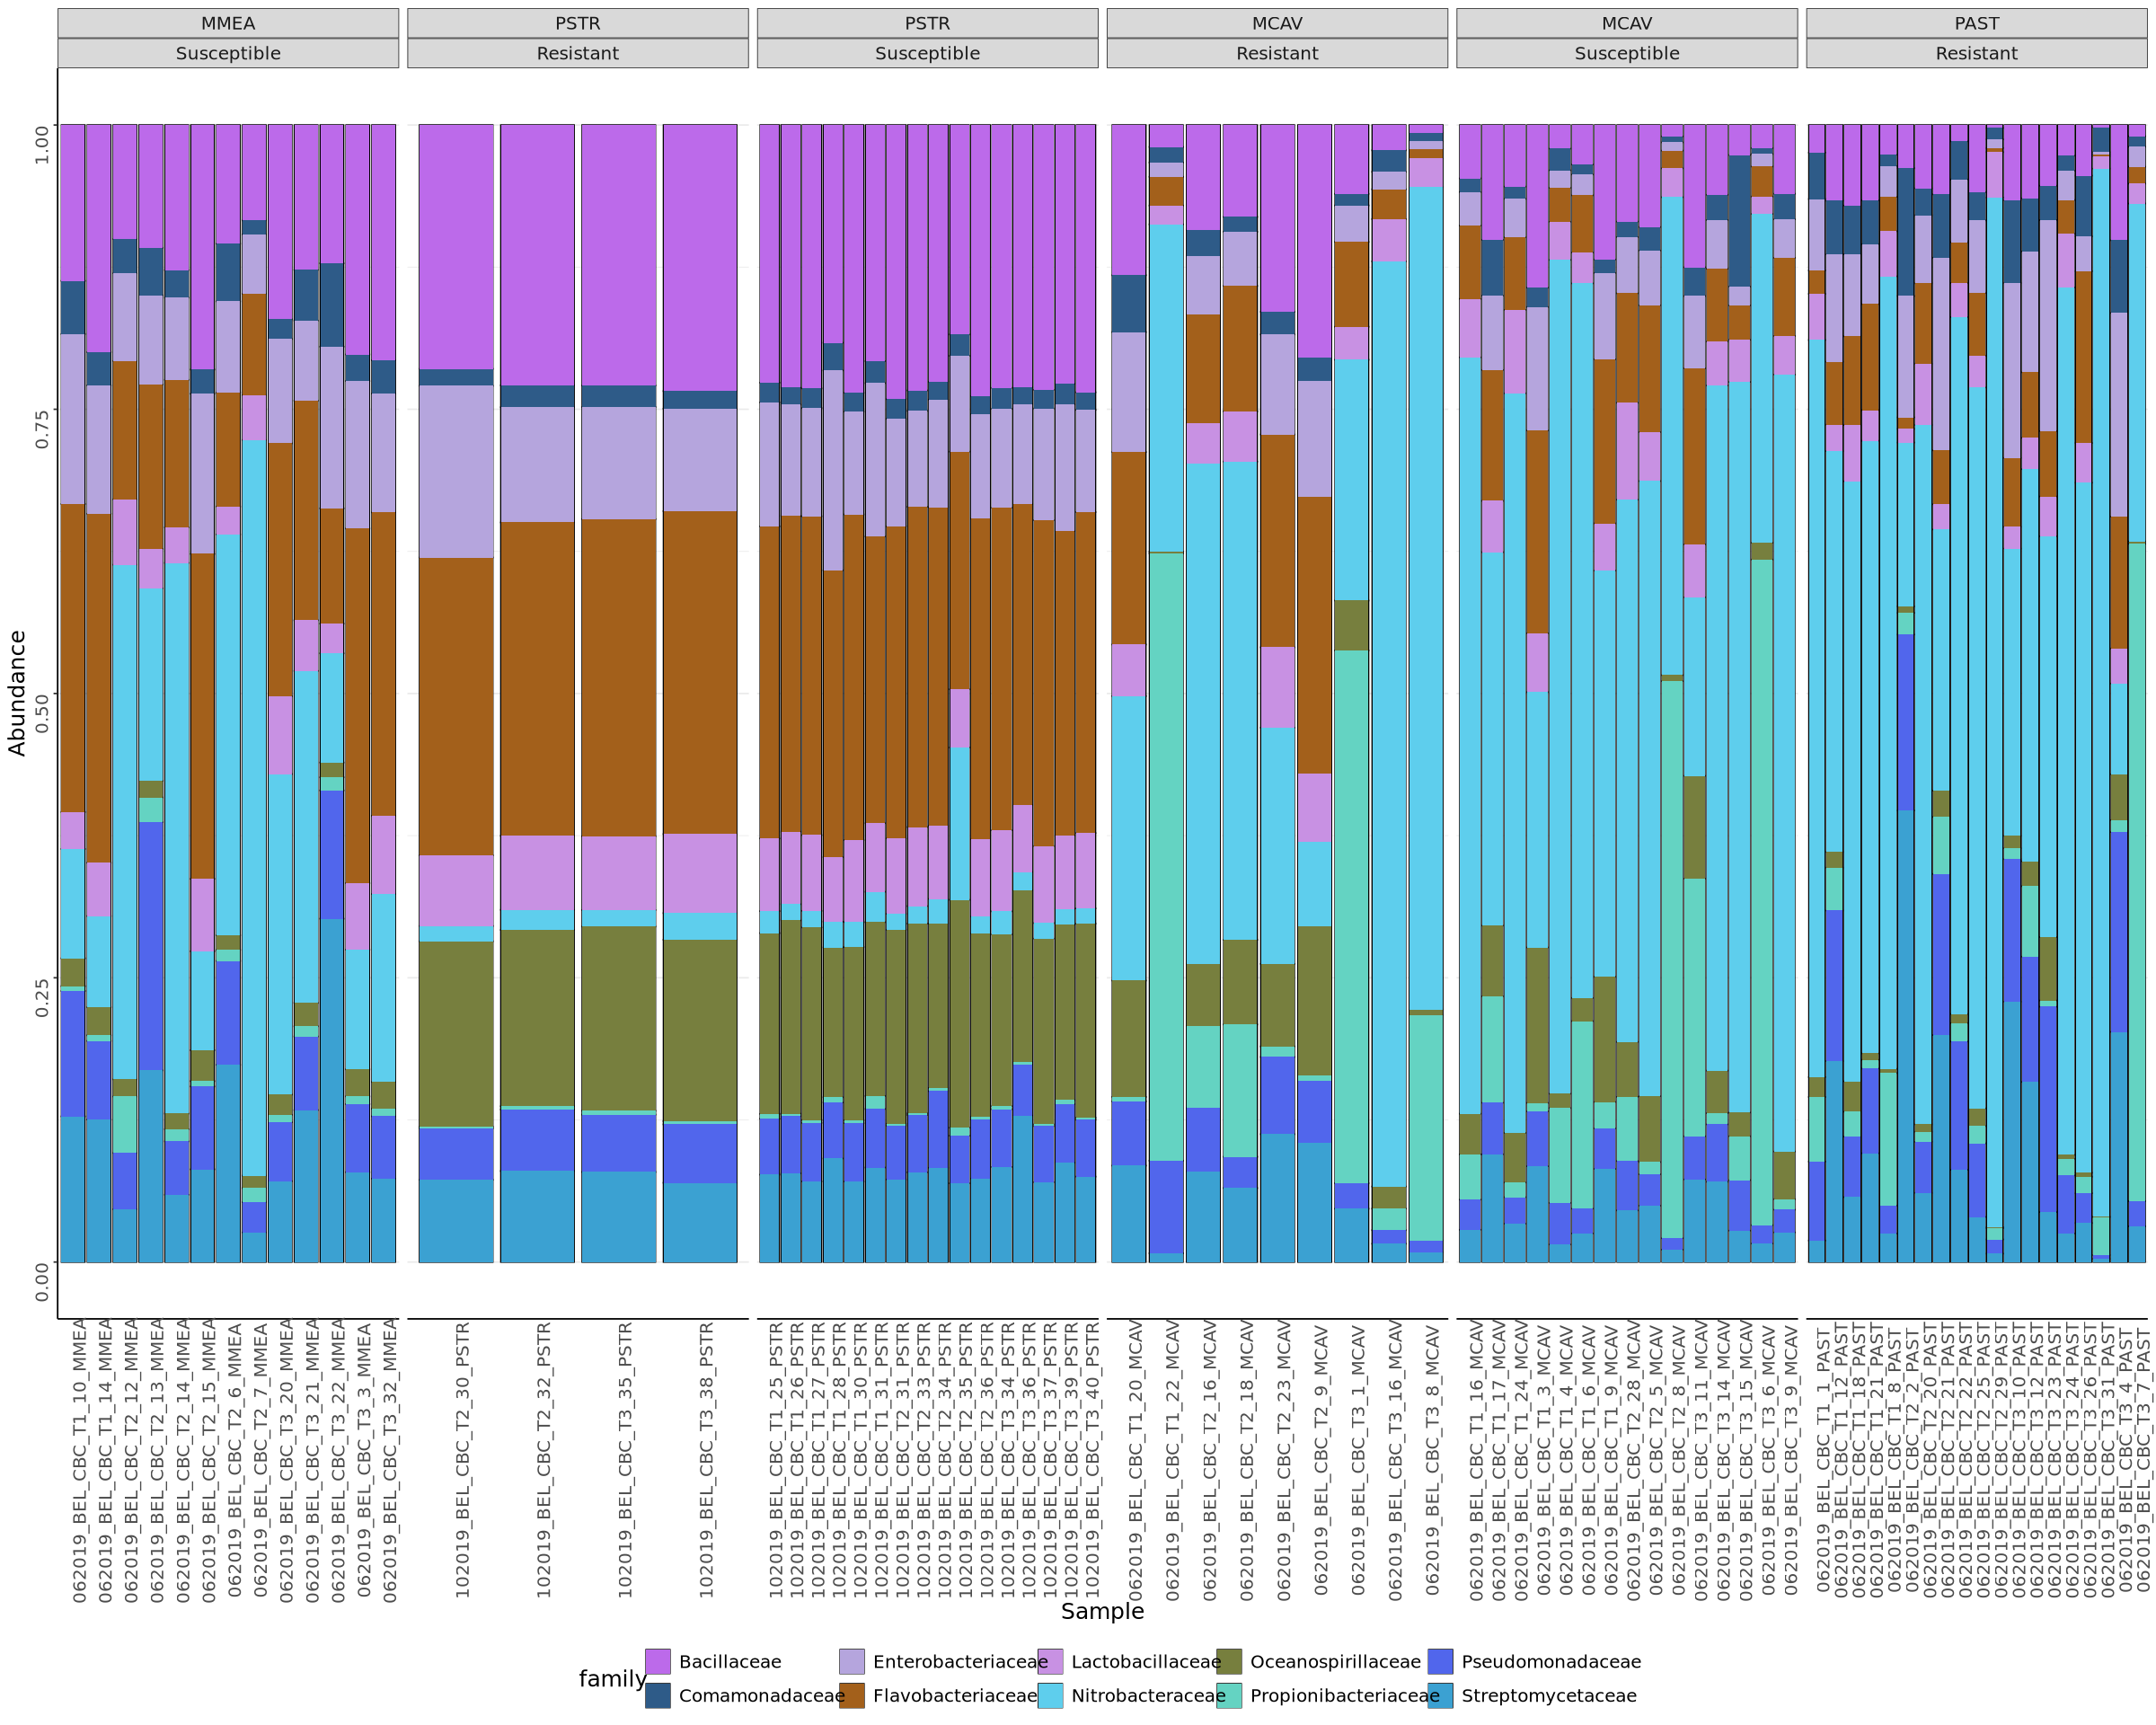

In [128]:
plot_bar(sctld_10_2019_norm,x = "Sample",fill='family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 10 fam only 

In [84]:
# plot each spp individually...

#### MCAV --------------------------------------------------------------------------------

In [129]:
library(ggh4x)

In [130]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [131]:
# looking just at mcav, remove disease margin

subset_mcav<- subset_samples(sctld_raw, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))

# top 100 family
mcav_100 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:100]), subset_mcav)
mcav_100_norm <- transform_sample_counts(mcav_100, function(x) x / sum(x))

# top 50 family
mcav_50 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:50]), subset_mcav)
mcav_50_norm <- transform_sample_counts(mcav_50, function(x) x / sum(x))

# top 30 family
mcav_30 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:30]), subset_mcav)
mcav_30_norm <- transform_sample_counts(mcav_30, function(x) x / sum(x))

# top 10 family
mcav_10 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:10]), subset_mcav)
mcav_10_norm <- transform_sample_counts(mcav_10, function(x) x / sum(x))

In [132]:
df_meta <- data.frame(sample_data(subset_mcav))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_mcav) <- sample_data(df_meta)

In [133]:
library(patchwork)

In [134]:
# reorder colonies
mcav_g_S<-subset_samples(subset_mcav, RS == "Susceptible")
df_meta<-data.frame(sample_data(mcav_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(mcav_g_S)$colony_id <-
  factor(sample_data(mcav_g_S)$colony_id, levels = col_order)

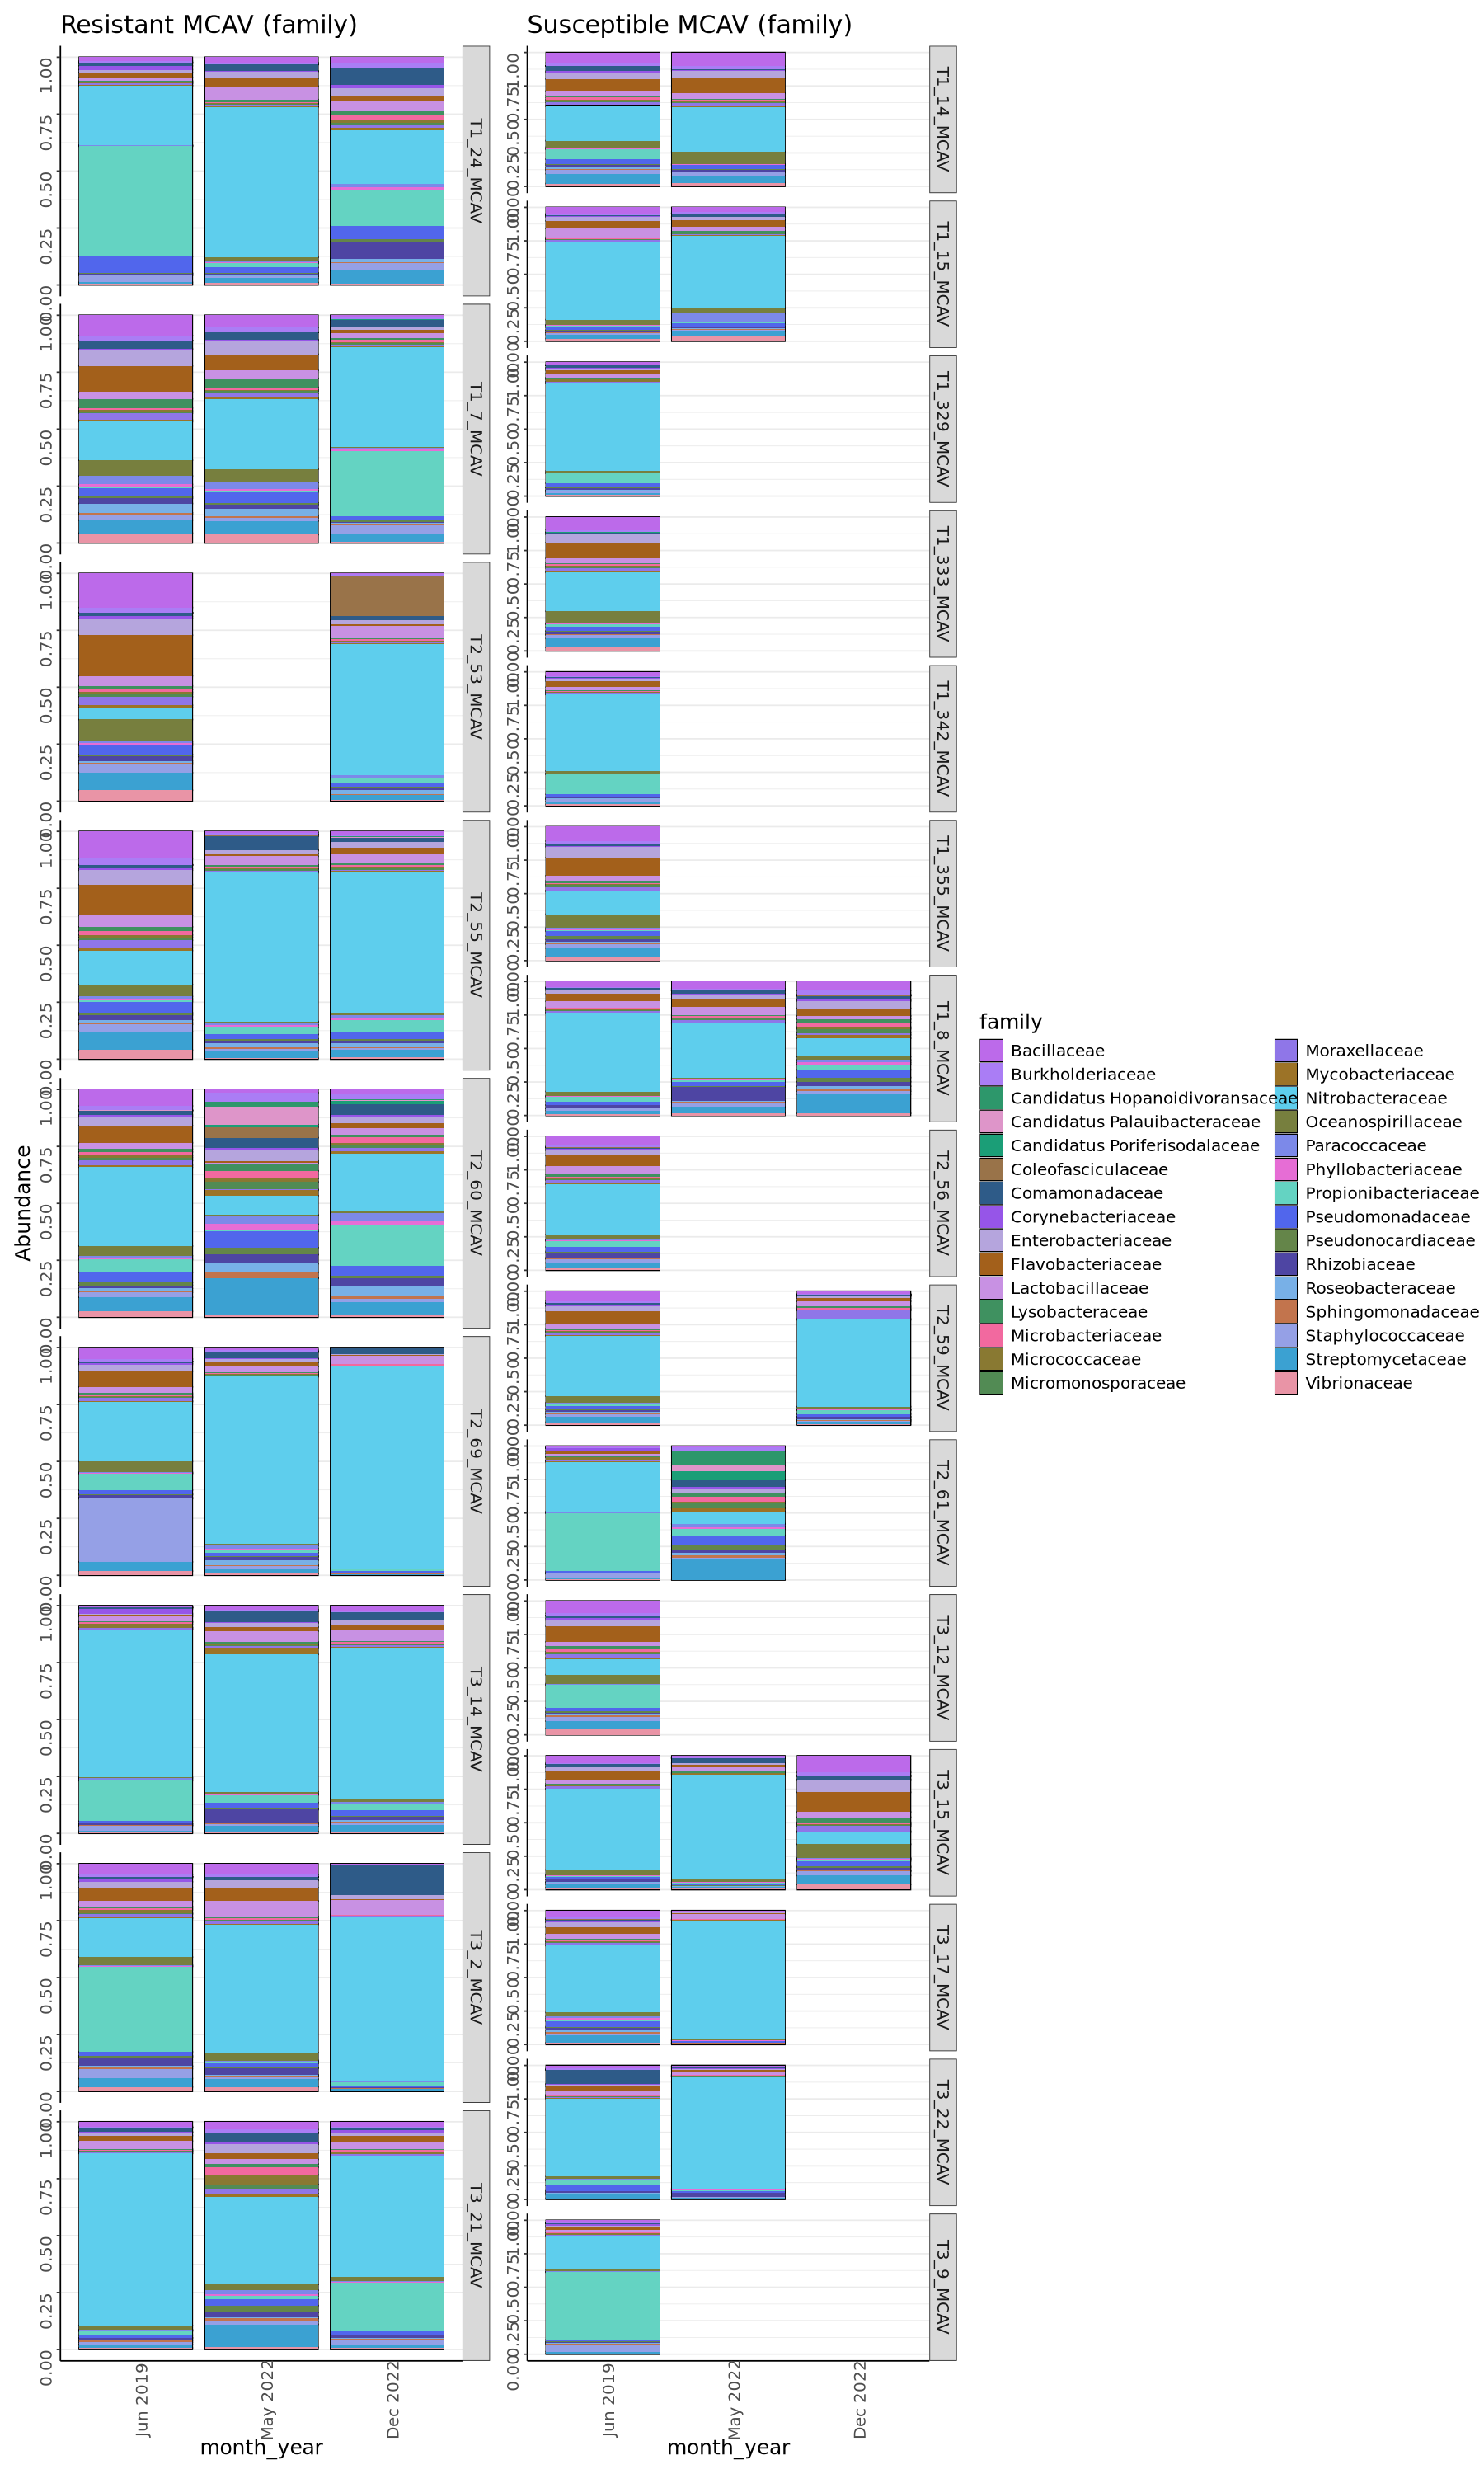

In [135]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(mcav_30_norm, RS == "Resistant"),x = "month_year", fill = "family")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant MCAV (family)")

p_S <- plot_bar(subset_samples(mcav_30_norm, RS == "Susceptible"),x = "month_year", fill = "family") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible MCAV (family)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "MCAV colonies") &
  theme(legend.position = "right")

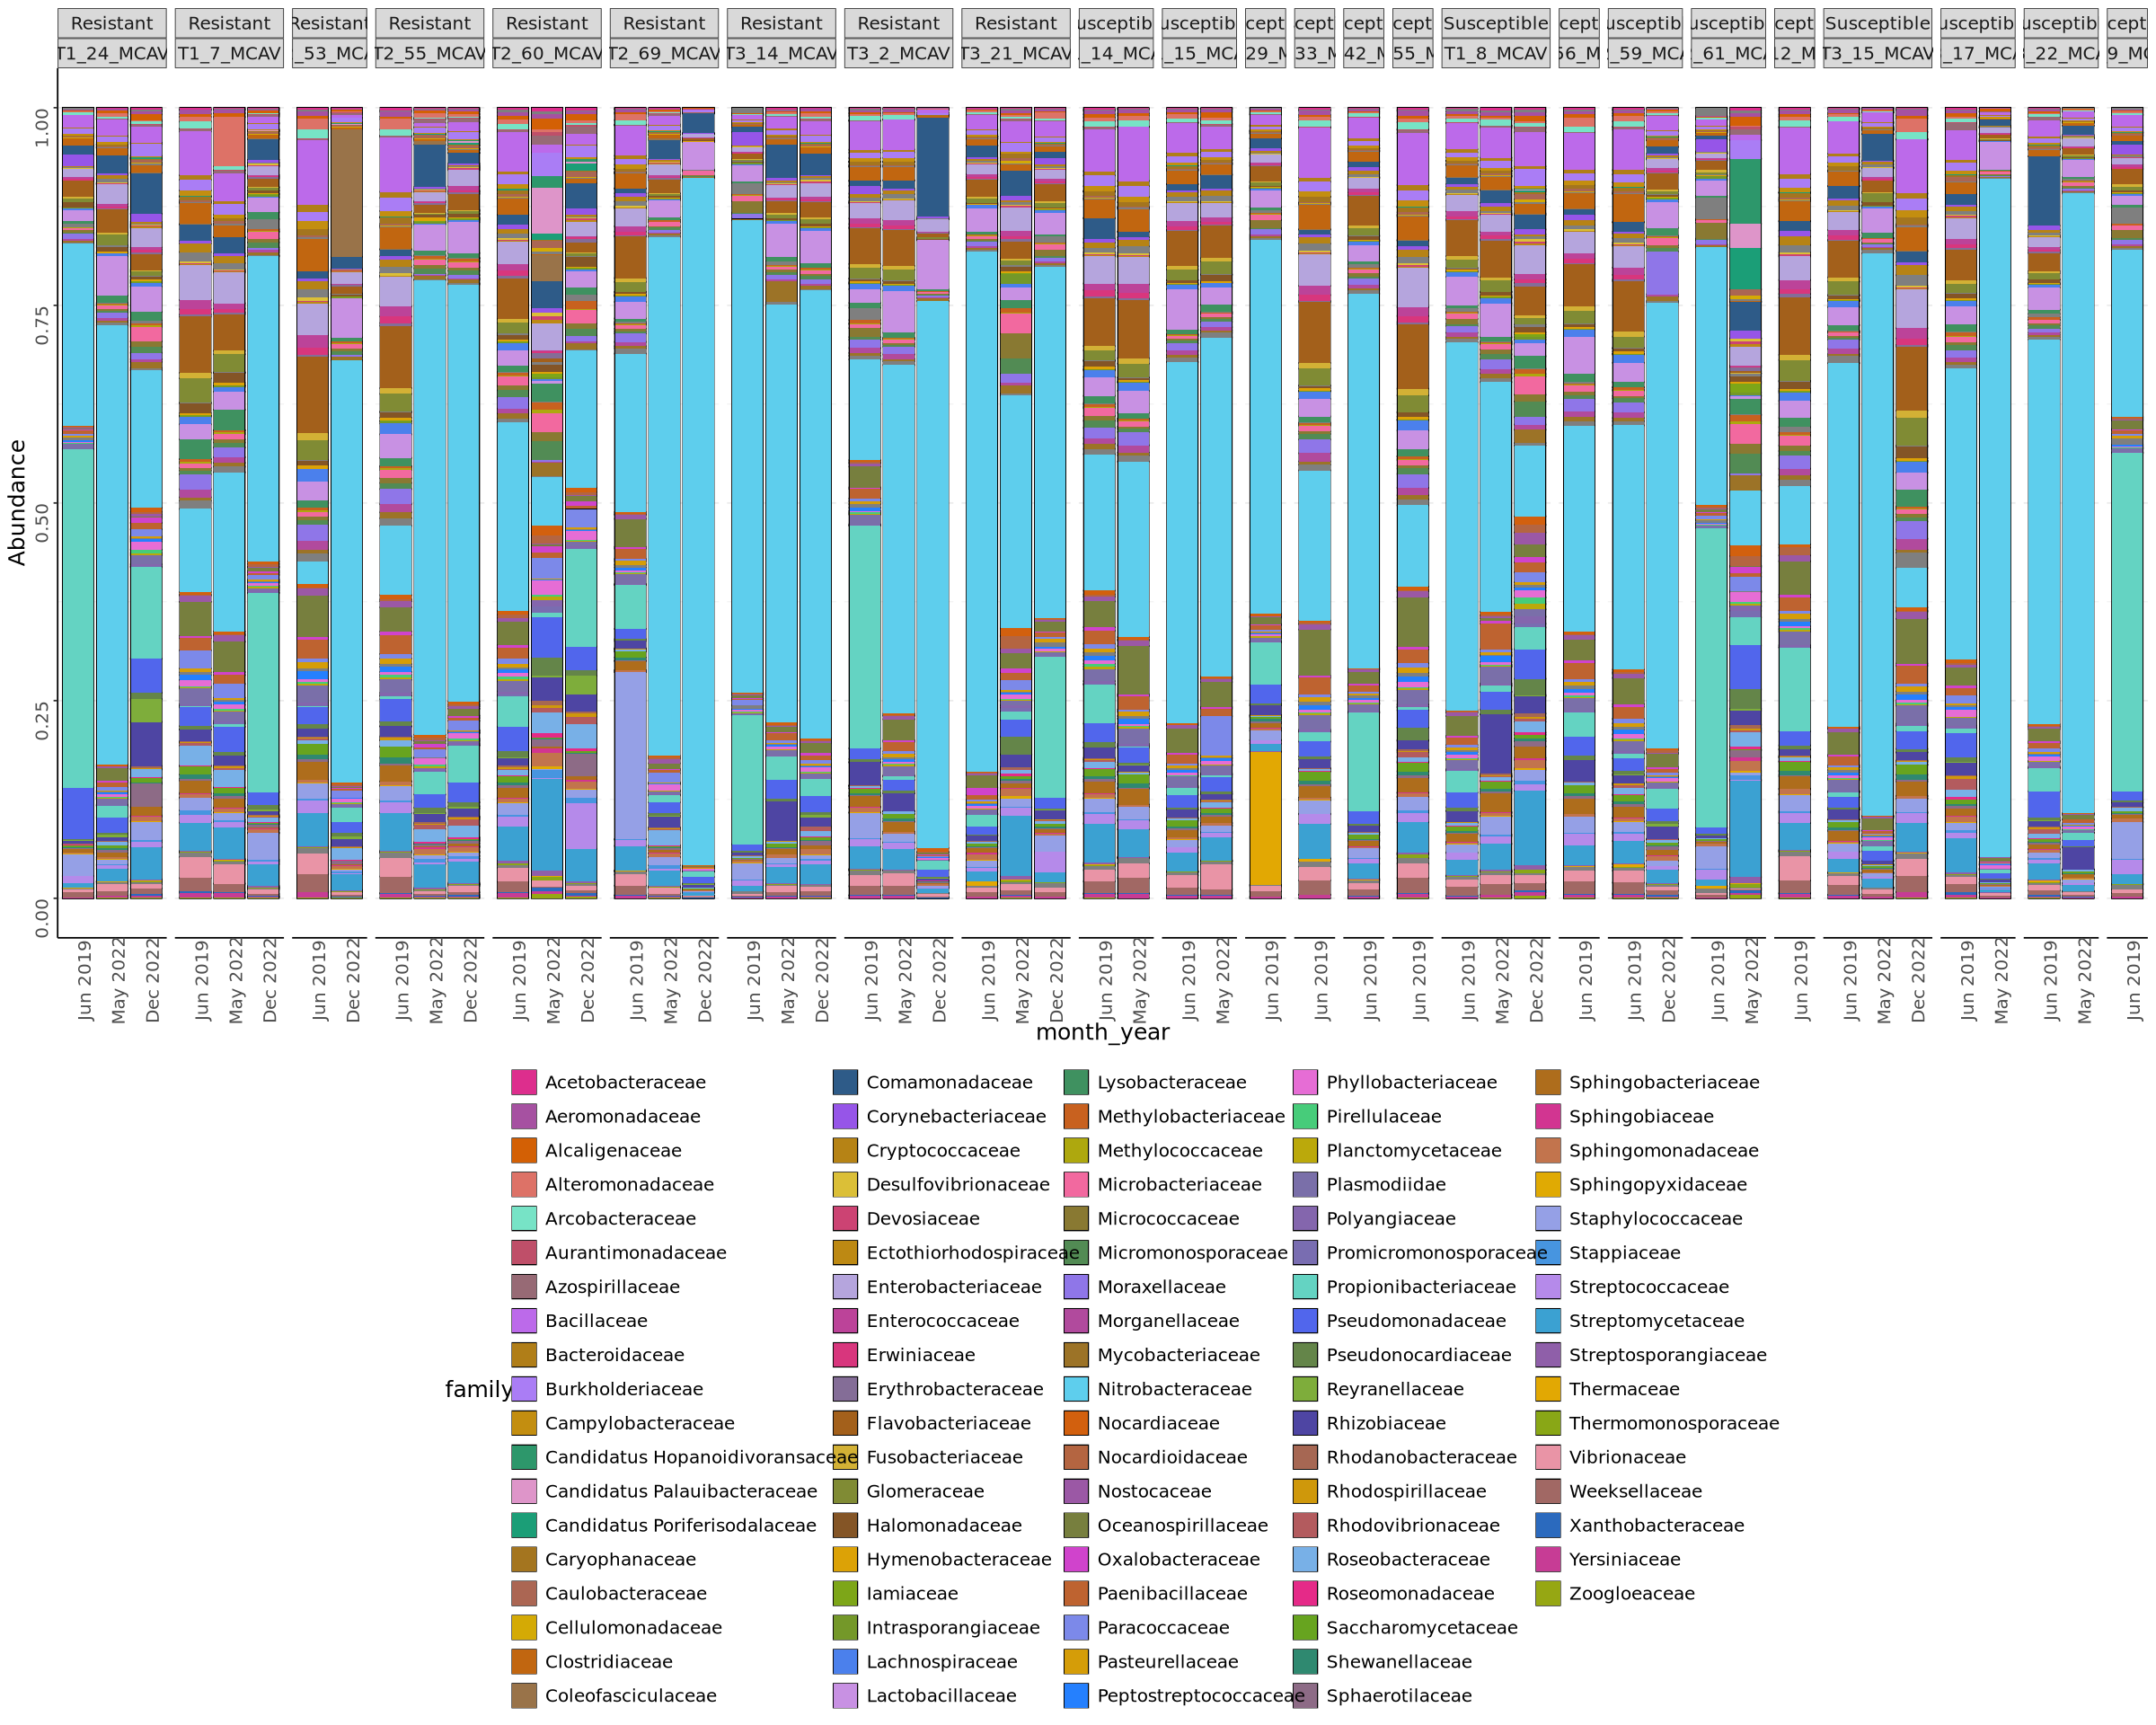

In [136]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (family)

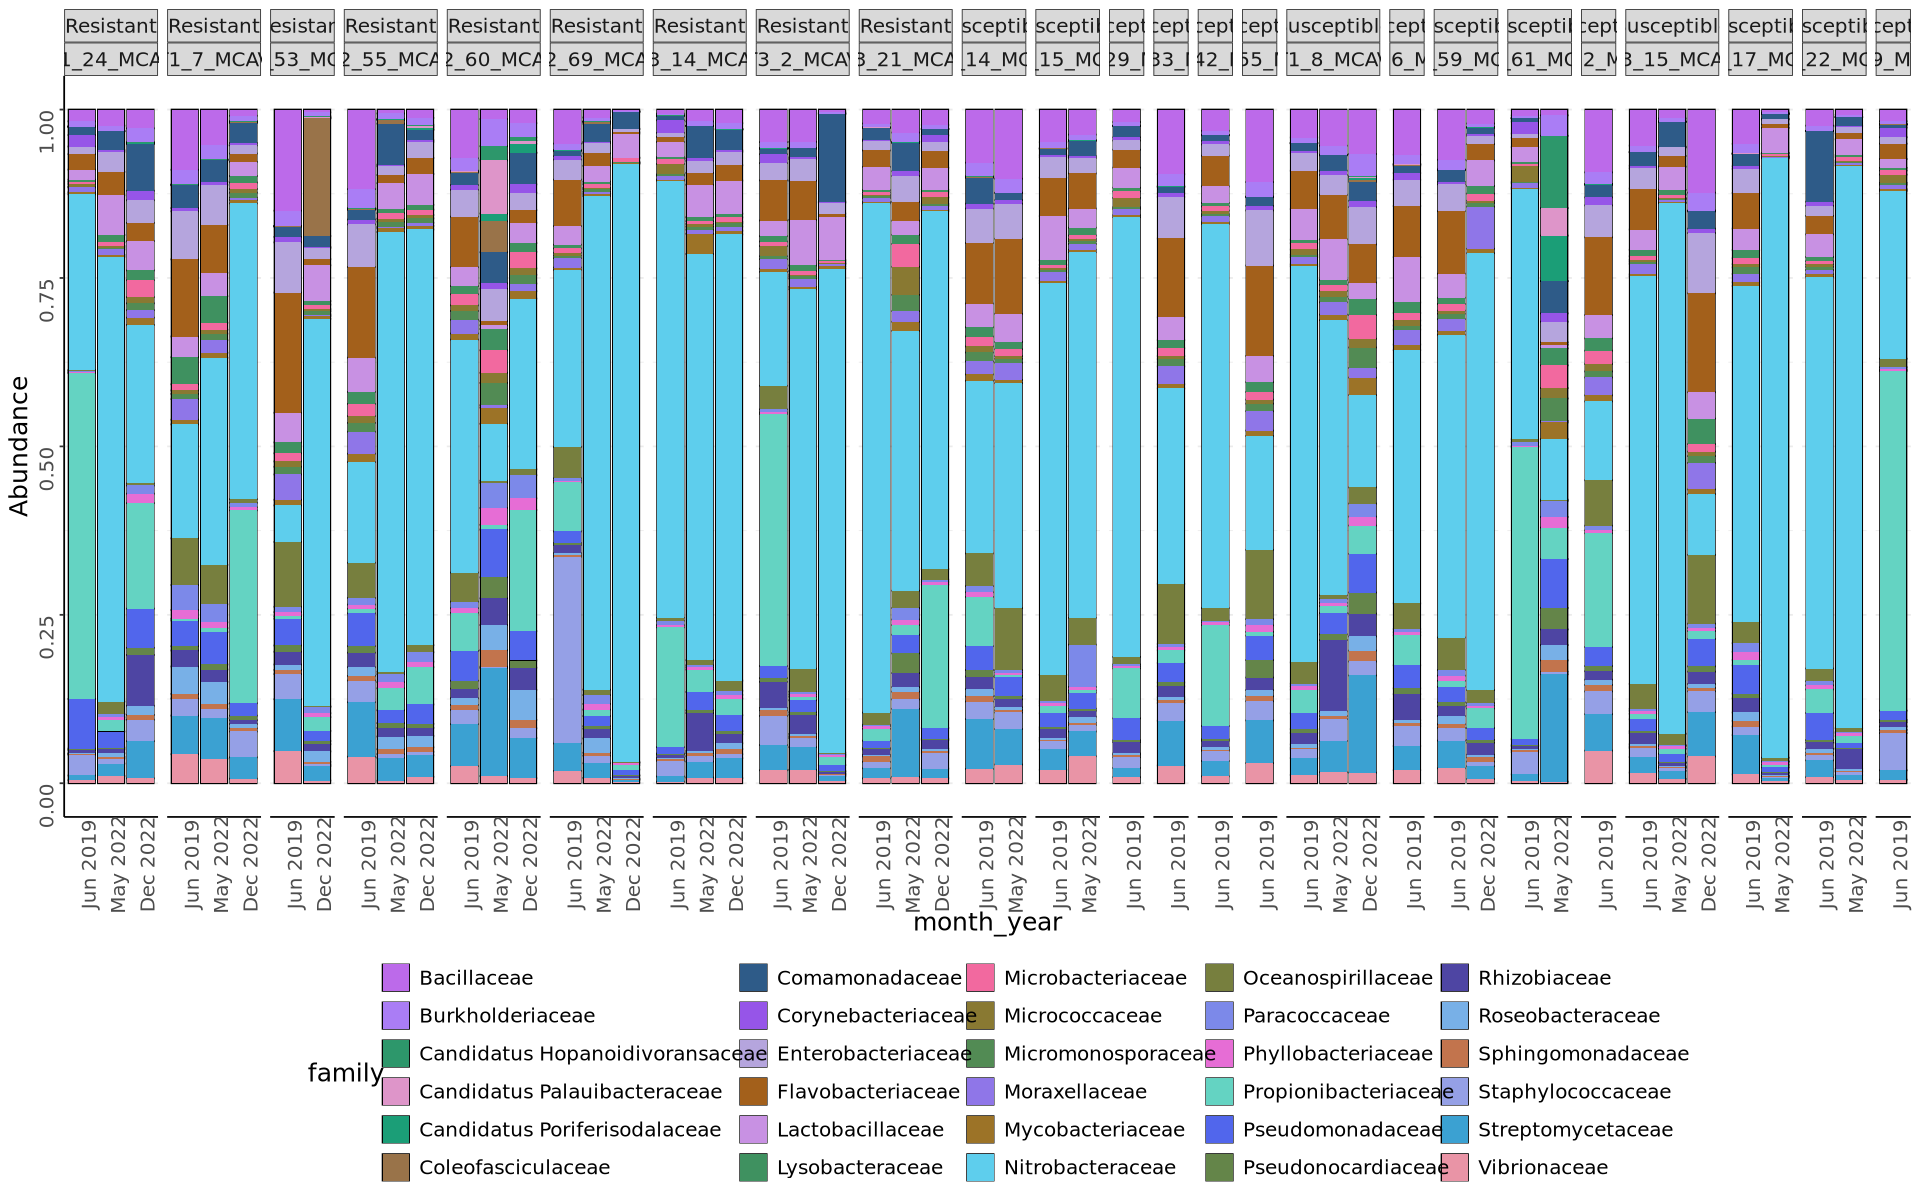

In [137]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_30_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 family - R vs S. individuals over time 

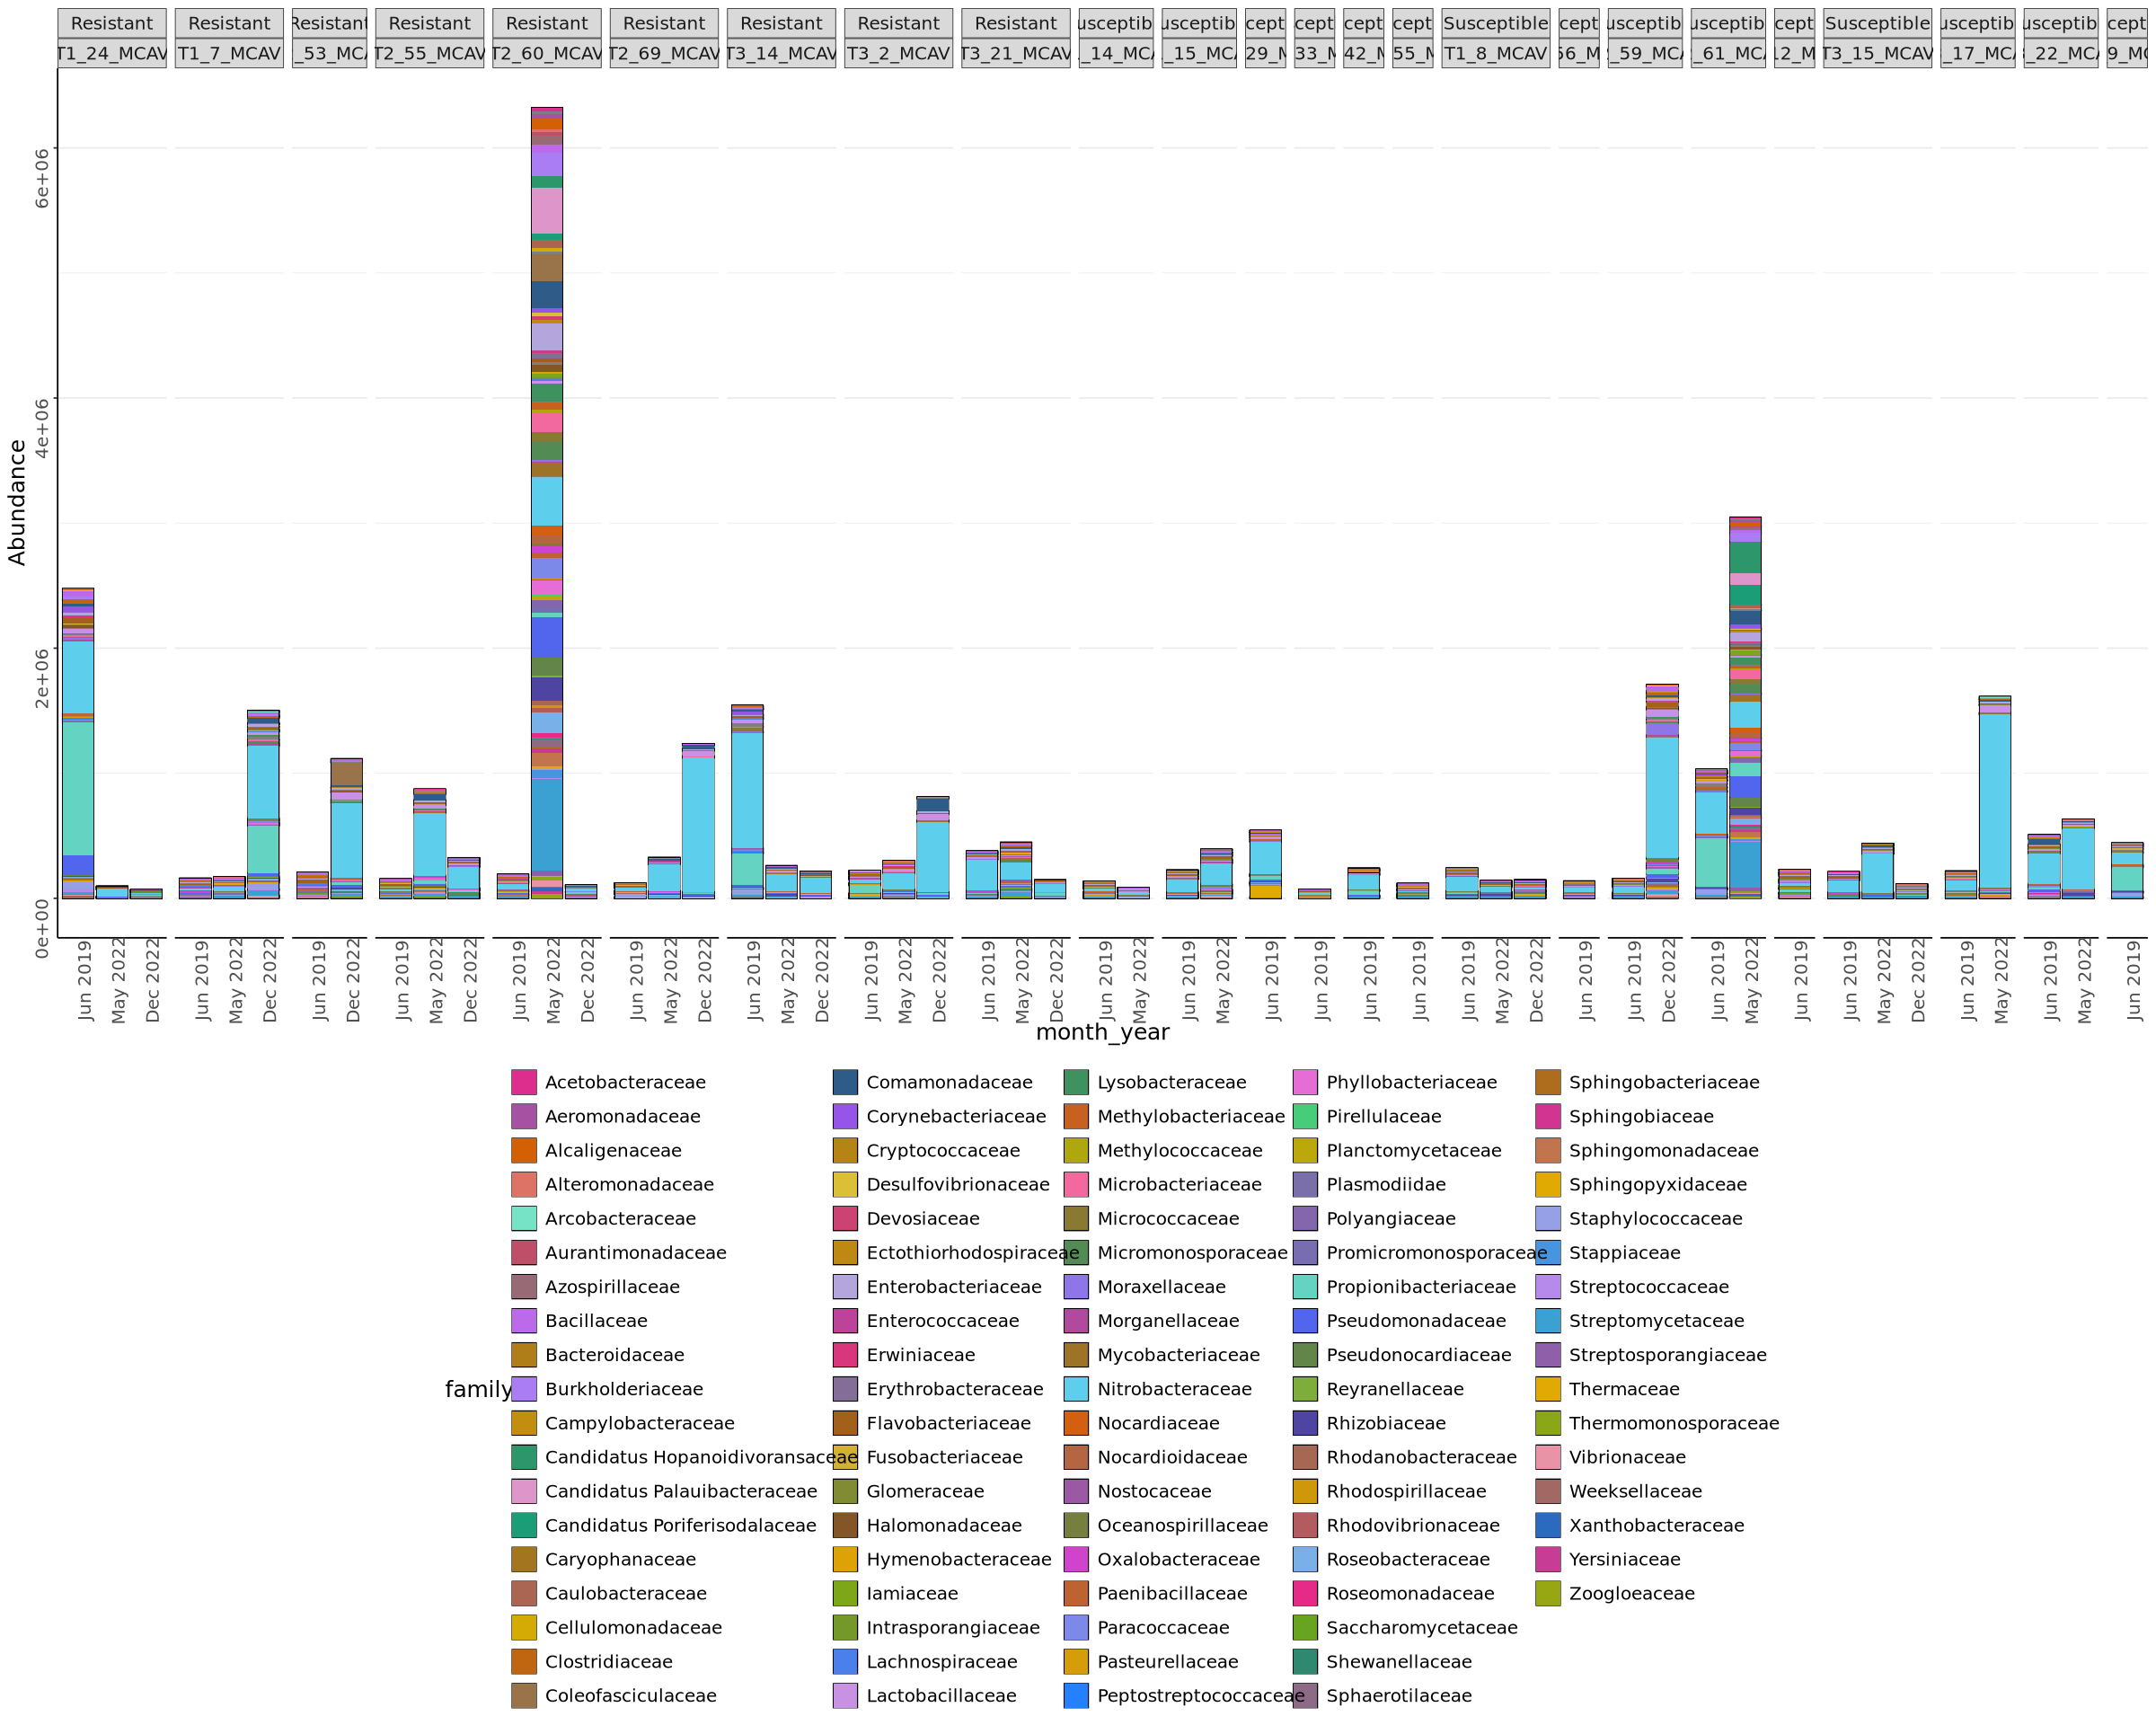

In [138]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 100 family

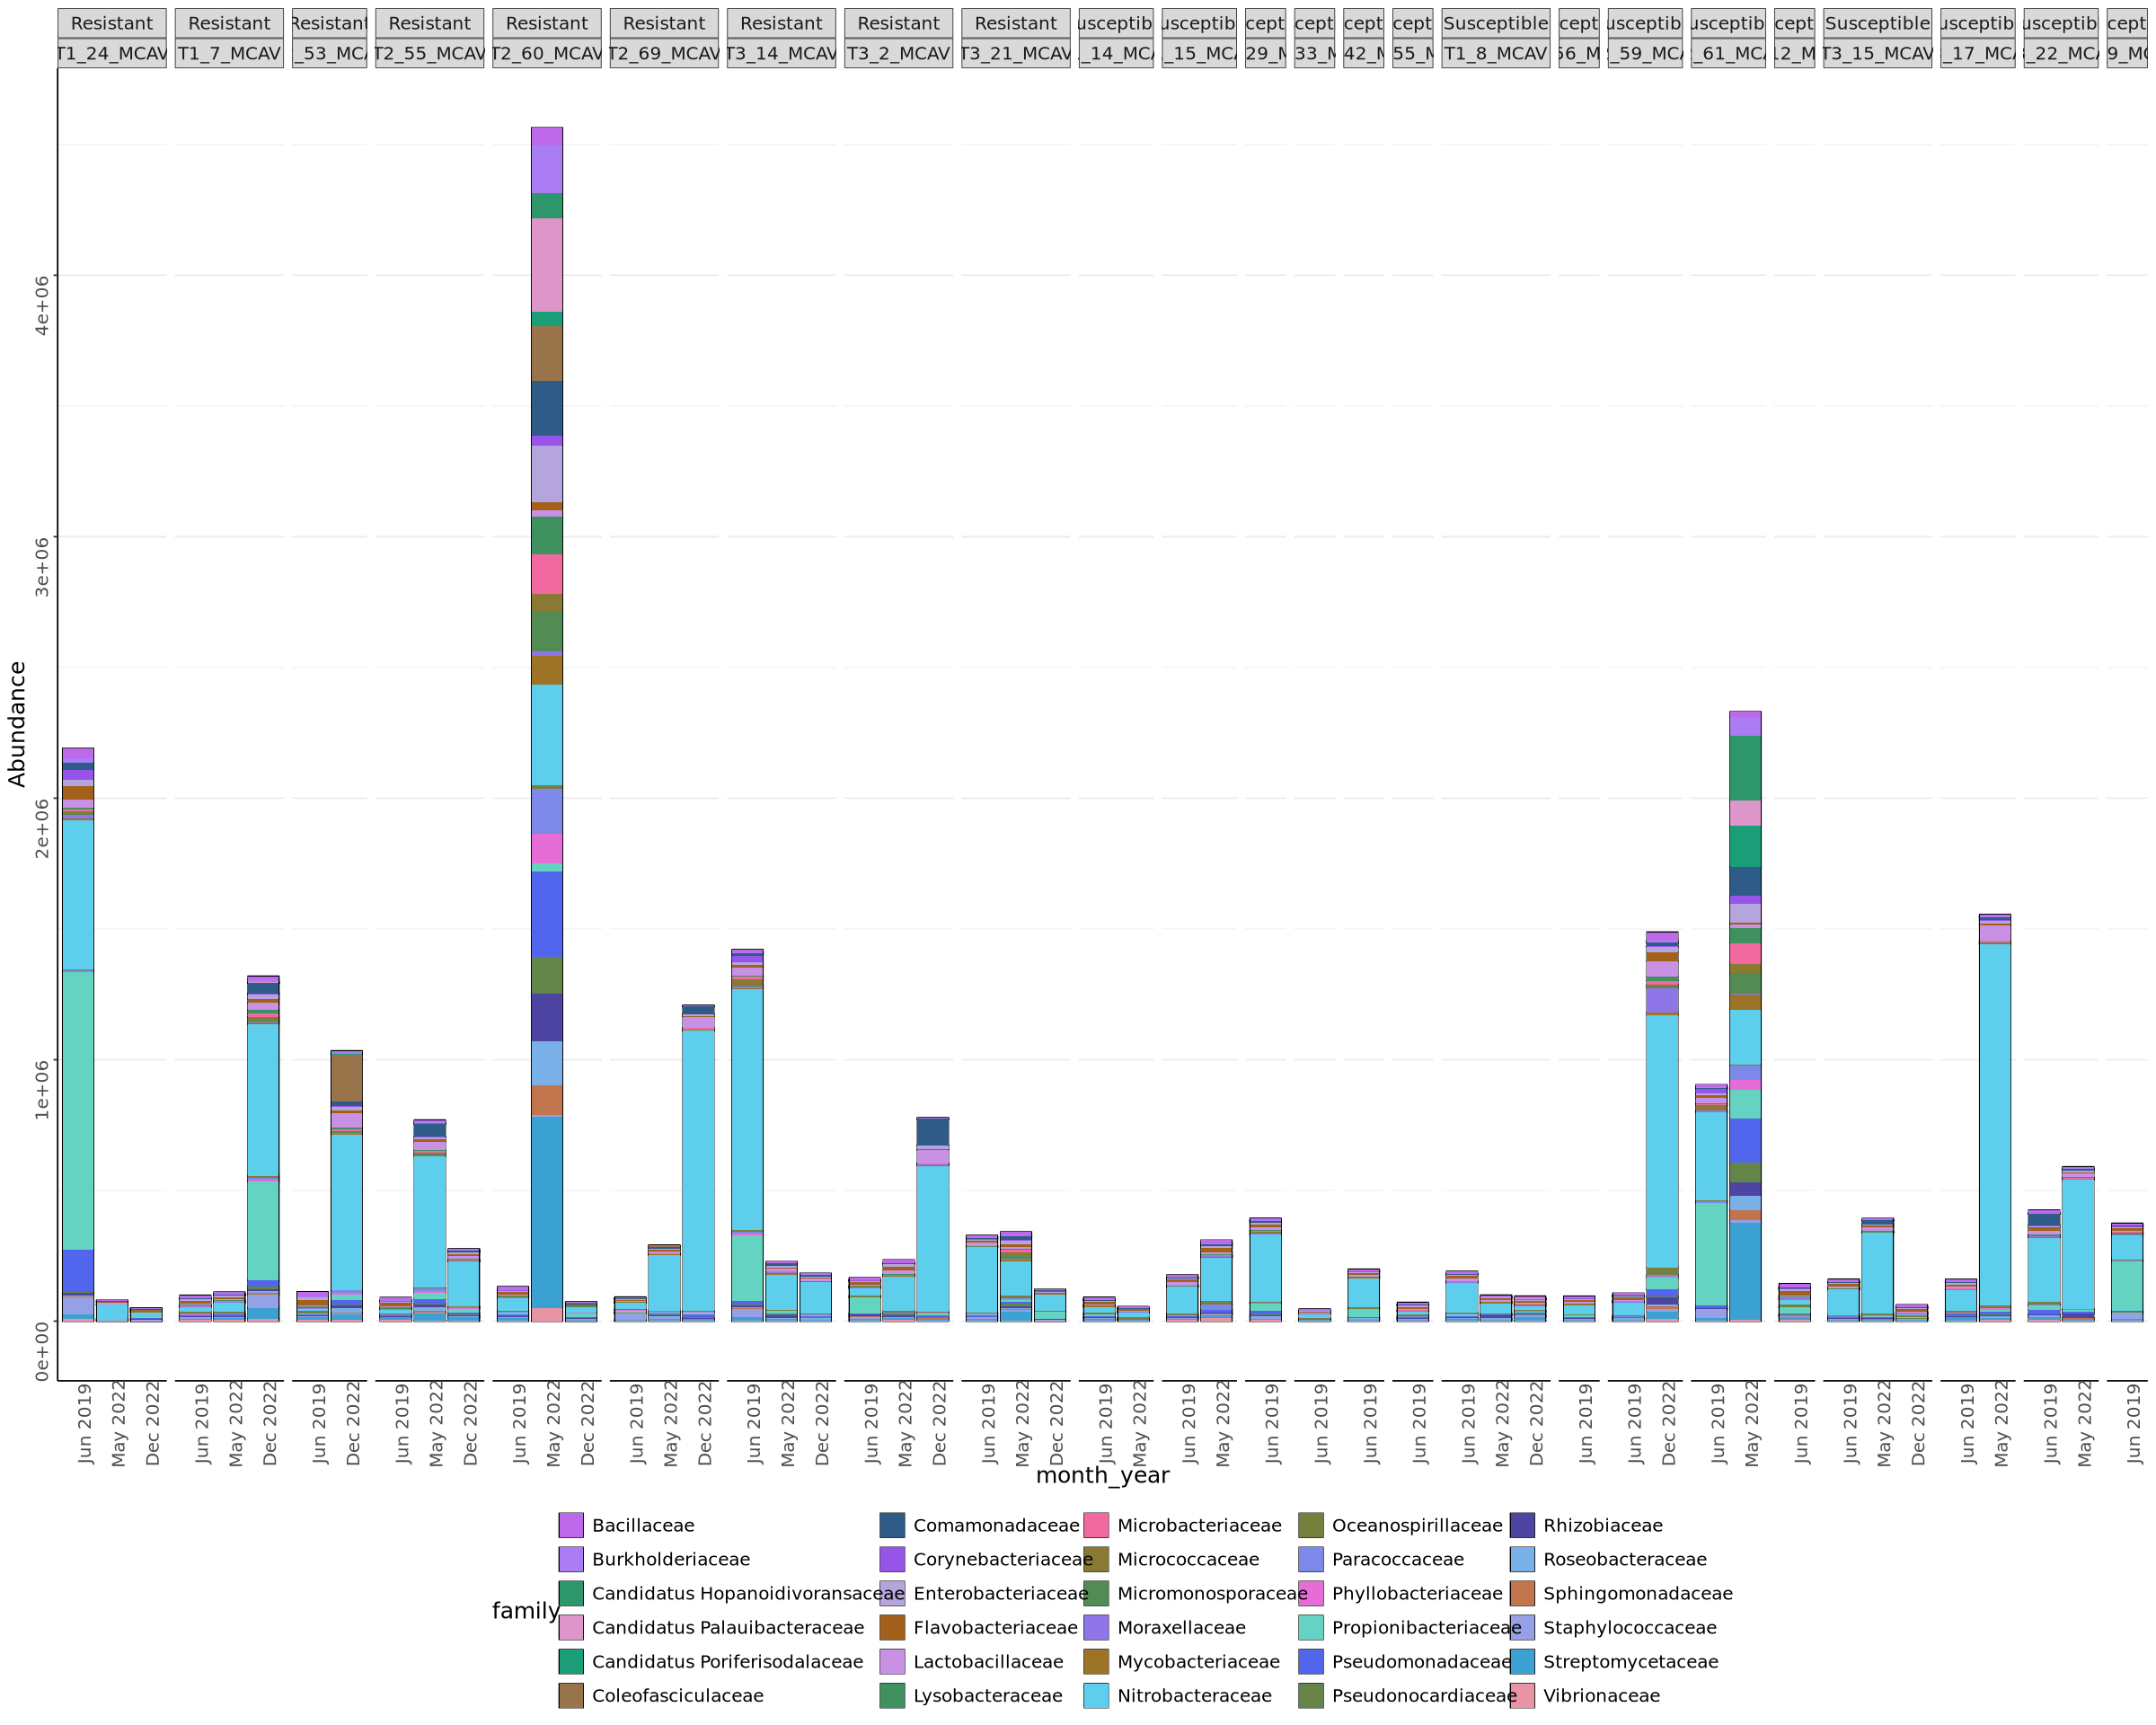

In [139]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_30,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 30 family

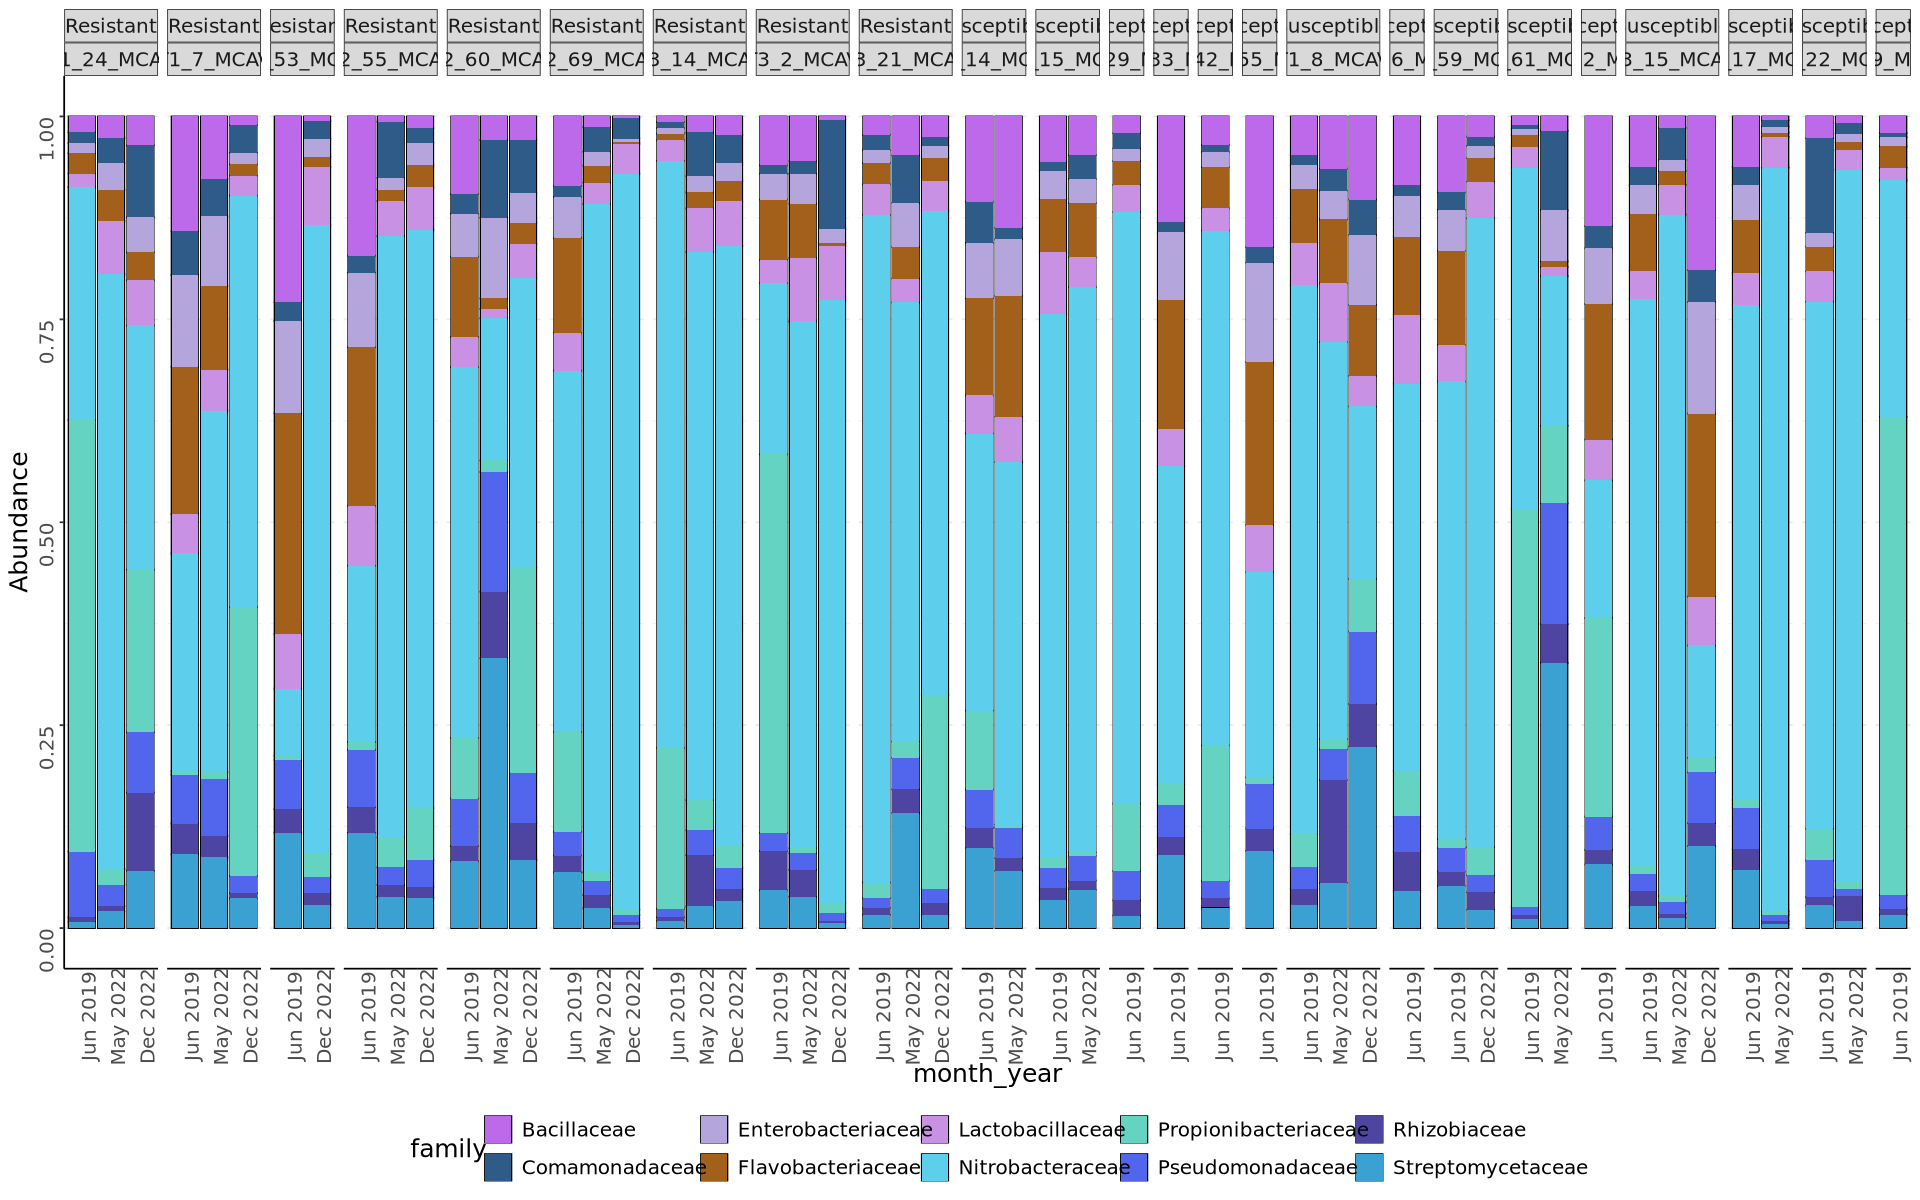

In [140]:
# top 10 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_10_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (family)

In [141]:
# repeat other spp 

#### PSTR --------------------------------------------------------------------------------

In [142]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [143]:
# looking just at PSTR, remove disease margin

subset_PSTR<- subset_samples(sctld_raw, (Species == "PSTR" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PSTR<- subset_samples(subset_PSTR, (!(Date_InitialTag %in% dec_tags)))

# top 100 family
PSTR_100 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:100]), subset_PSTR)
PSTR_100_norm <- transform_sample_counts(PSTR_100, function(x) x / sum(x))
# top 30 family
PSTR_30 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:30]), subset_PSTR)
PSTR_30_norm <- transform_sample_counts(PSTR_30, function(x) x / sum(x))
# top 10 family
PSTR_10 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:10]), subset_PSTR)
PSTR_10_norm <- transform_sample_counts(PSTR_10, function(x) x / sum(x))

In [144]:
df_meta <- data.frame(sample_data(subset_PSTR))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PSTR) <- sample_data(df_meta)

In [145]:
# reorder colonies
PSTR_g_S<-subset_samples(subset_PSTR, RS == "Susceptible")
df_meta<-data.frame(sample_data(PSTR_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(PSTR_g_S)$colony_id <-
  factor(sample_data(PSTR_g_S)$colony_id, levels = col_order)

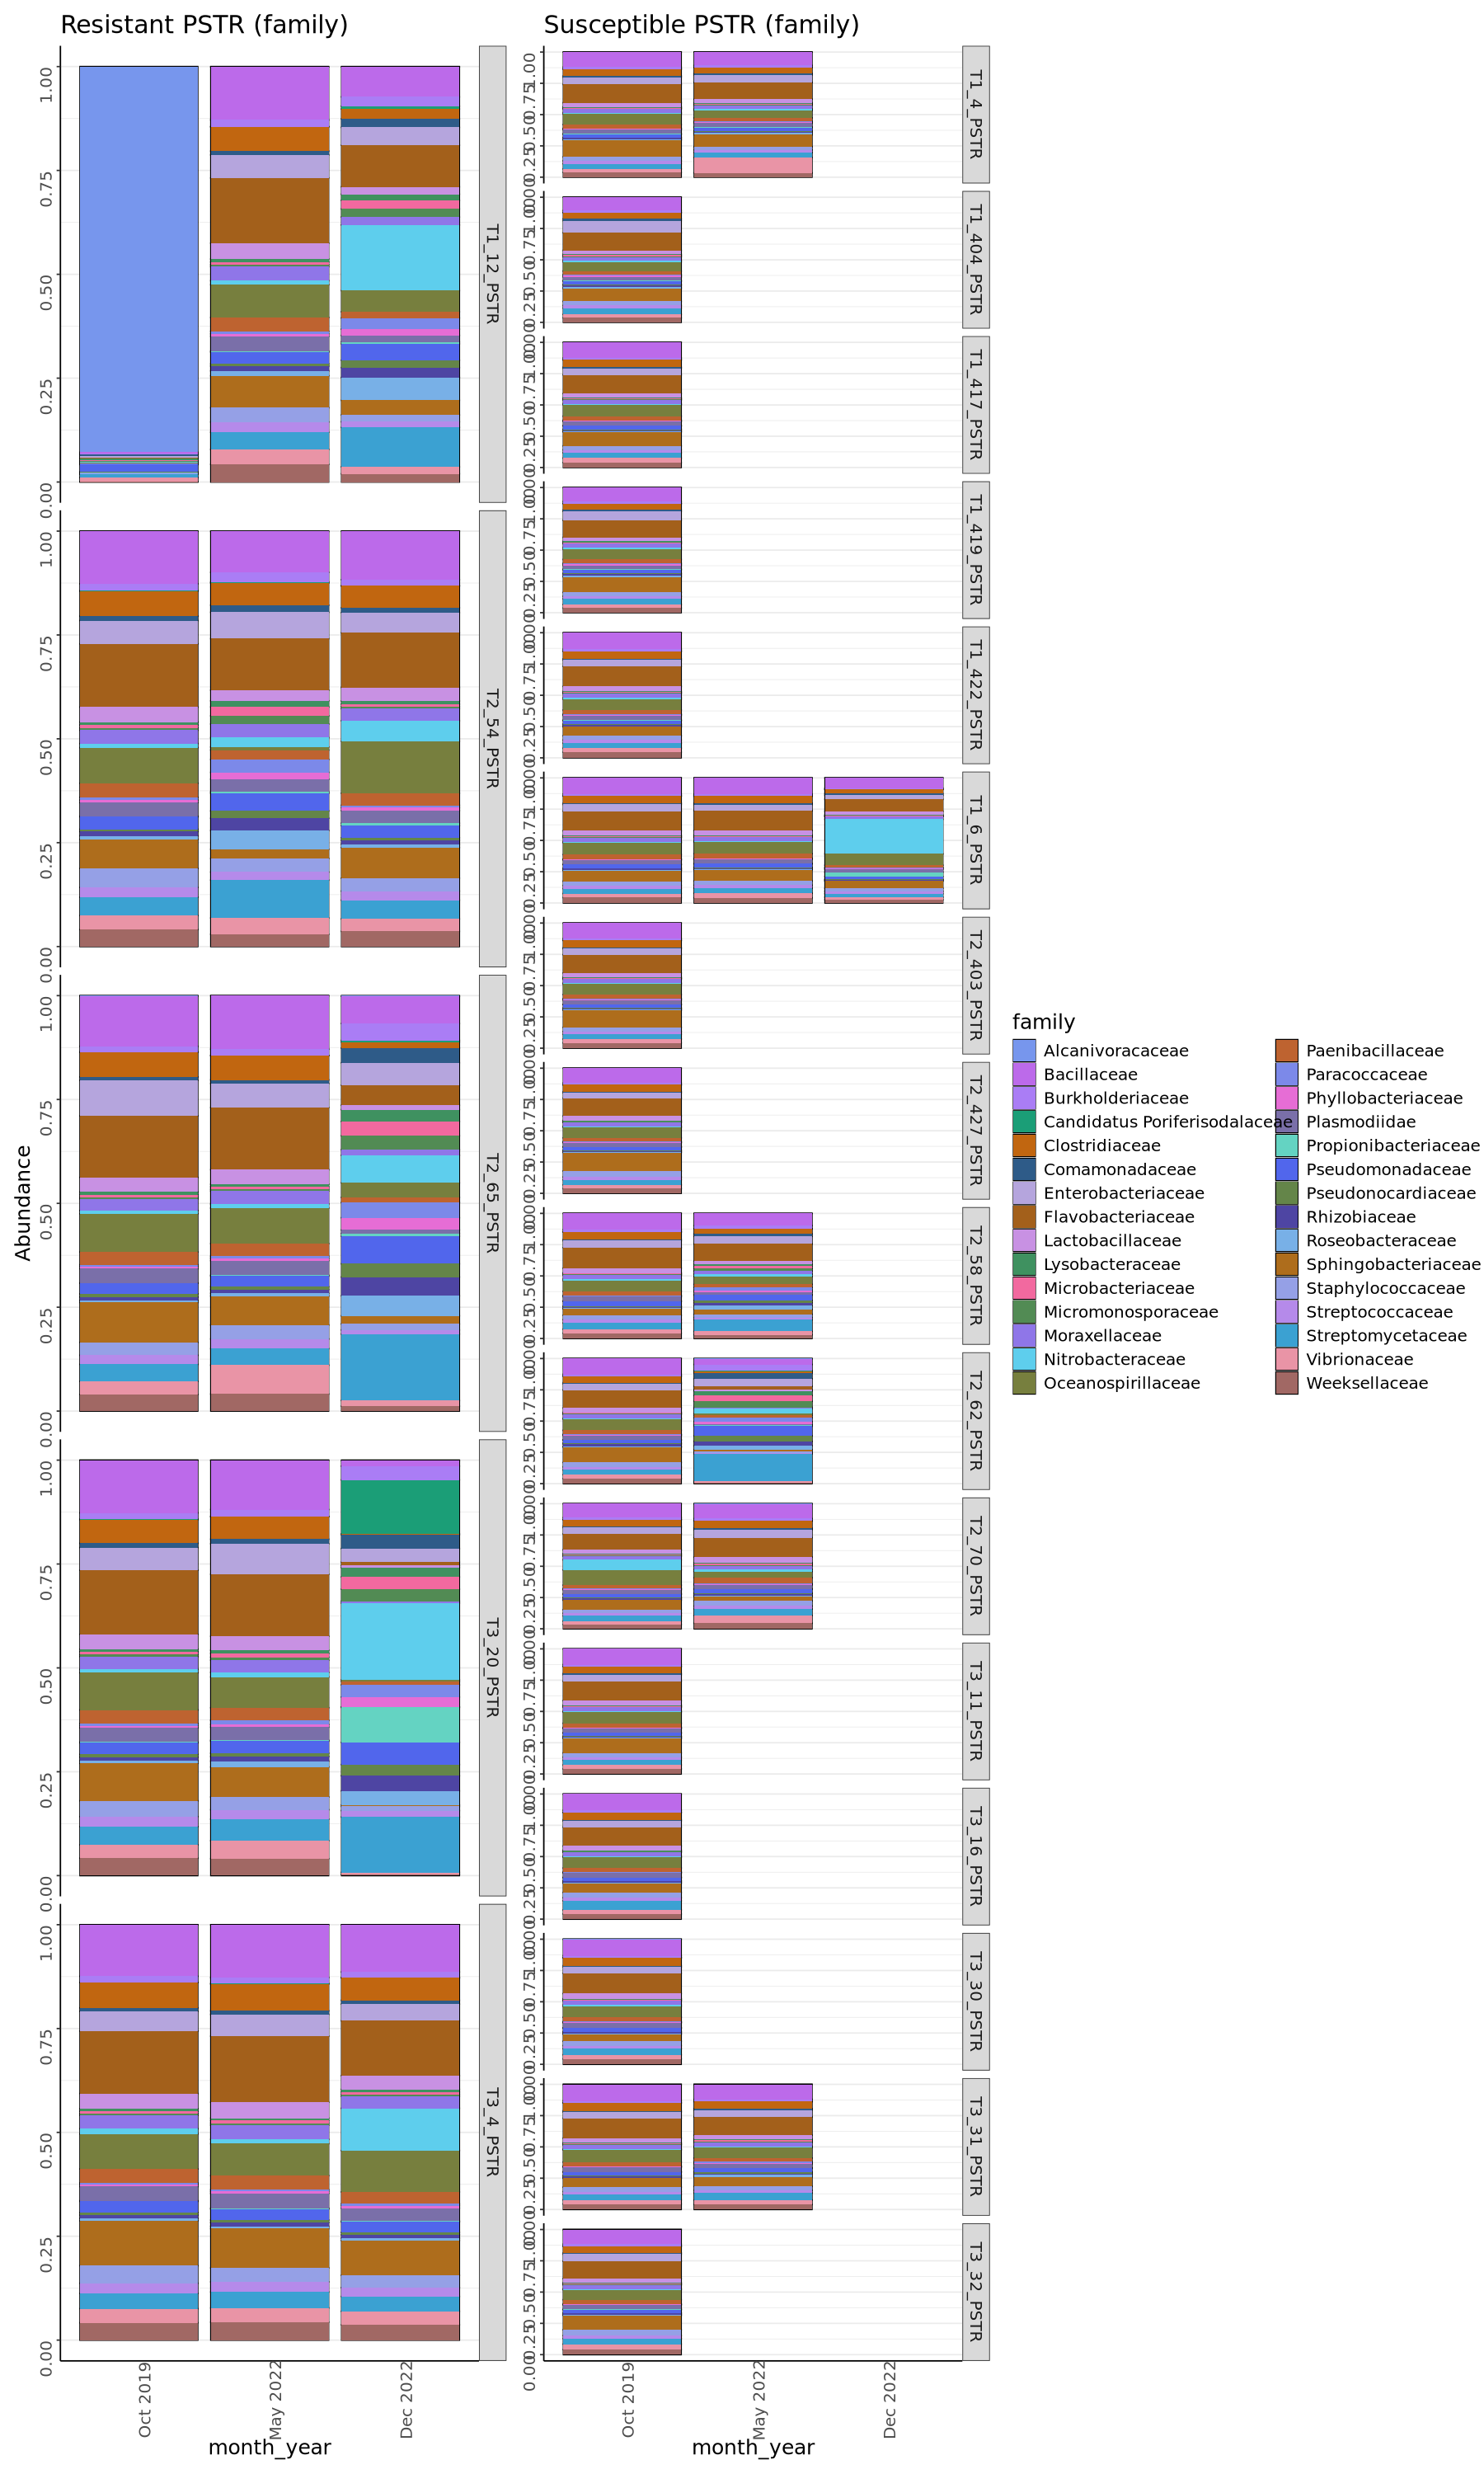

In [146]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(PSTR_30_norm, RS == "Resistant"),x = "month_year", fill = "family")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant PSTR (family)")
p_S <- plot_bar(subset_samples(PSTR_30_norm, RS == "Susceptible"),x = "month_year", fill = "family") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible PSTR (family)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "PSTR colonies") &
  theme(legend.position = "right")
# top 30 family

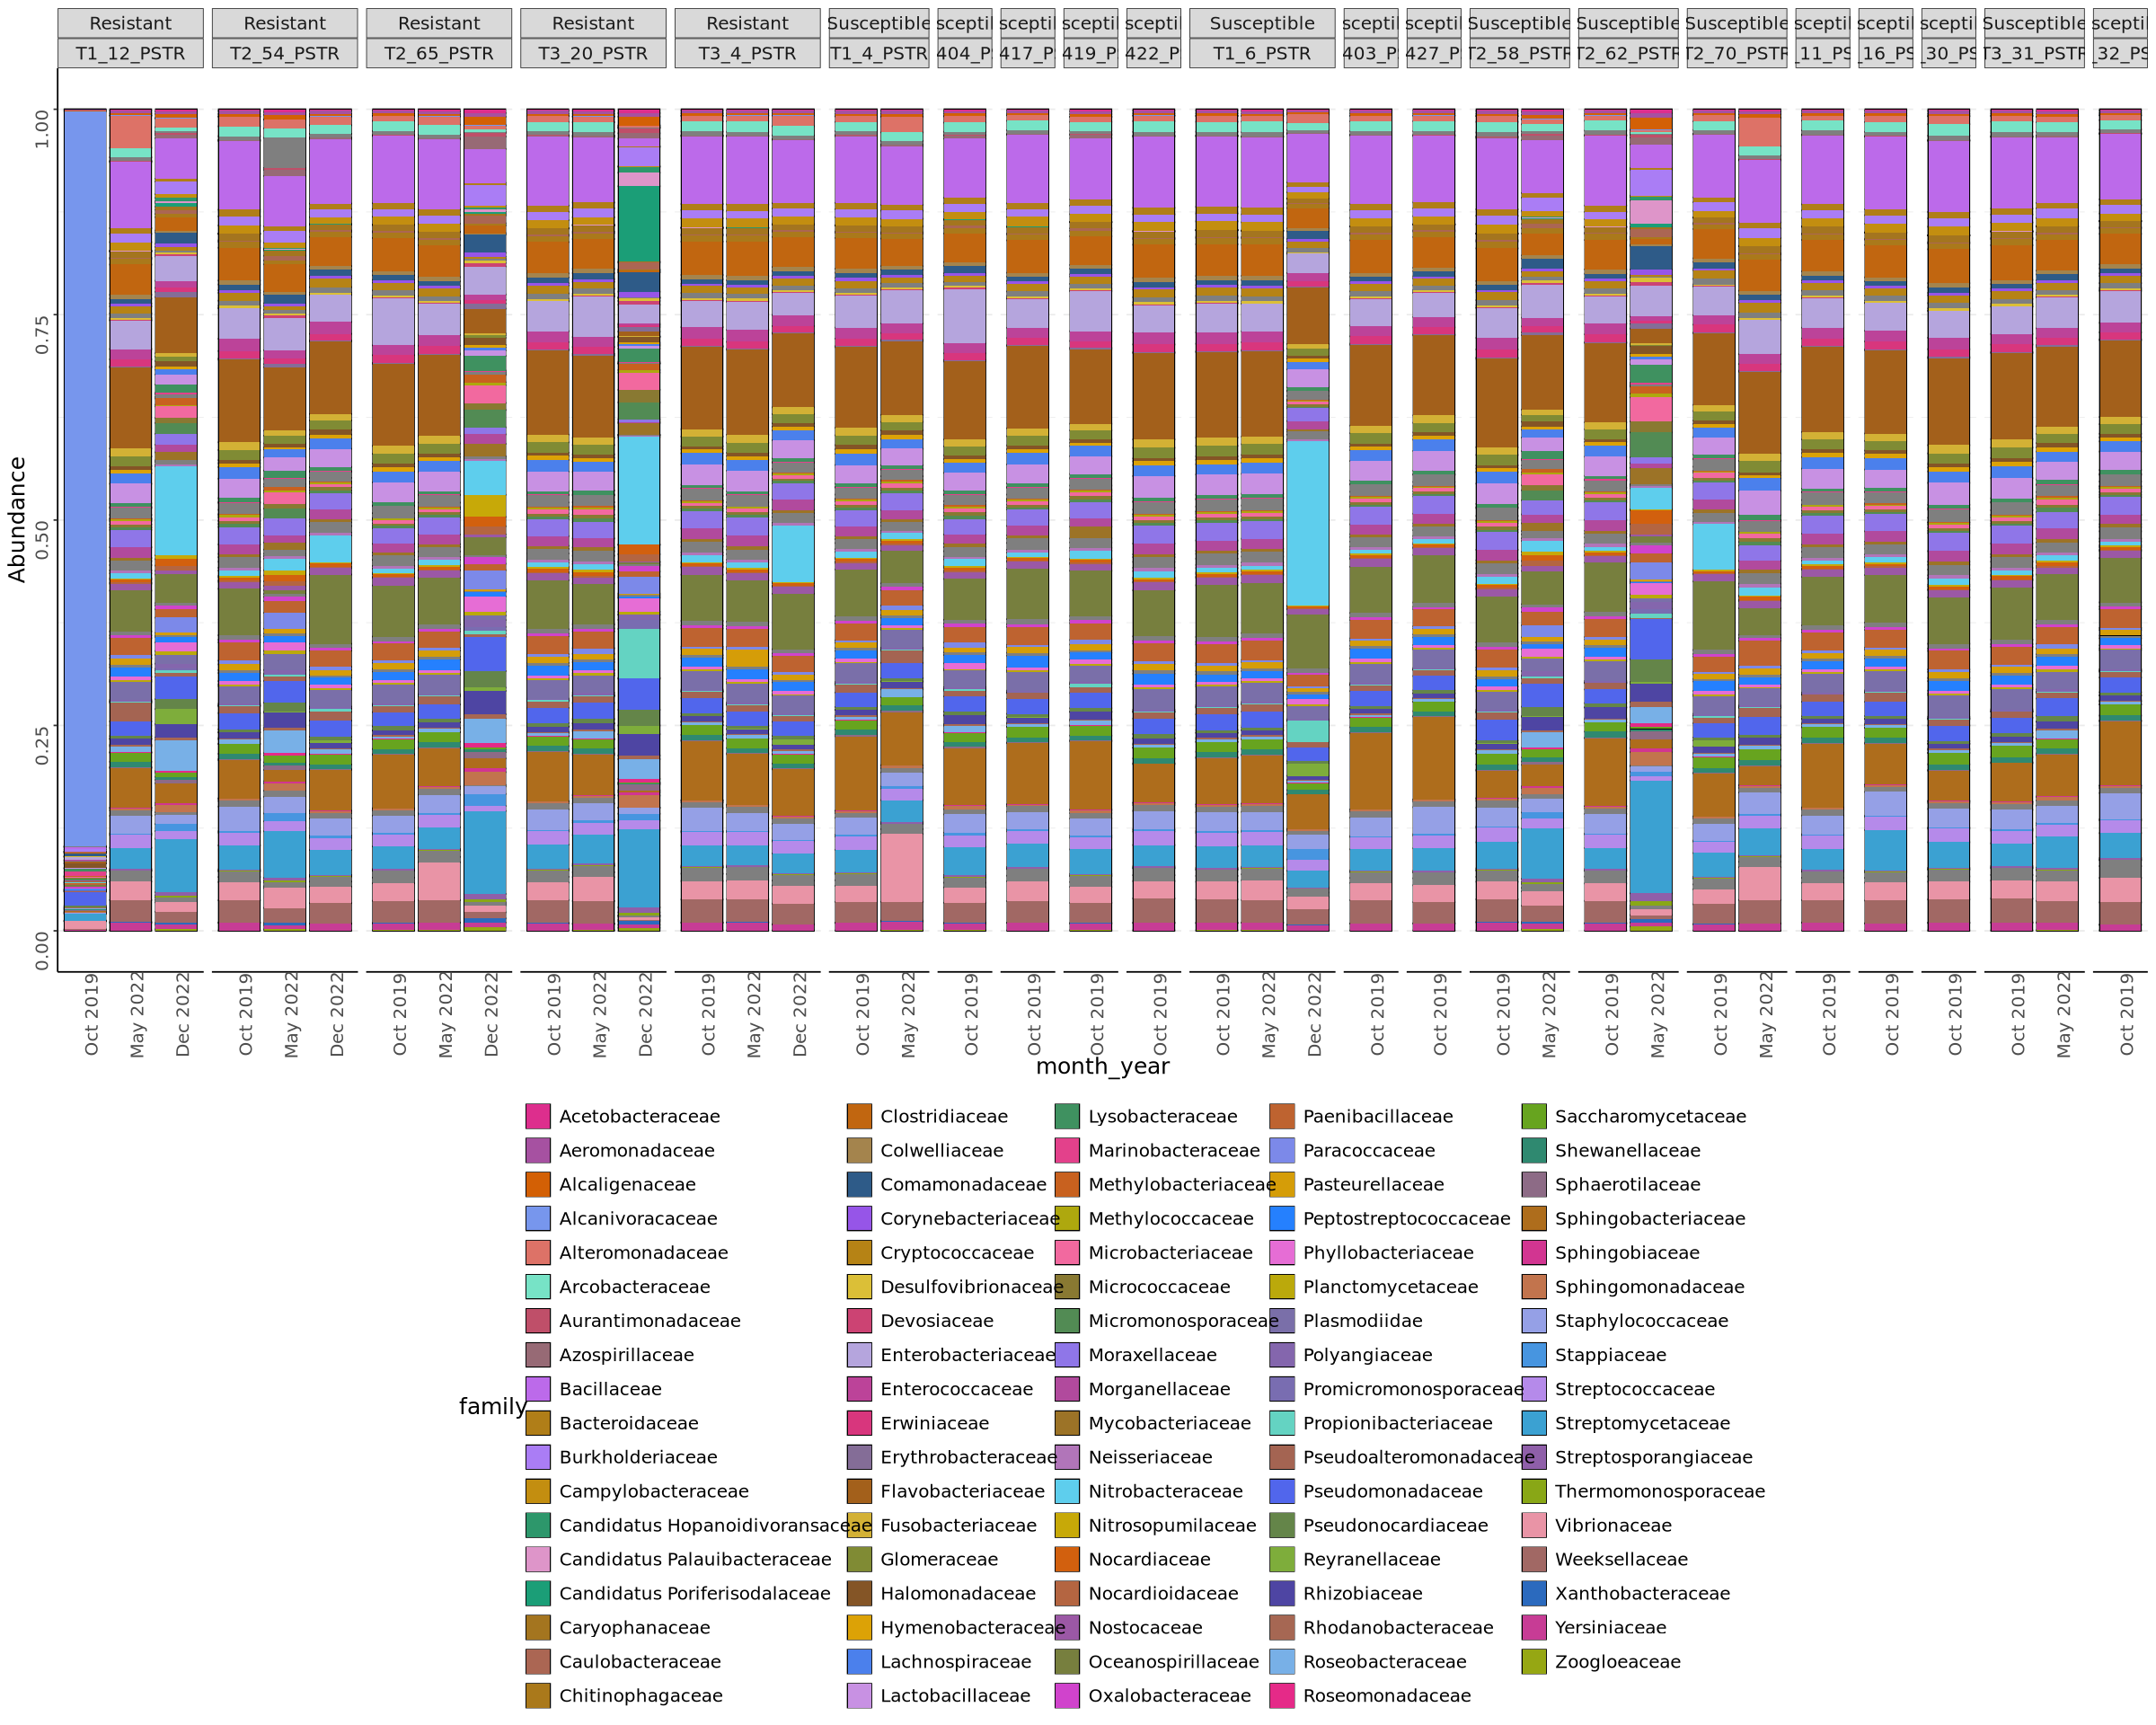

In [147]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (family)

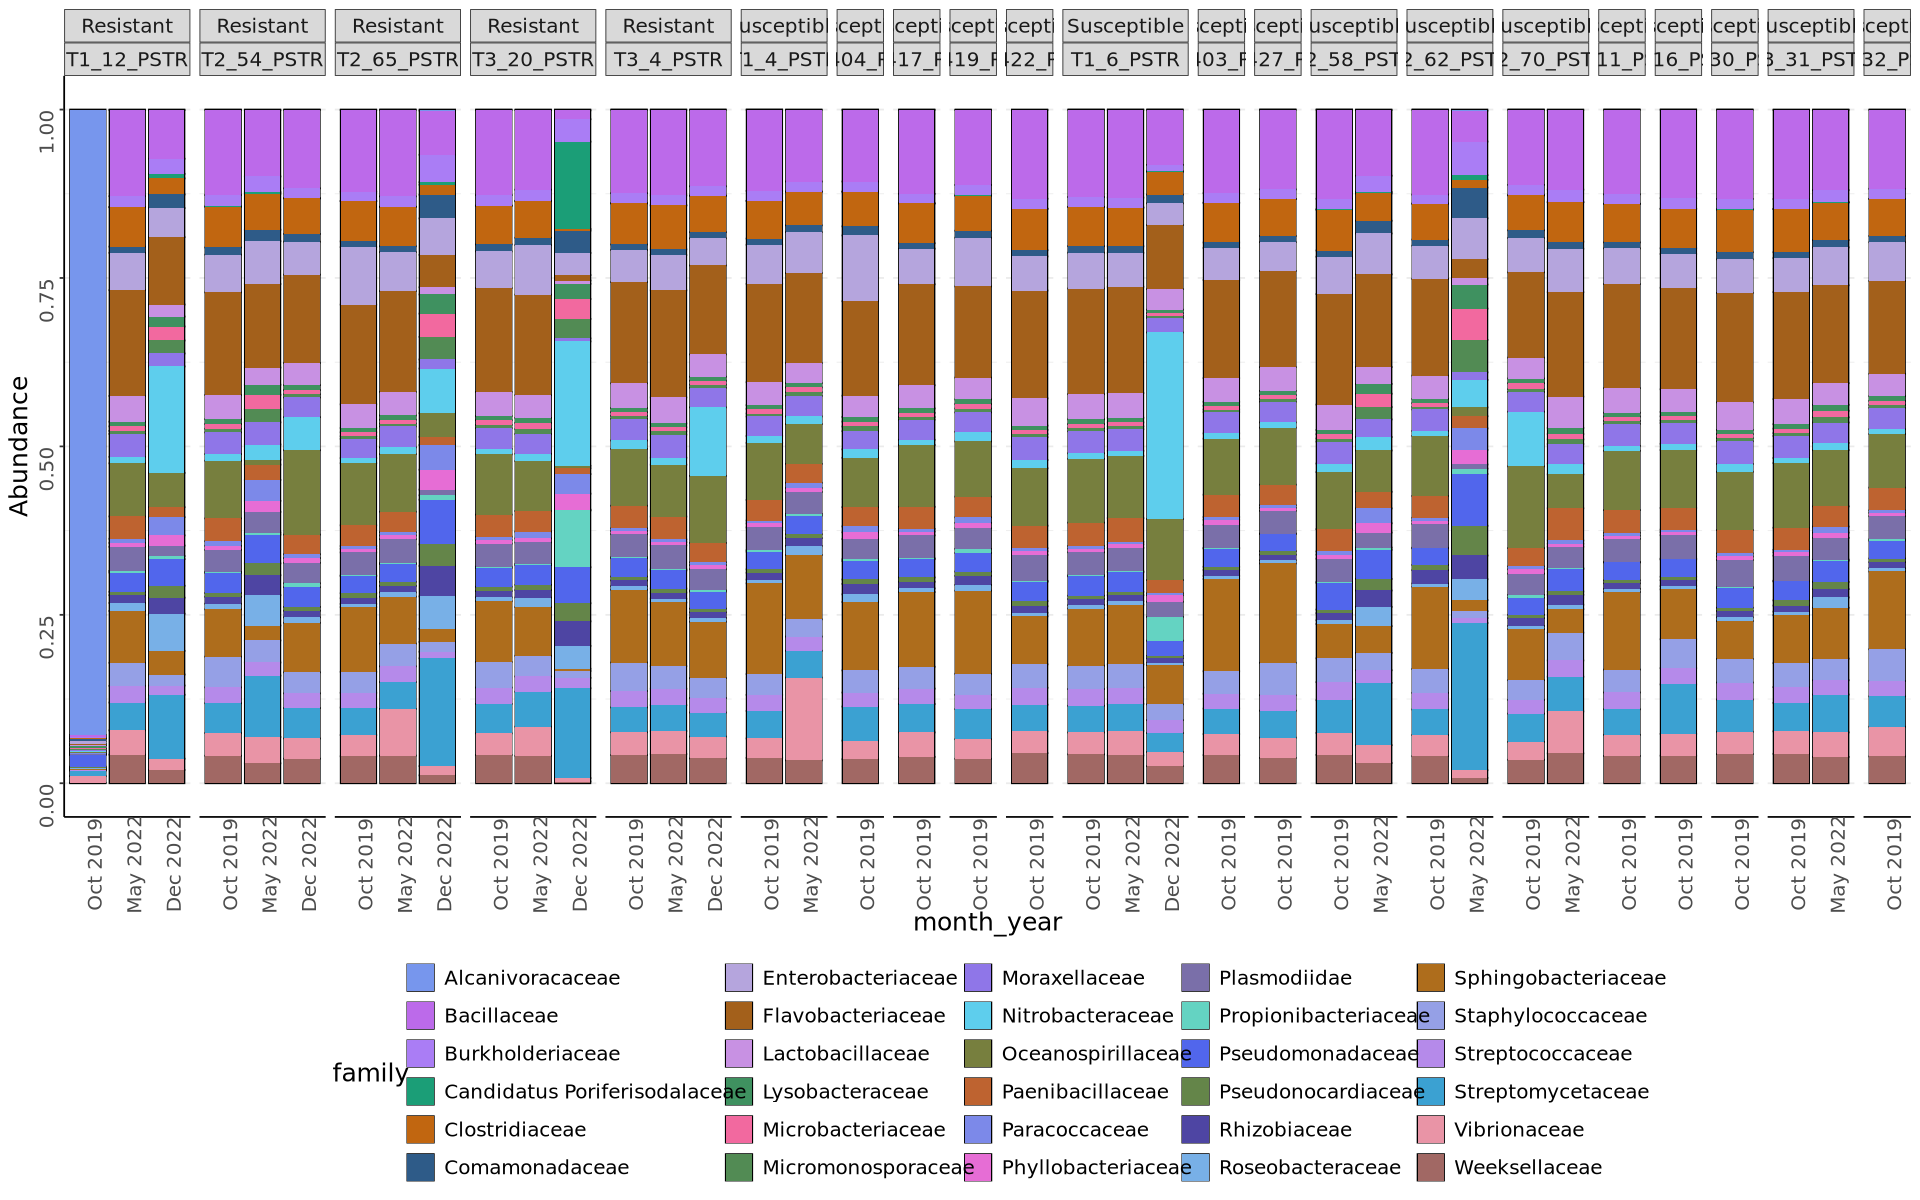

In [148]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_30_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 family - R vs S. individuals over time 

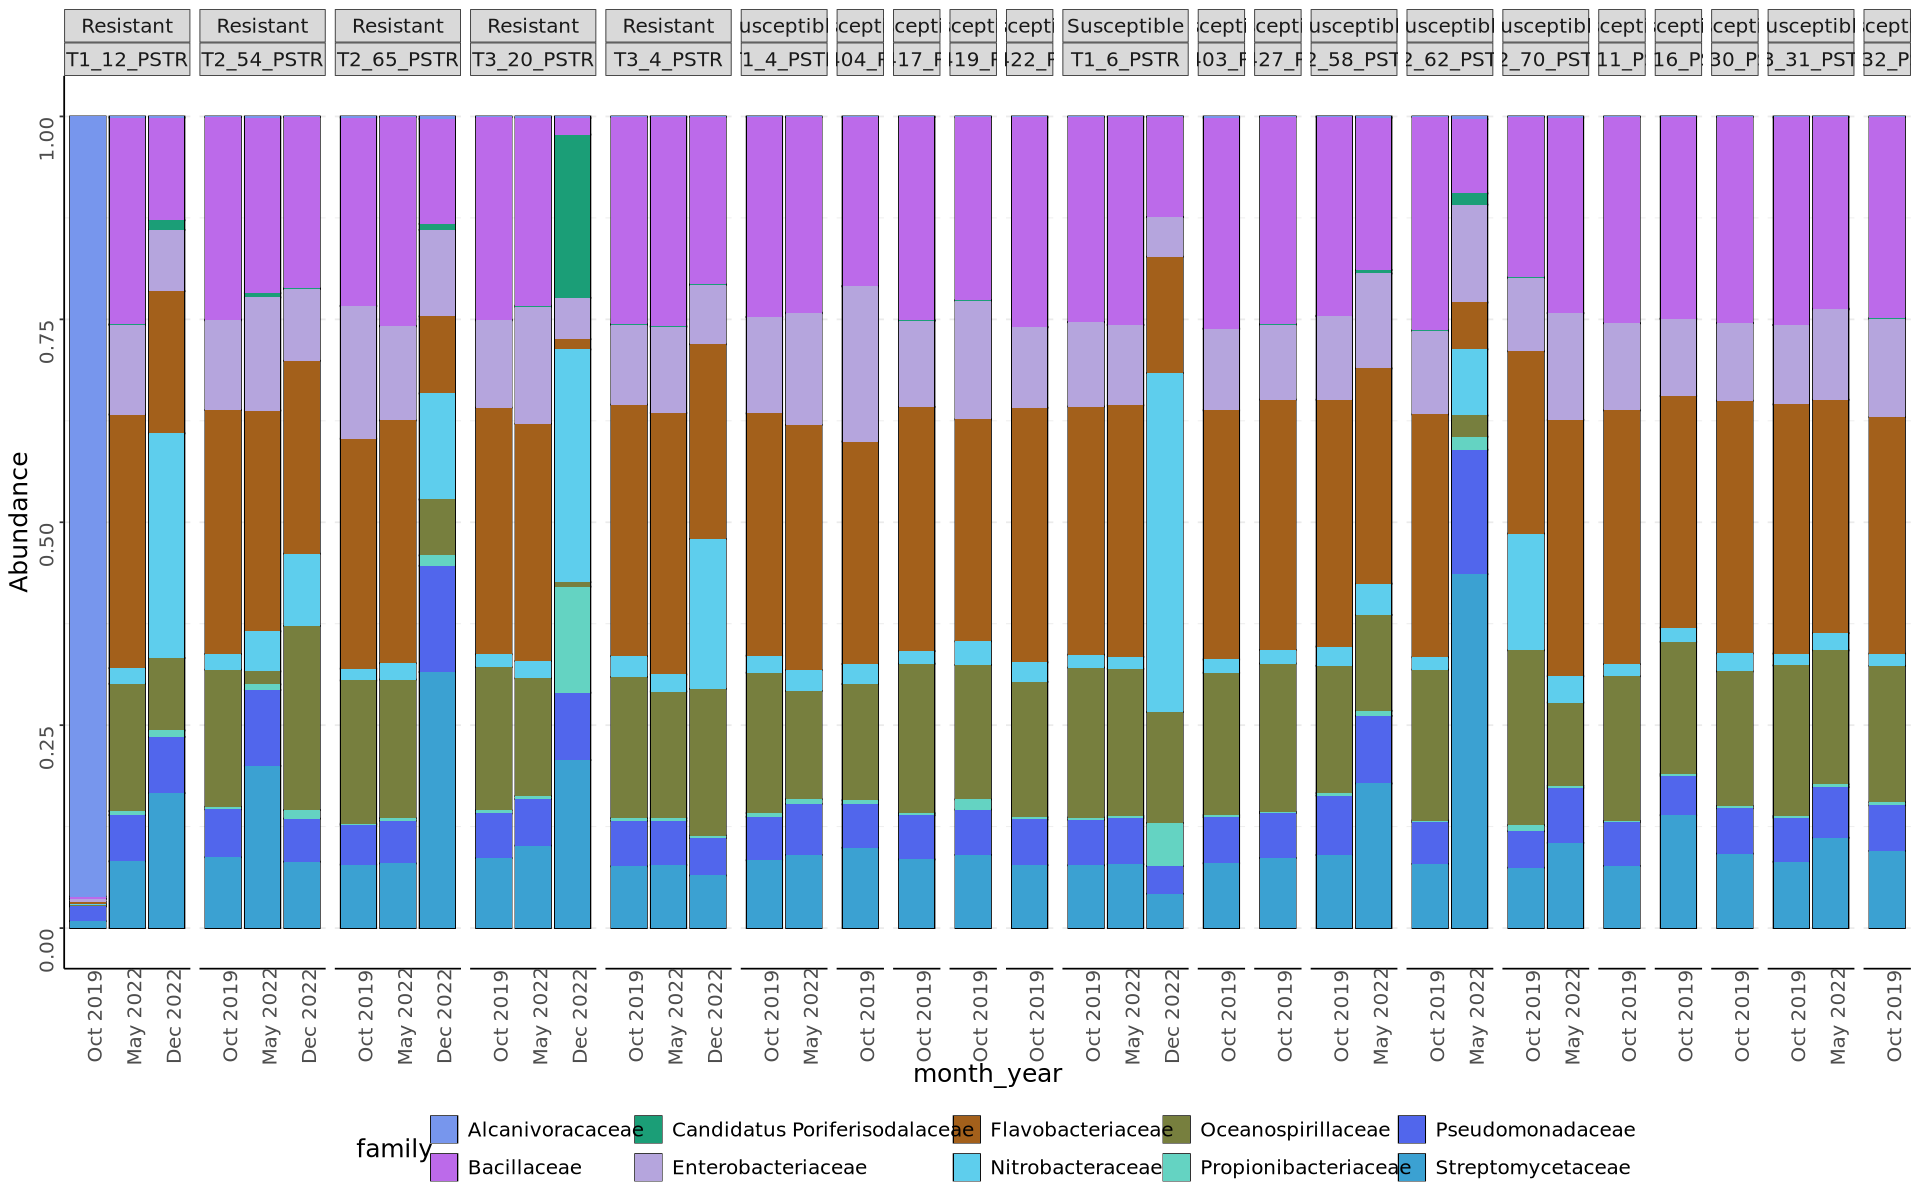

In [149]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_10_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (family)

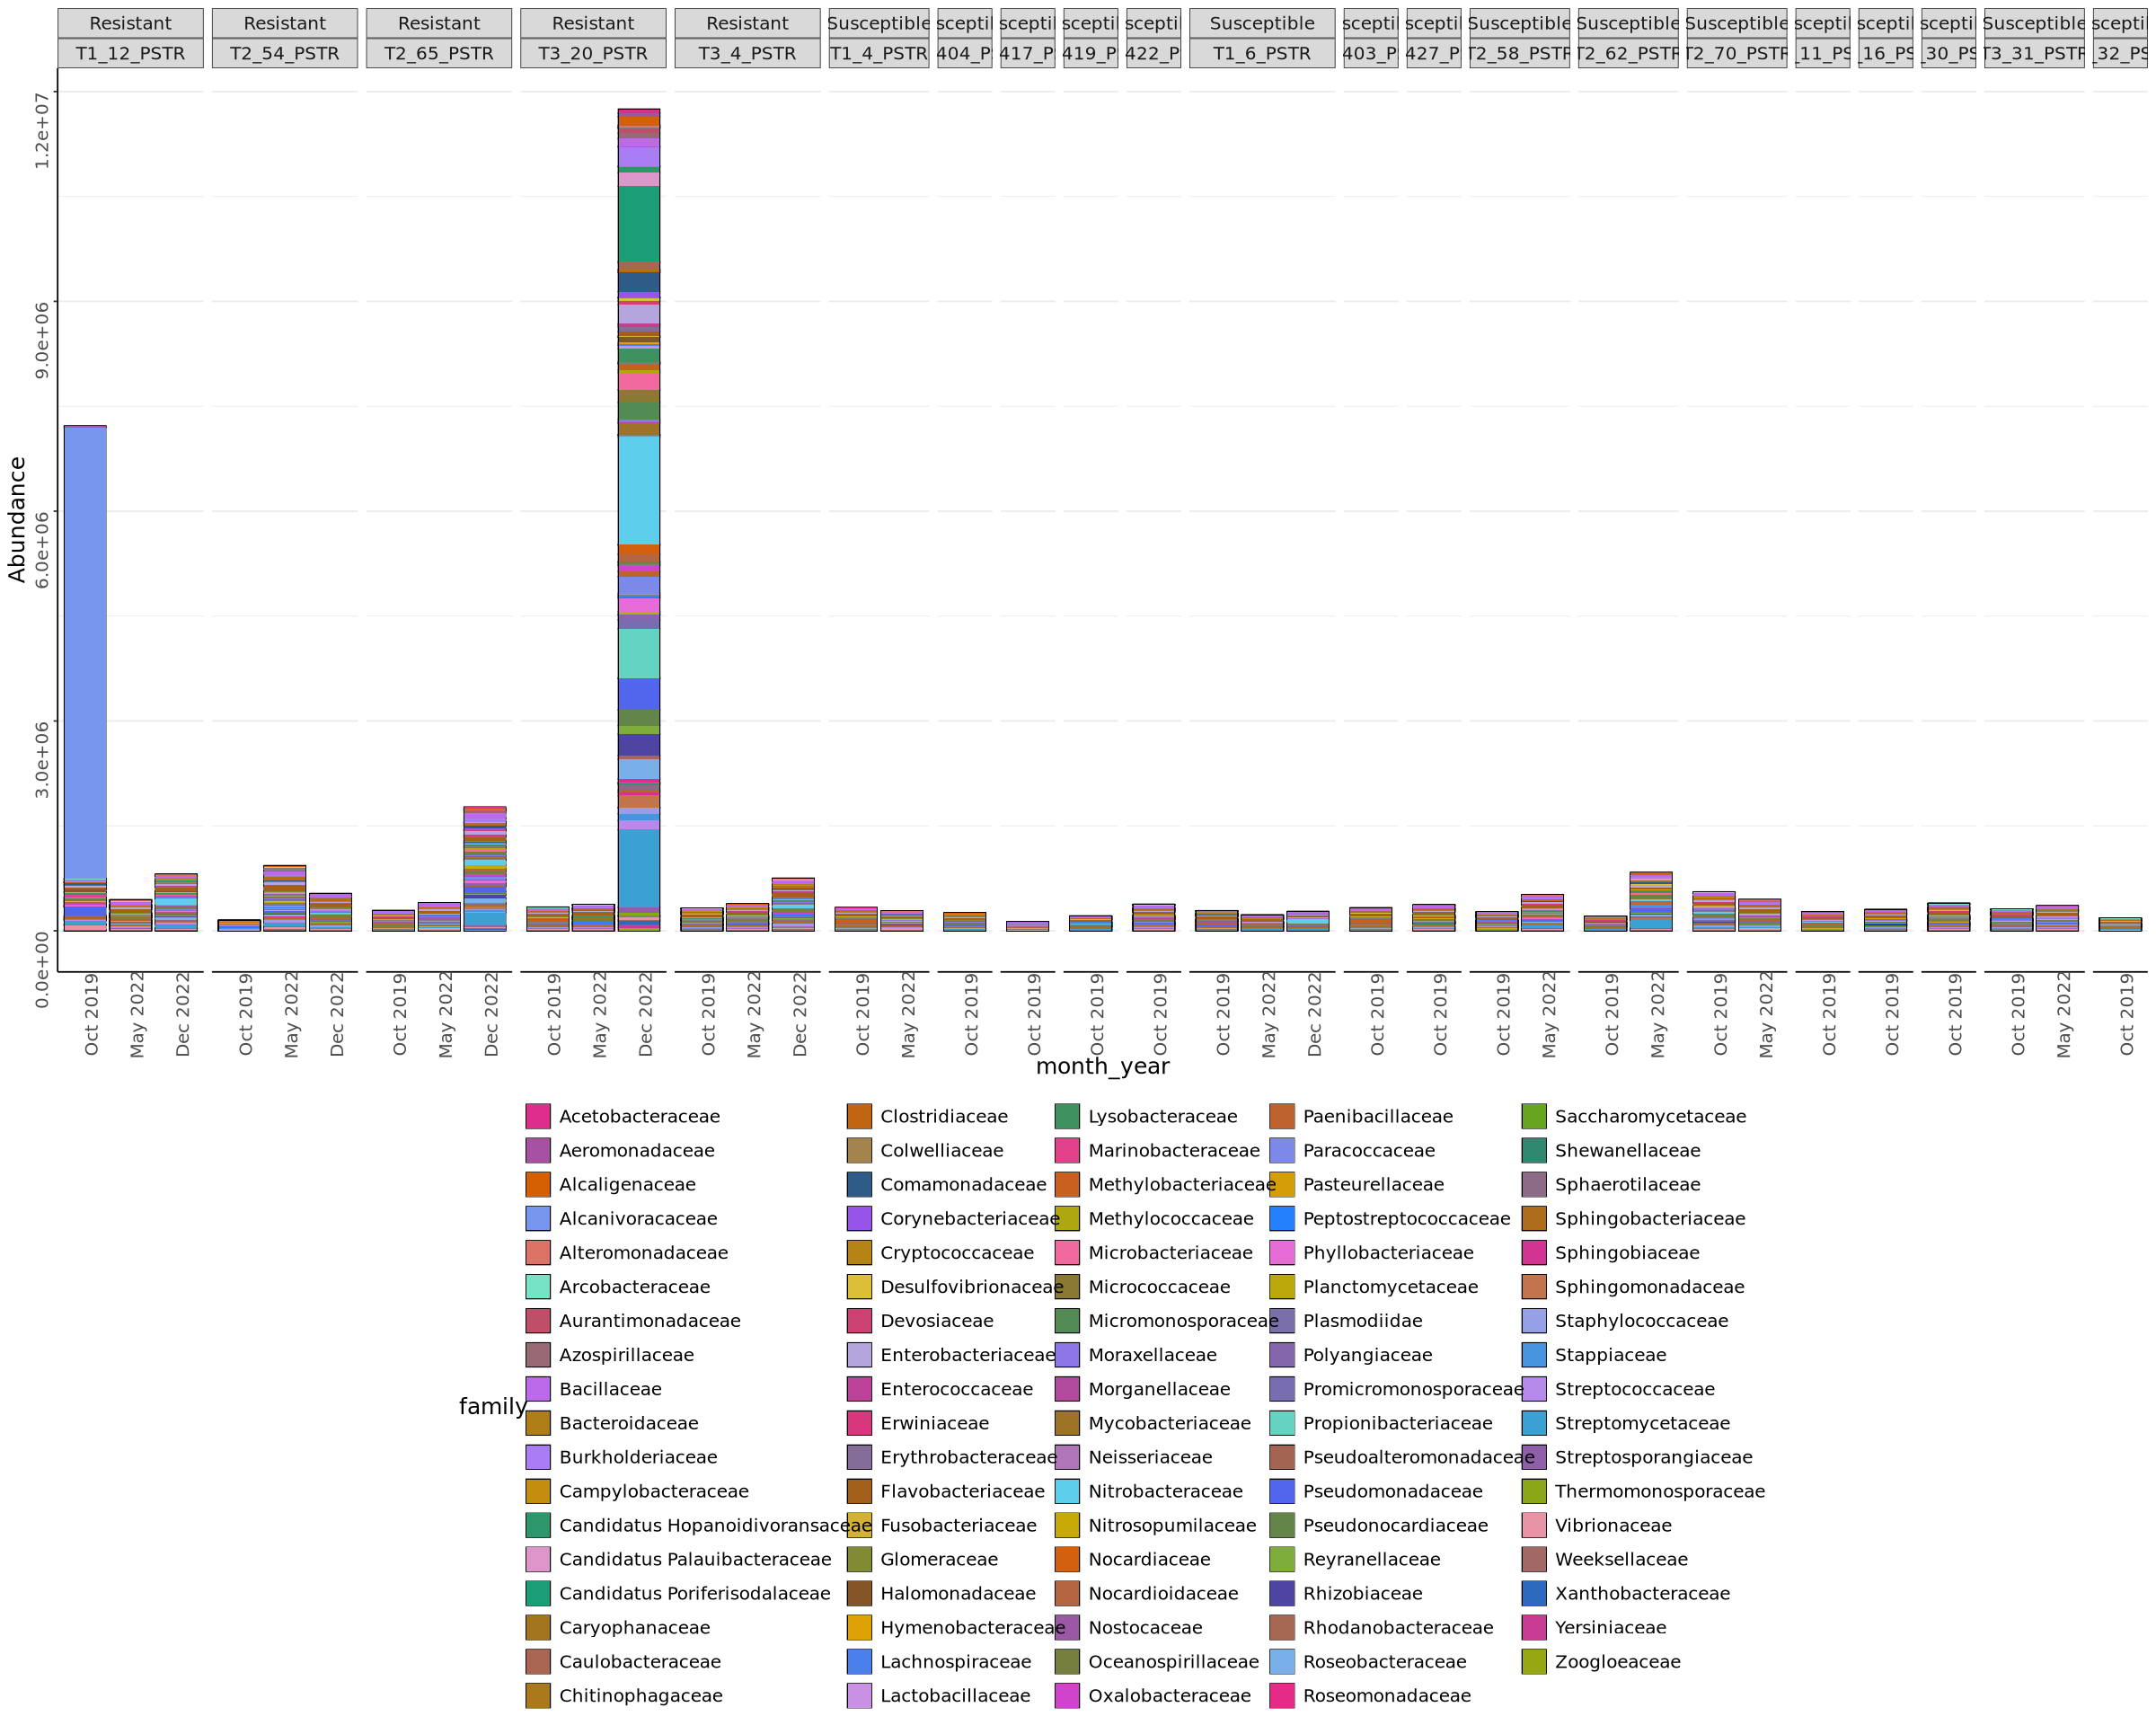

In [150]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (family)

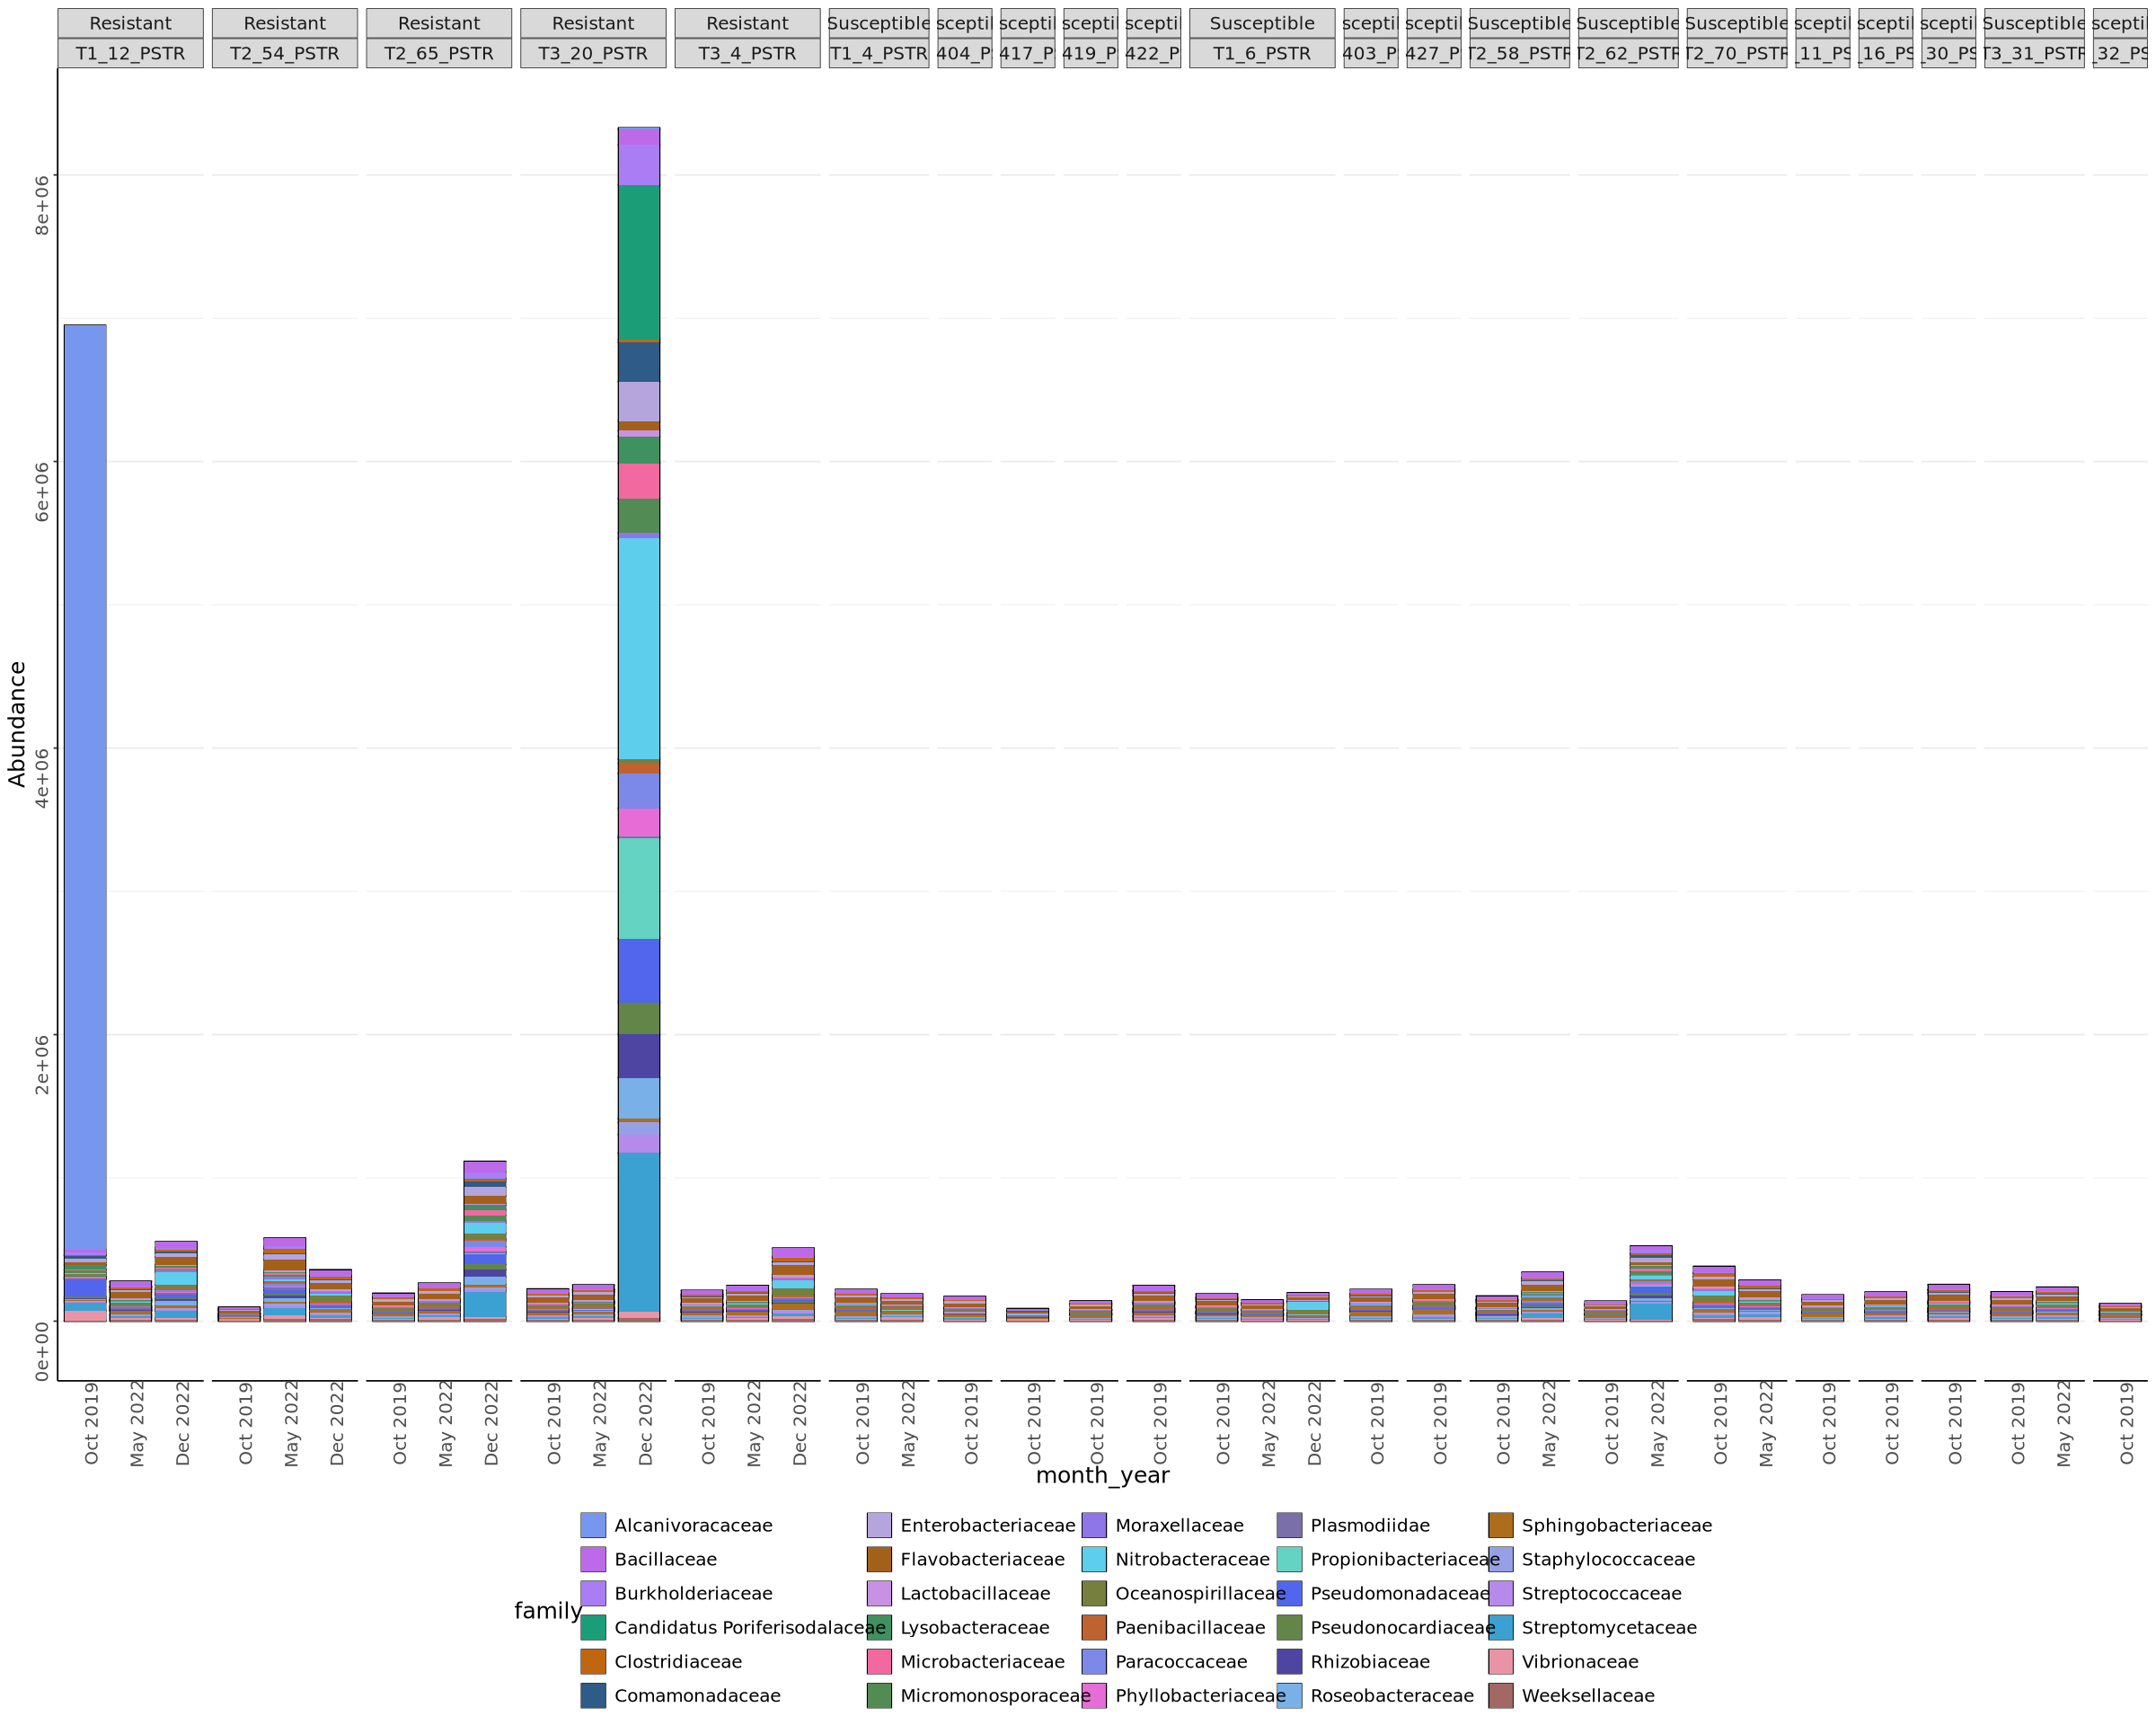

In [151]:
p<-plot_bar(PSTR_30,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (family)

#### MMEA --------------------------------------------------------------------------------

In [152]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [153]:
# mmea

subset_MMEA<- subset_samples(sctld_raw, (Species == "MMEA"))

# top 100 species
MMEA_100 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:100]), subset_MMEA)
MMEA_100_norm <- transform_sample_counts(MMEA_100, function(x) x / sum(x))

MMEA_30 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:30]), subset_MMEA)
MMEA_30_norm <- transform_sample_counts(MMEA_30, function(x) x / sum(x))

# top 10 family
MMEA_10 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:10]), subset_MMEA)
MMEA_10_norm <- transform_sample_counts(MMEA_10, function(x) x / sum(x))

In [154]:
df_meta <- data.frame(sample_data(subset_MMEA))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_MMEA) <- sample_data(df_meta)

In [155]:
# reorder colonies
MMEA_g_S<-subset_samples(subset_MMEA, RS == "Susceptible")
df_meta<-data.frame(sample_data(MMEA_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(subset_MMEA)$colony_id <-
  factor(sample_data(subset_MMEA)$colony_id, levels = col_order)

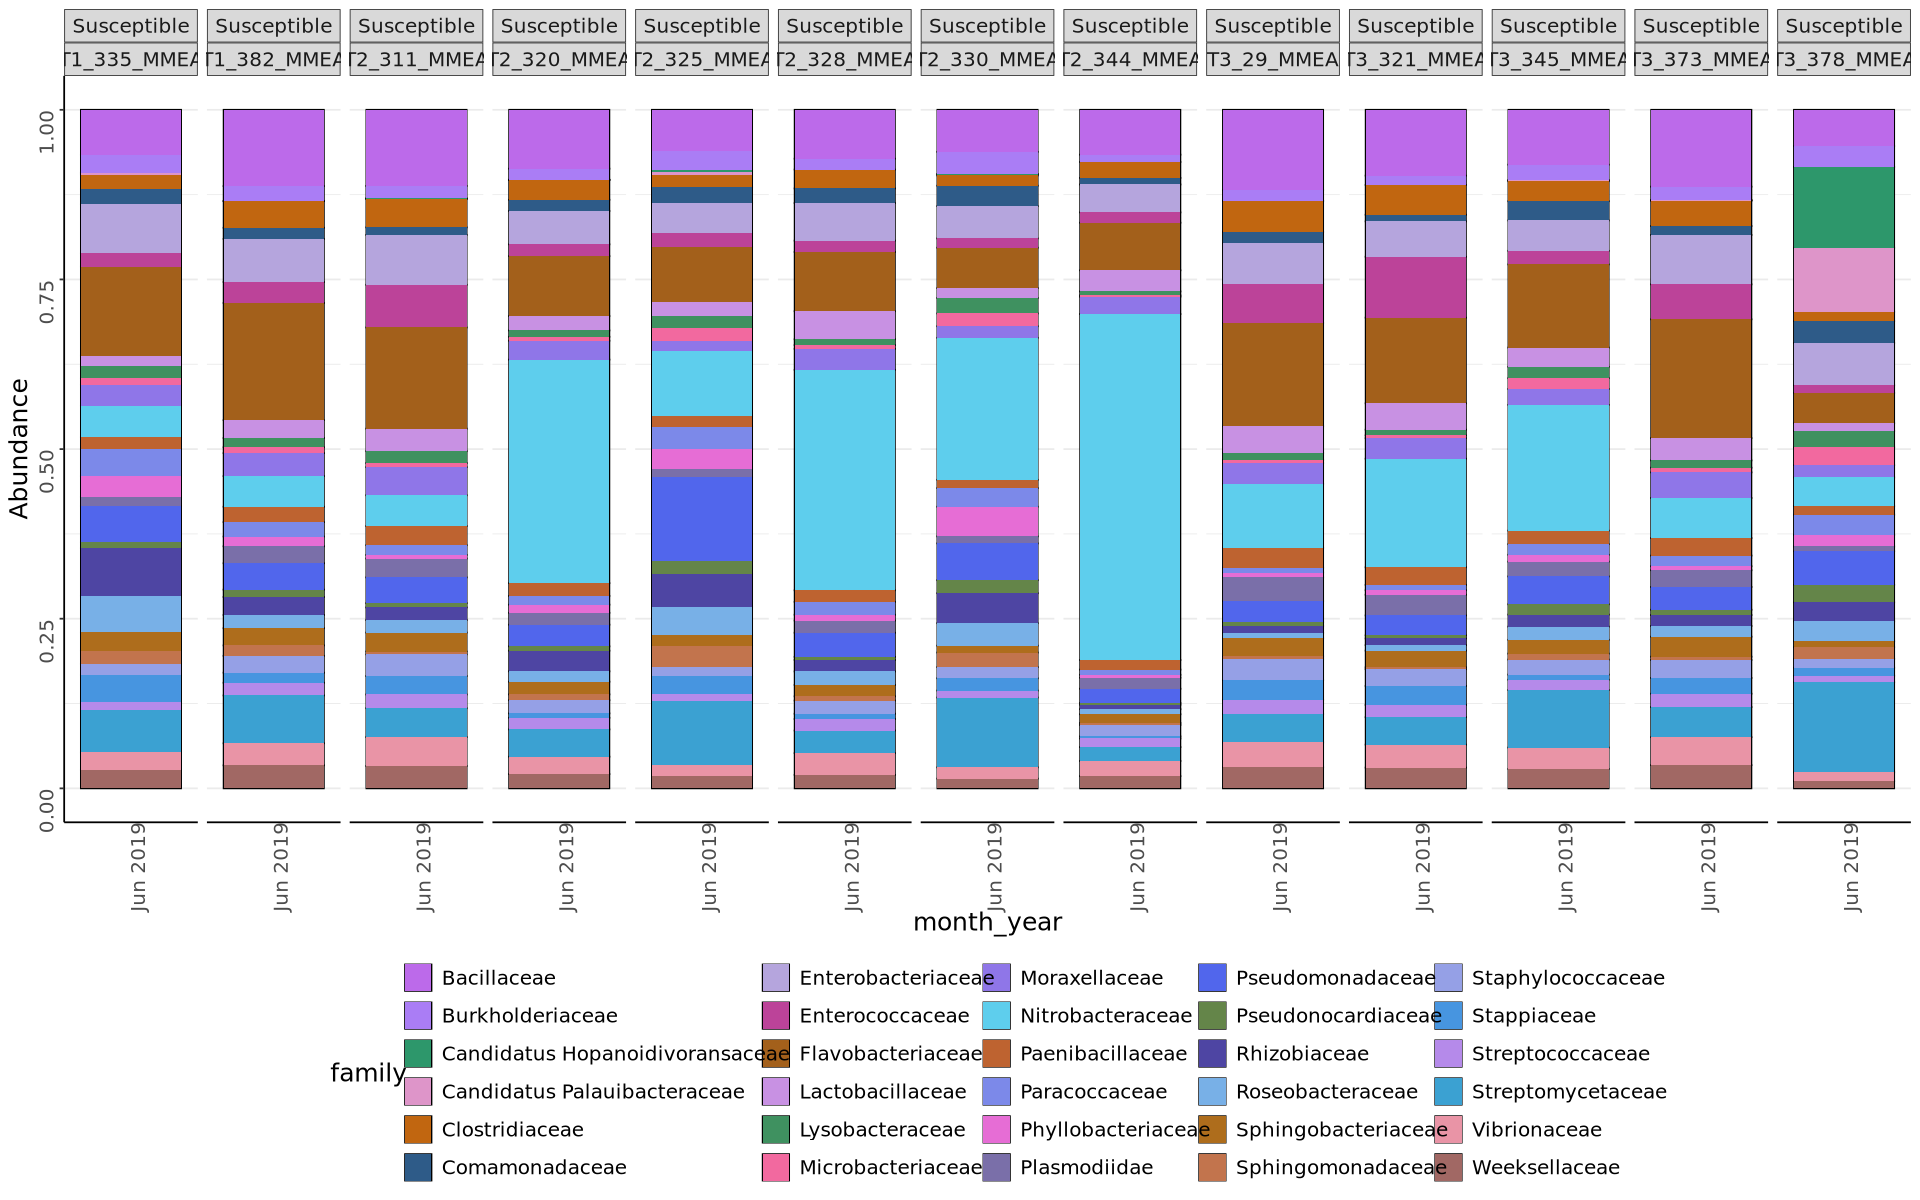

In [156]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_30_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 family - R vs S. individuals over time 

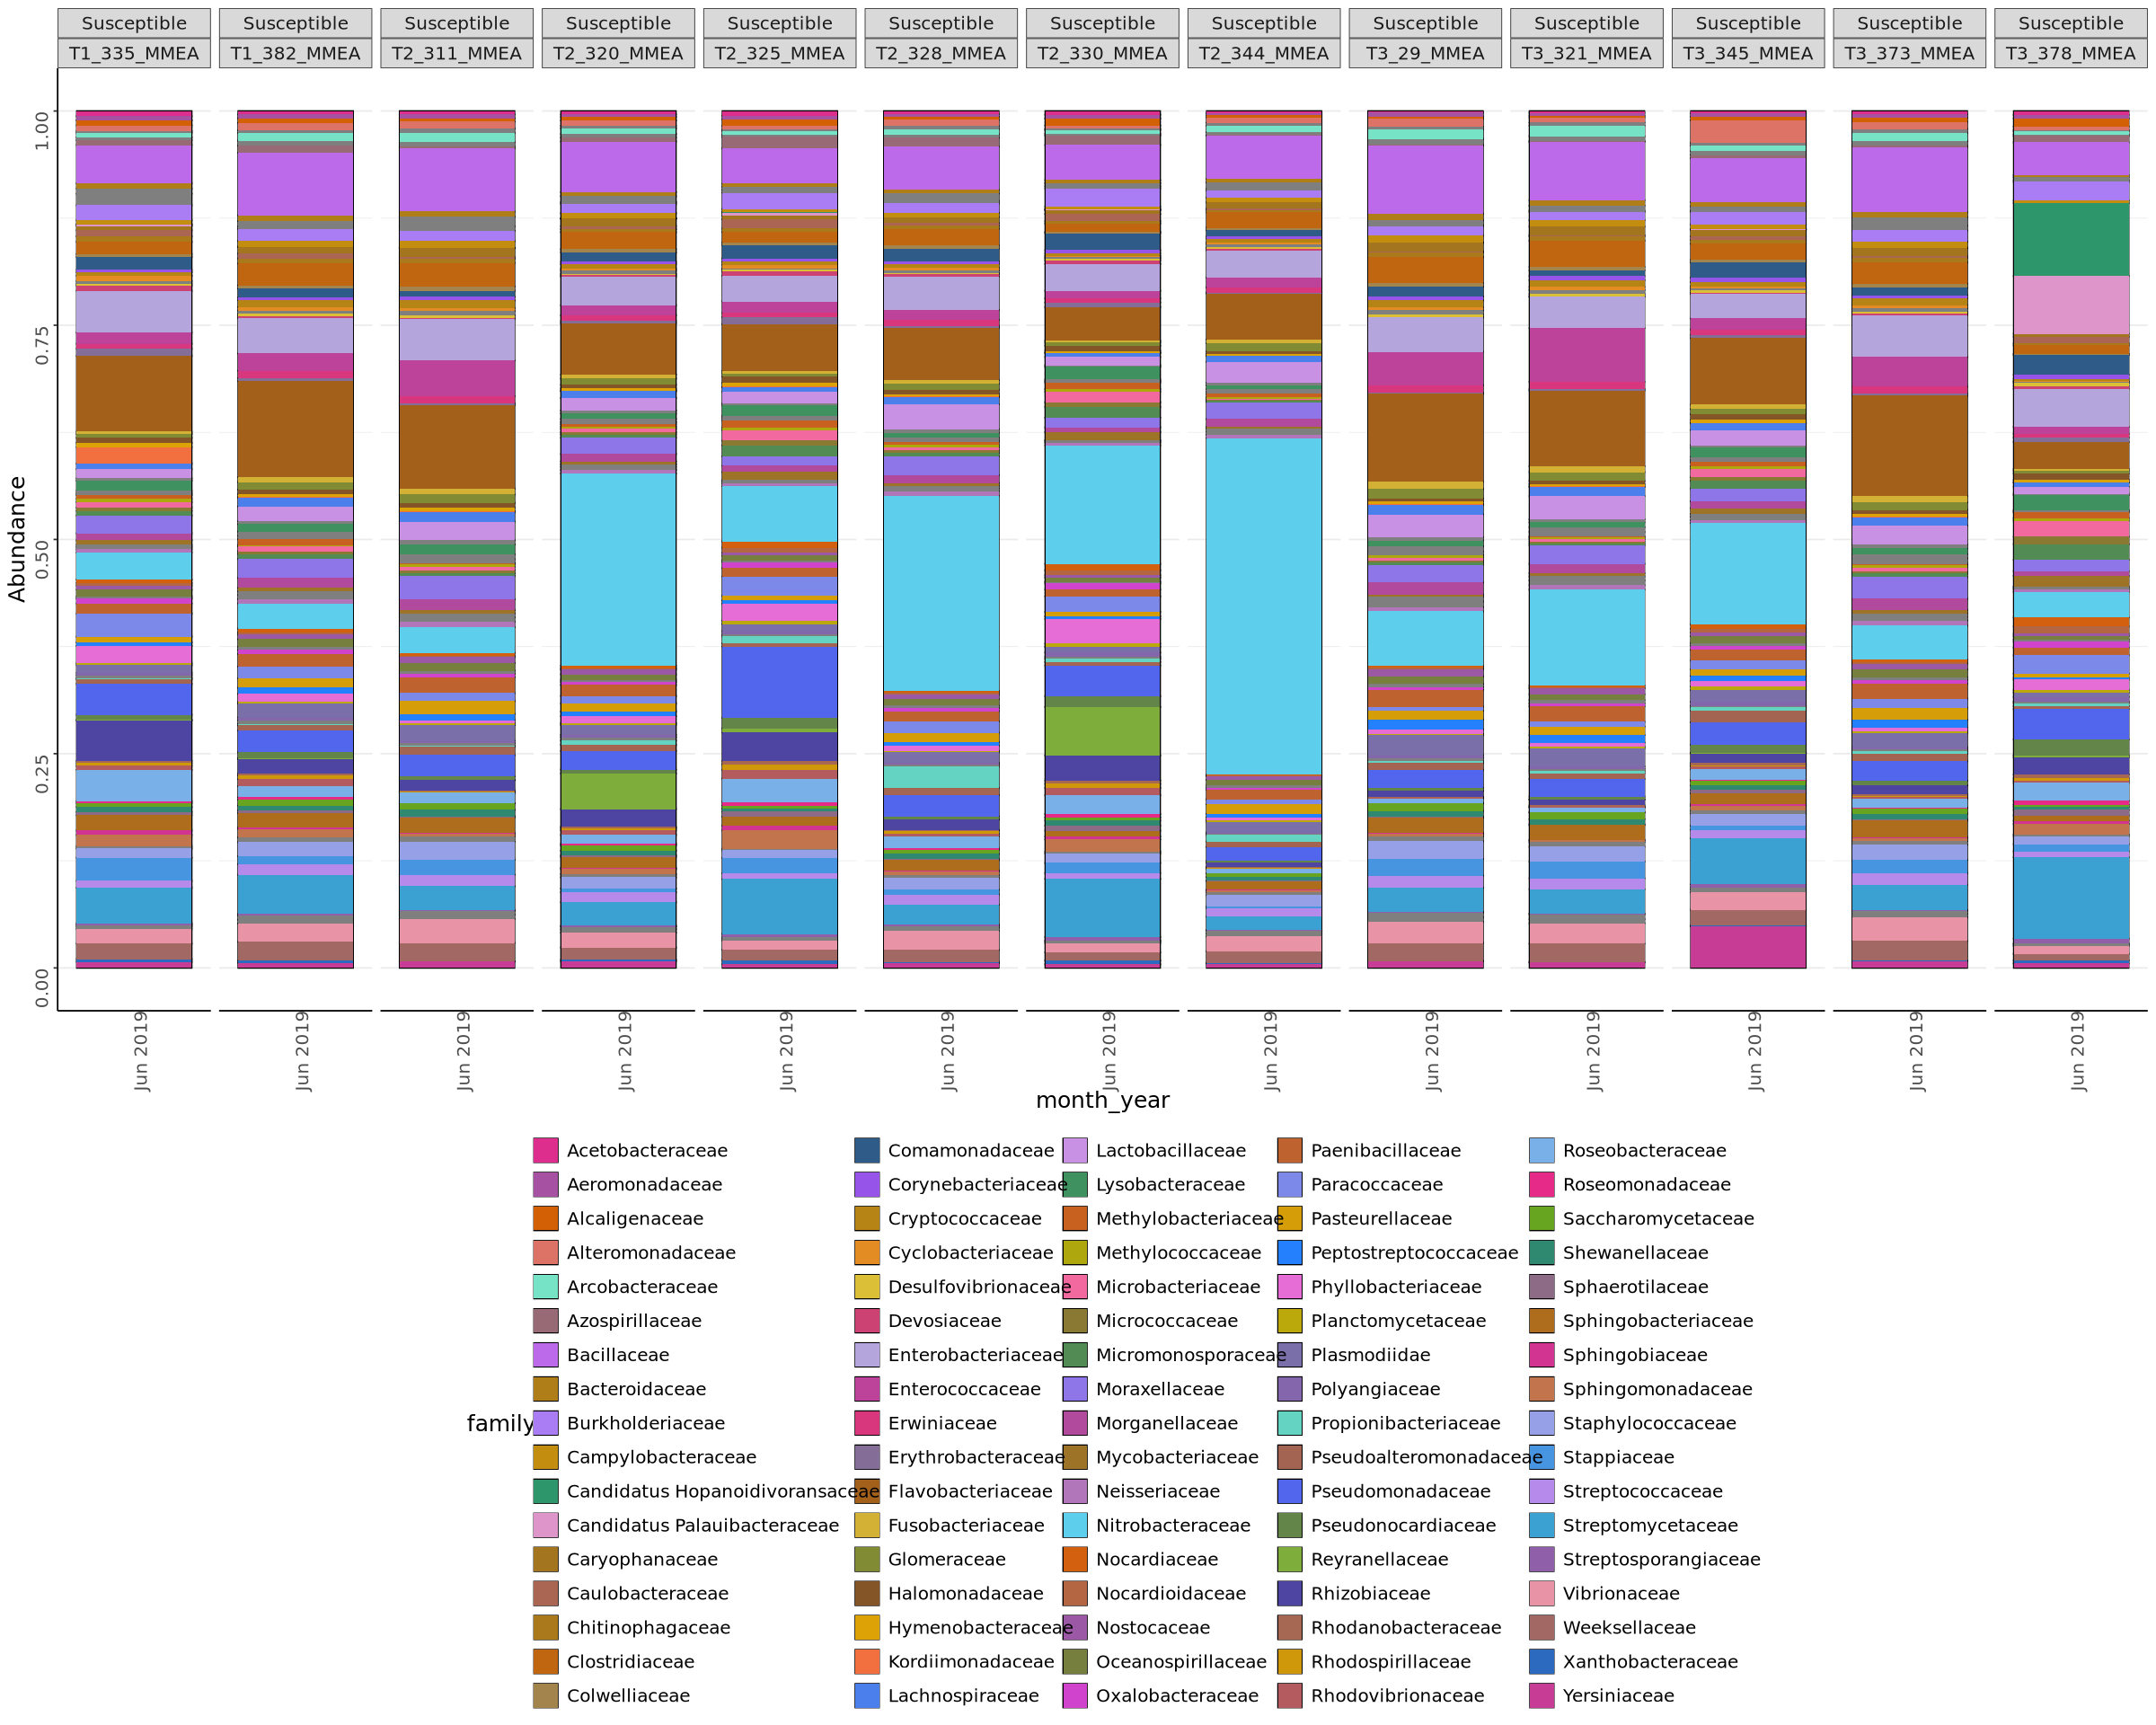

In [157]:
options(repr.plot.height = 16, repr.plot.width = 20)

p<-plot_bar(MMEA_100_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (family)

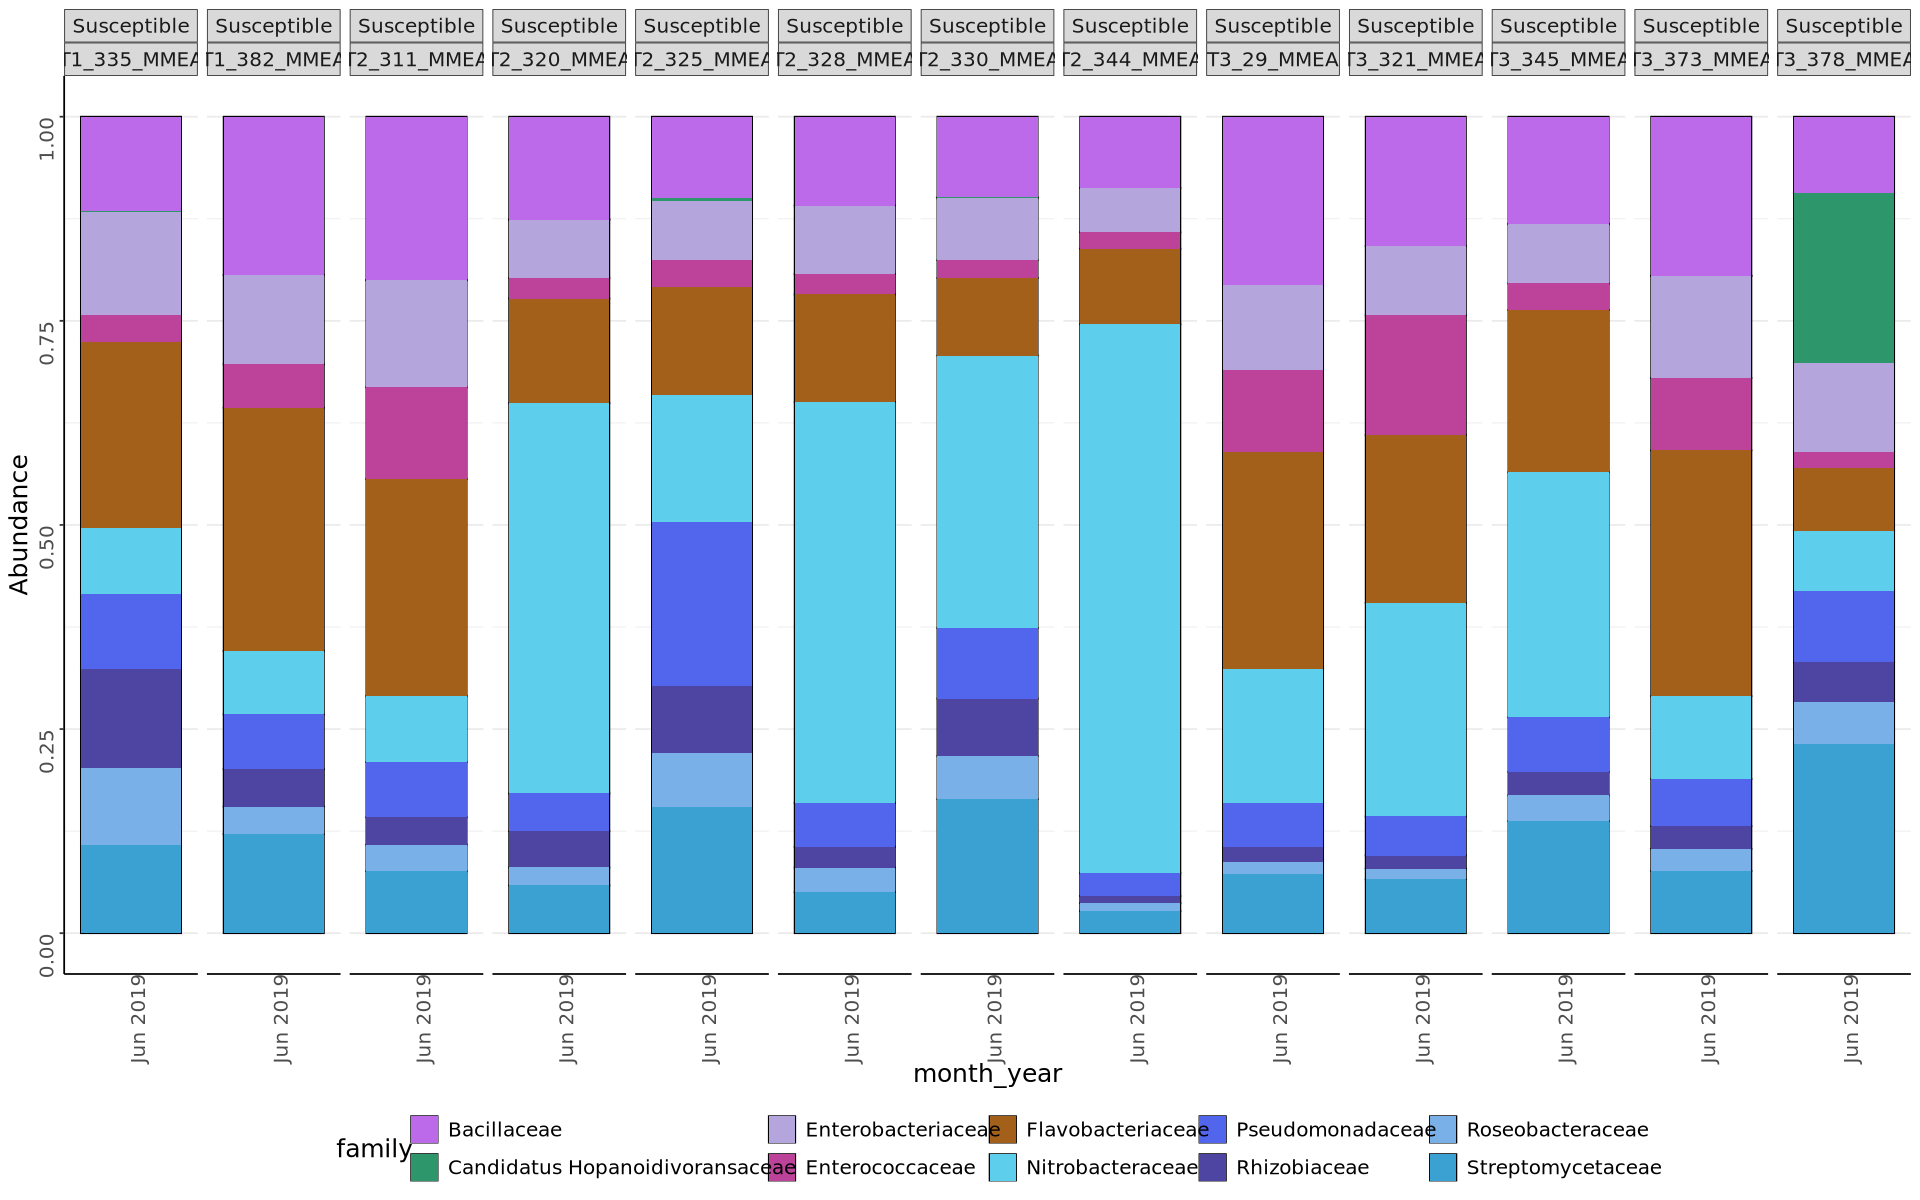

In [158]:
# top 30 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_10_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (family)

#### PAST --------------------------------------------------------------------------------

In [159]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [160]:
# looking just at PAST, remove disease margin

subset_PAST<- subset_samples(sctld_raw, (Species == "PAST" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PAST<- subset_samples(subset_PAST, (!(Date_InitialTag %in% dec_tags)))

# top 100 species
PAST_100 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:100]), subset_PAST)
PAST_100_norm <- transform_sample_counts(PAST_100, function(x) x / sum(x))

PAST_30 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:30]), subset_PAST)
PAST_30_norm <- transform_sample_counts(PAST_30, function(x) x / sum(x))

PAST_10 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:10]), subset_PAST)
PAST_10_norm <- transform_sample_counts(PAST_10, function(x) x / sum(x))

In [161]:
df_meta <- data.frame(sample_data(subset_PAST))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PAST) <- sample_data(df_meta)

In [162]:
# "resistant" colonies that don't have 2022 data 
colony %>%
    filter(colony_id == "T2_47_PAST" | colony_id == "T3_13_PAST") %>%
    select(colony_id, X122022_Condition, X092023_Condition, X012024_Condition, X042024_Condition)
# t3 13 was found again and sampled as healthy in 4/2024, looks like just missed the sample but we have healthy documented in 122022
# remove t2 47 - next sample in 6/2025 and I'm not convinced its the same colony 
# SUS T2 347 was Dead in 05/2022

colony_id,X122022_Condition,X092023_Condition,X012024_Condition,X042024_Condition
<chr>,<chr>,<chr>,<chr>,<chr>
T2_47_PAST,Not_Visited,Not_Visited,Not_Visited,Not_Visited
T3_13_PAST,Healthy,Not_Visited,CLB,Healthy


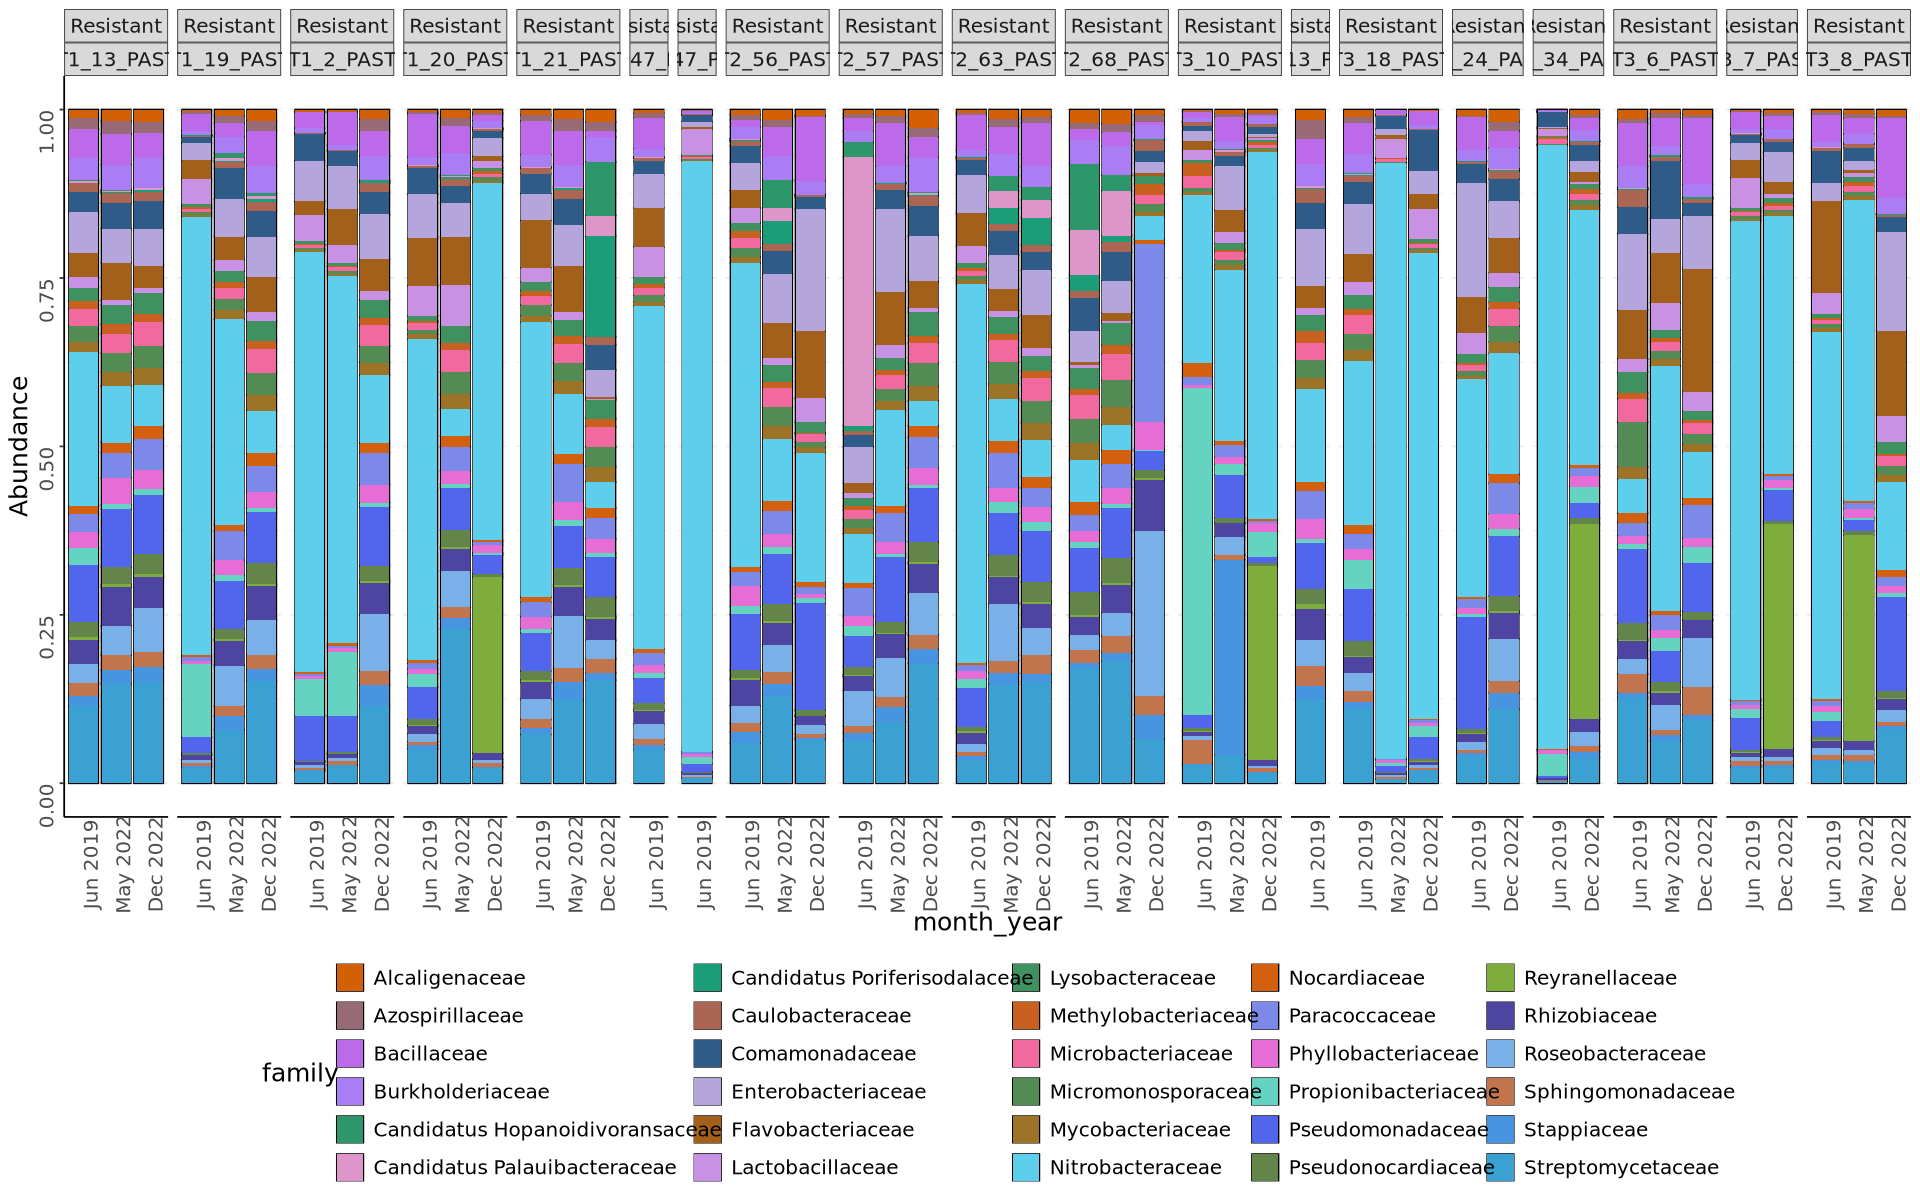

In [163]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_30_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 family - R vs S. individuals over time 

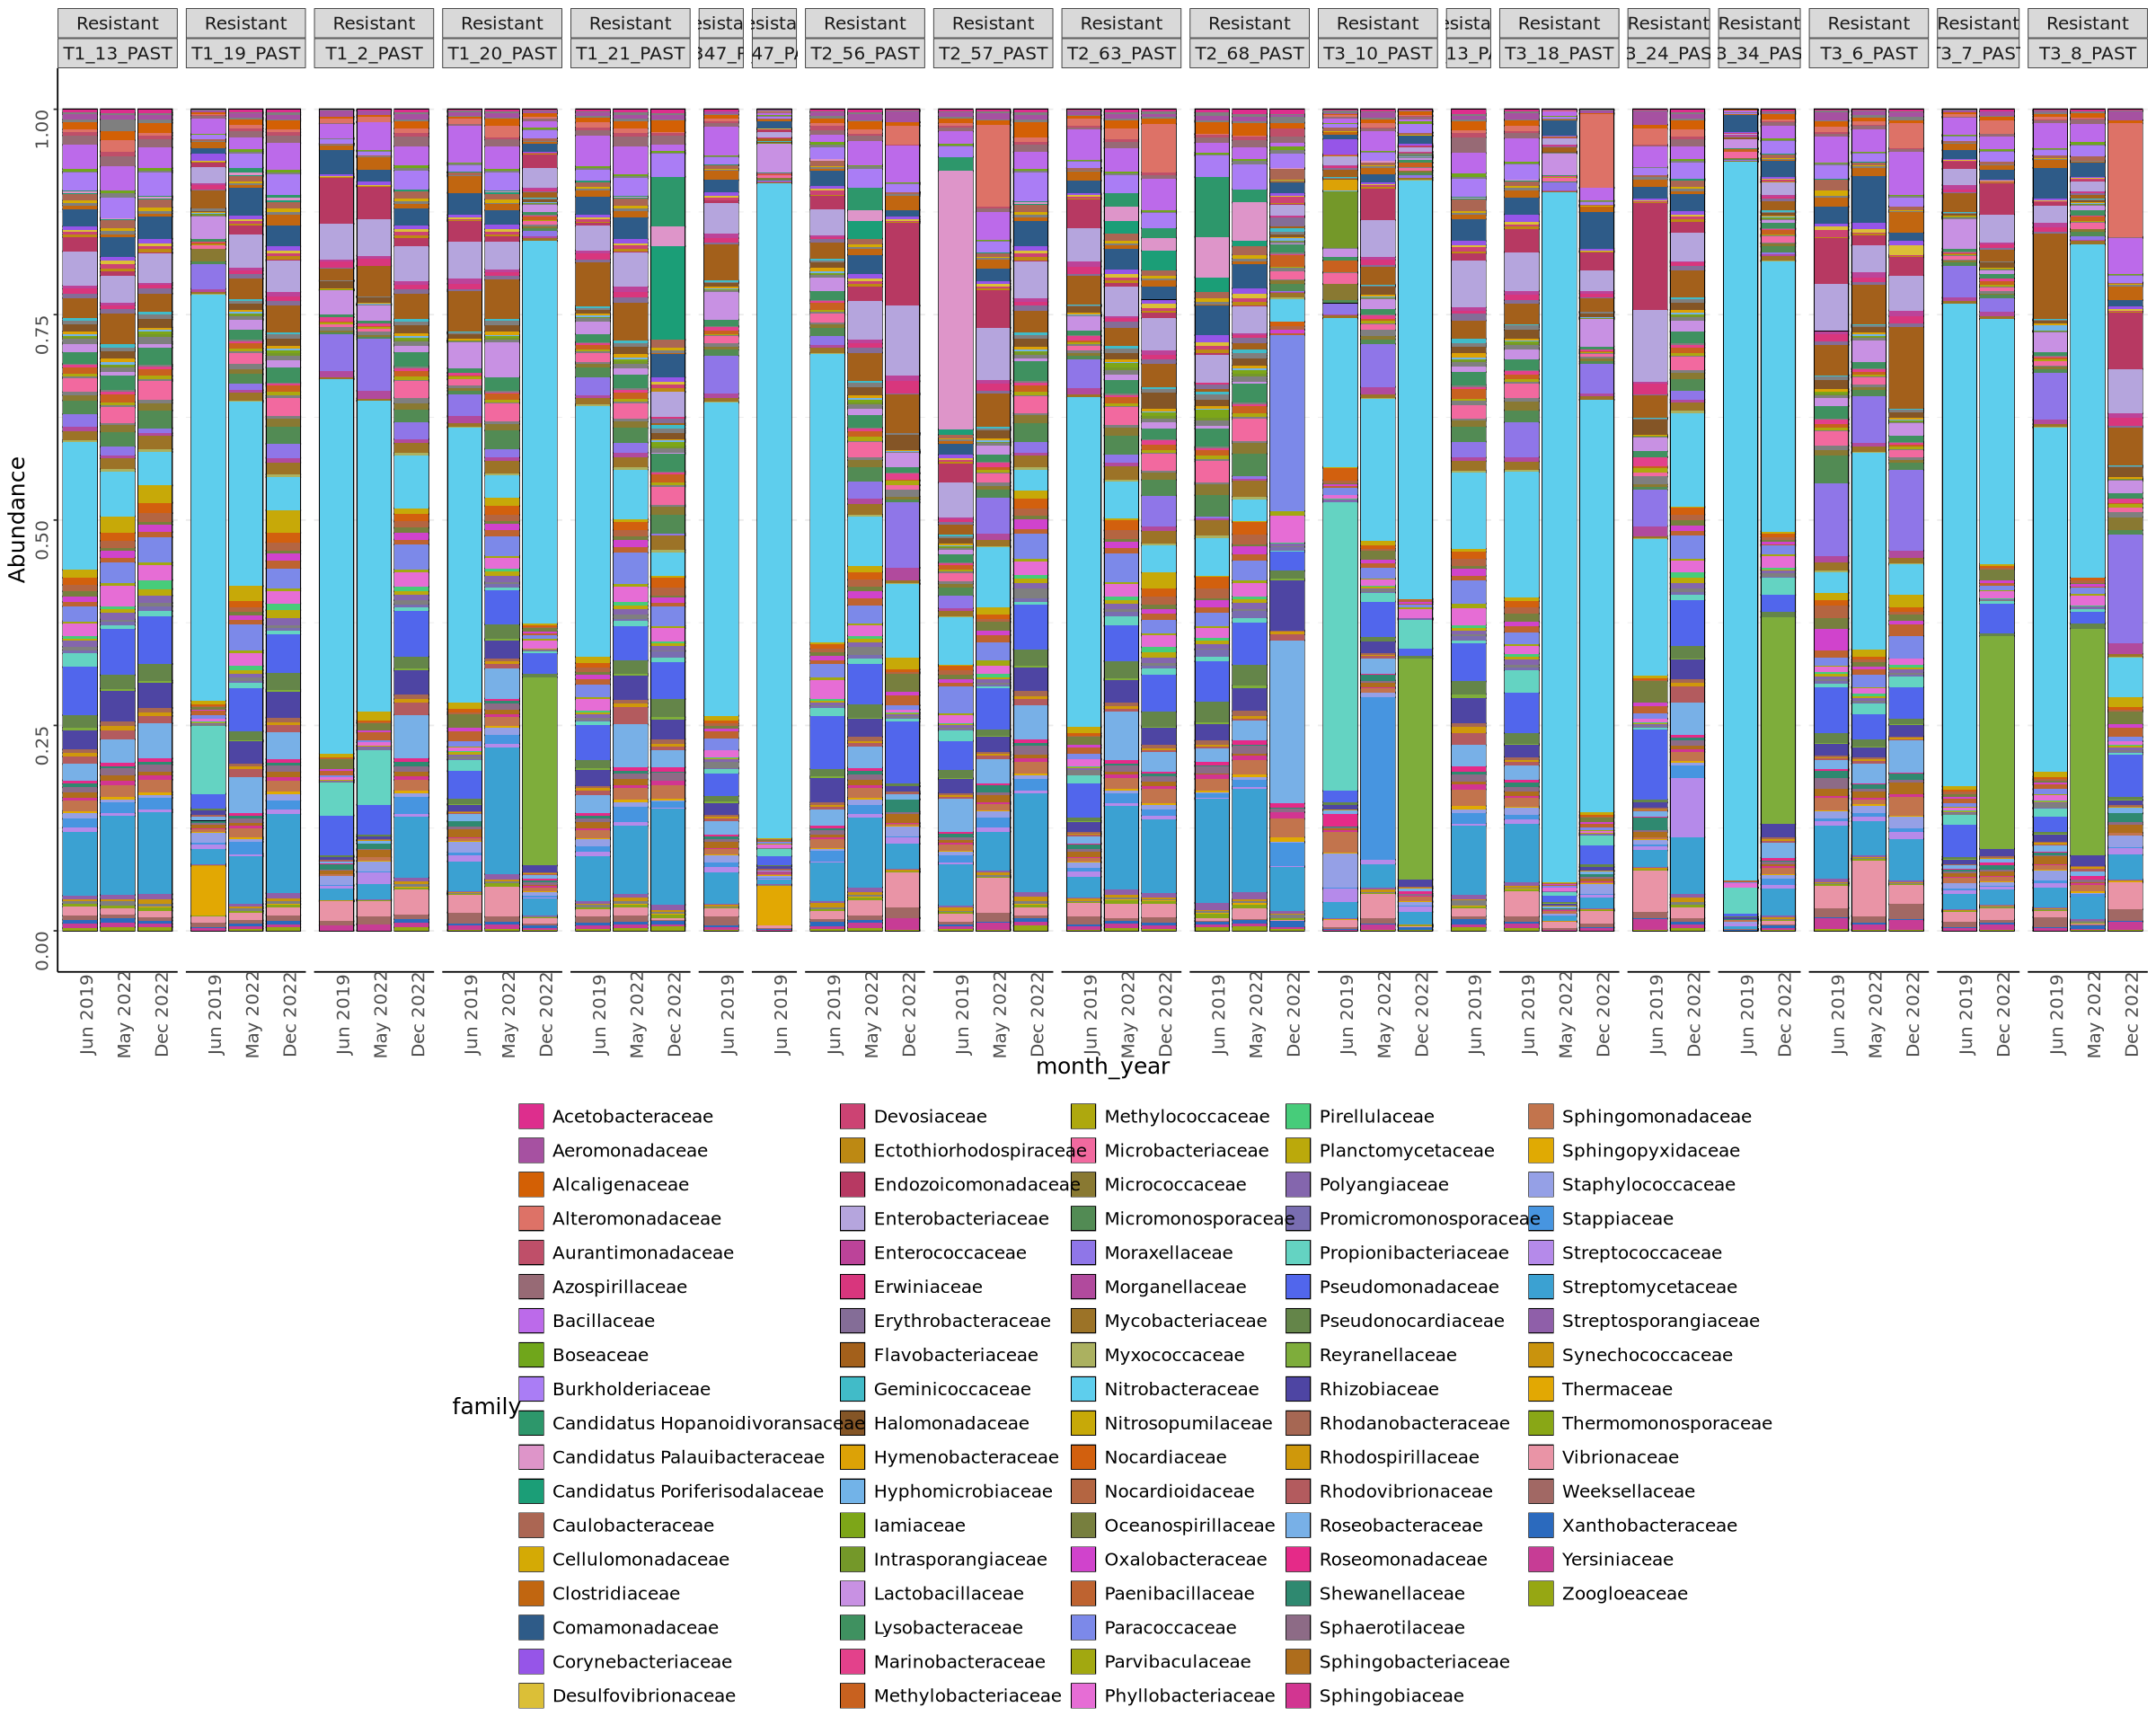

In [164]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PAST_100_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (family)

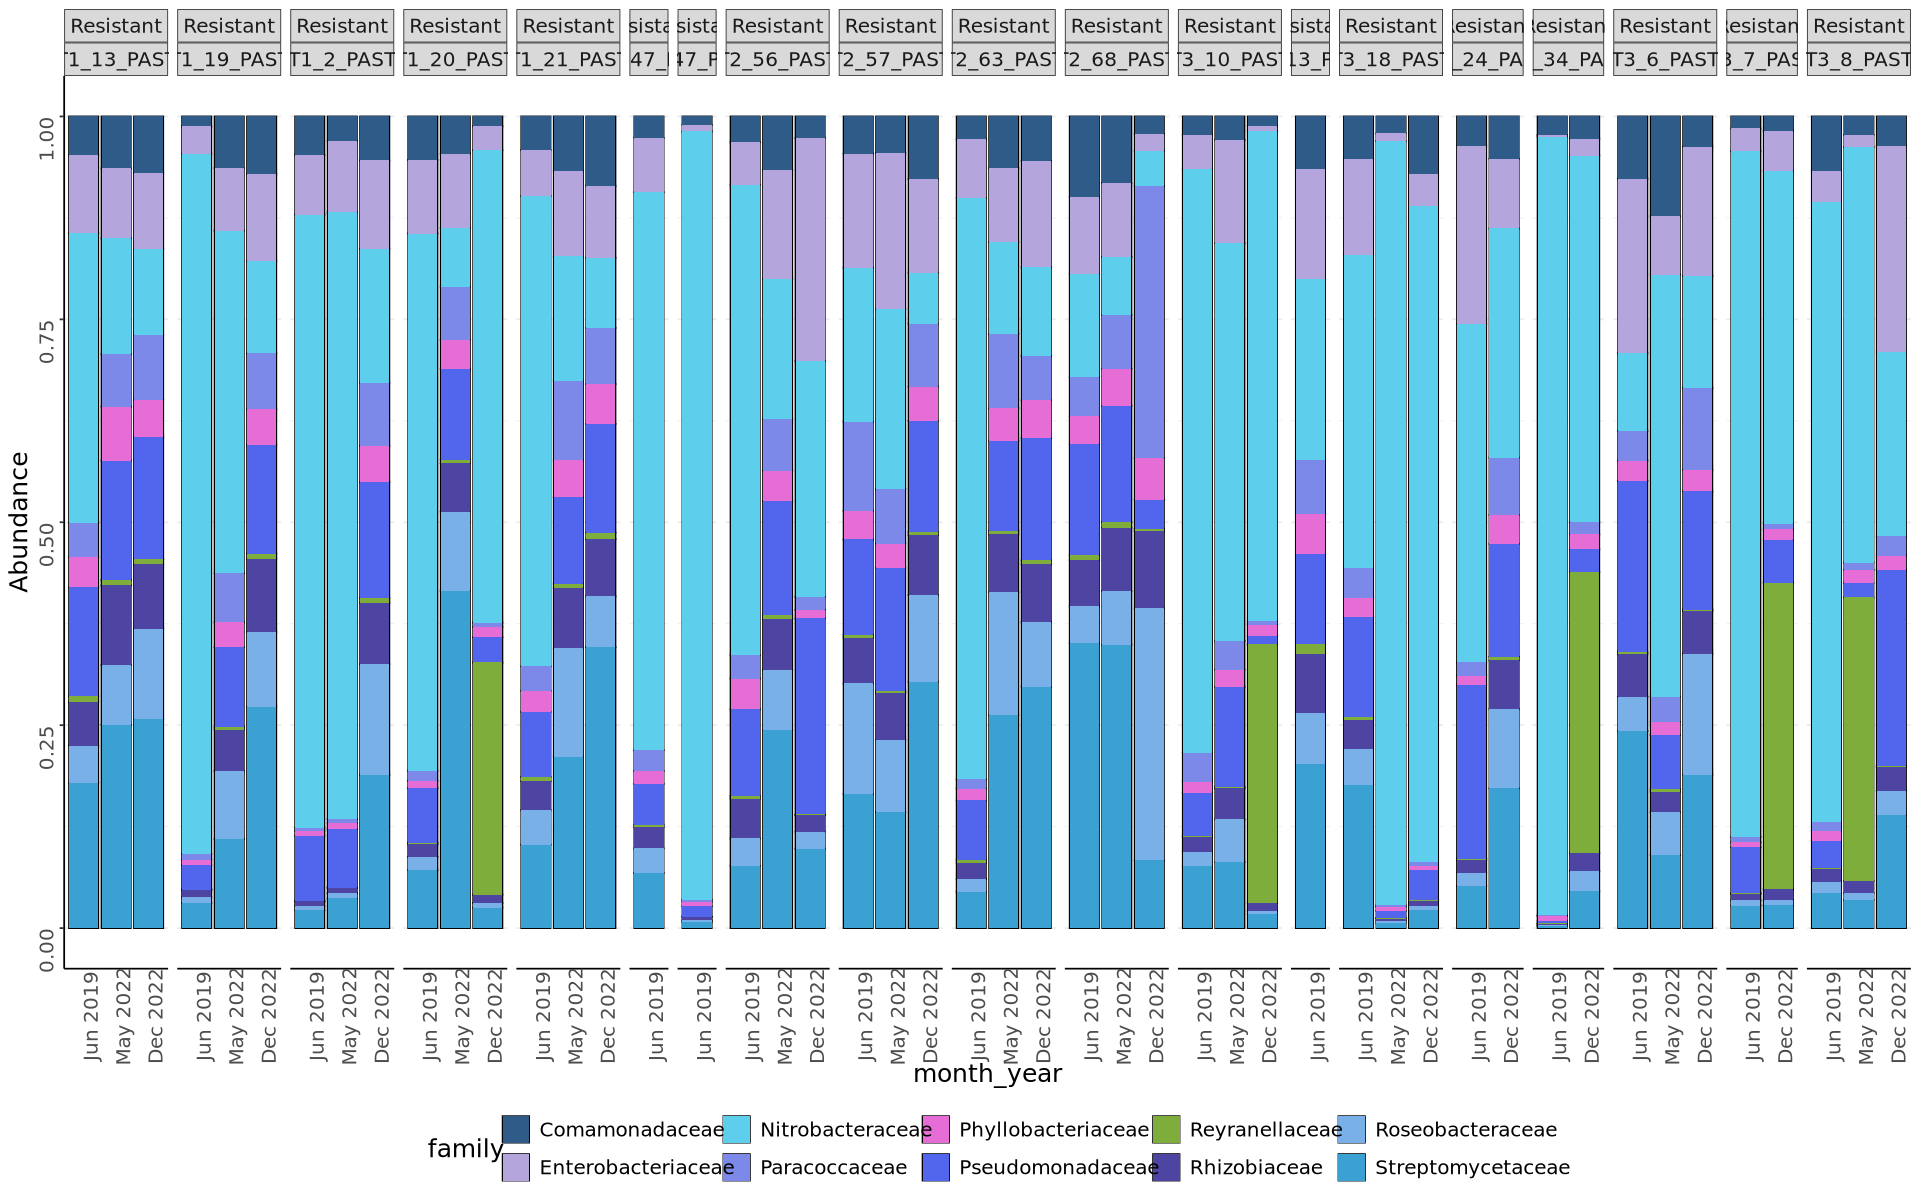

In [165]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_10_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (species)

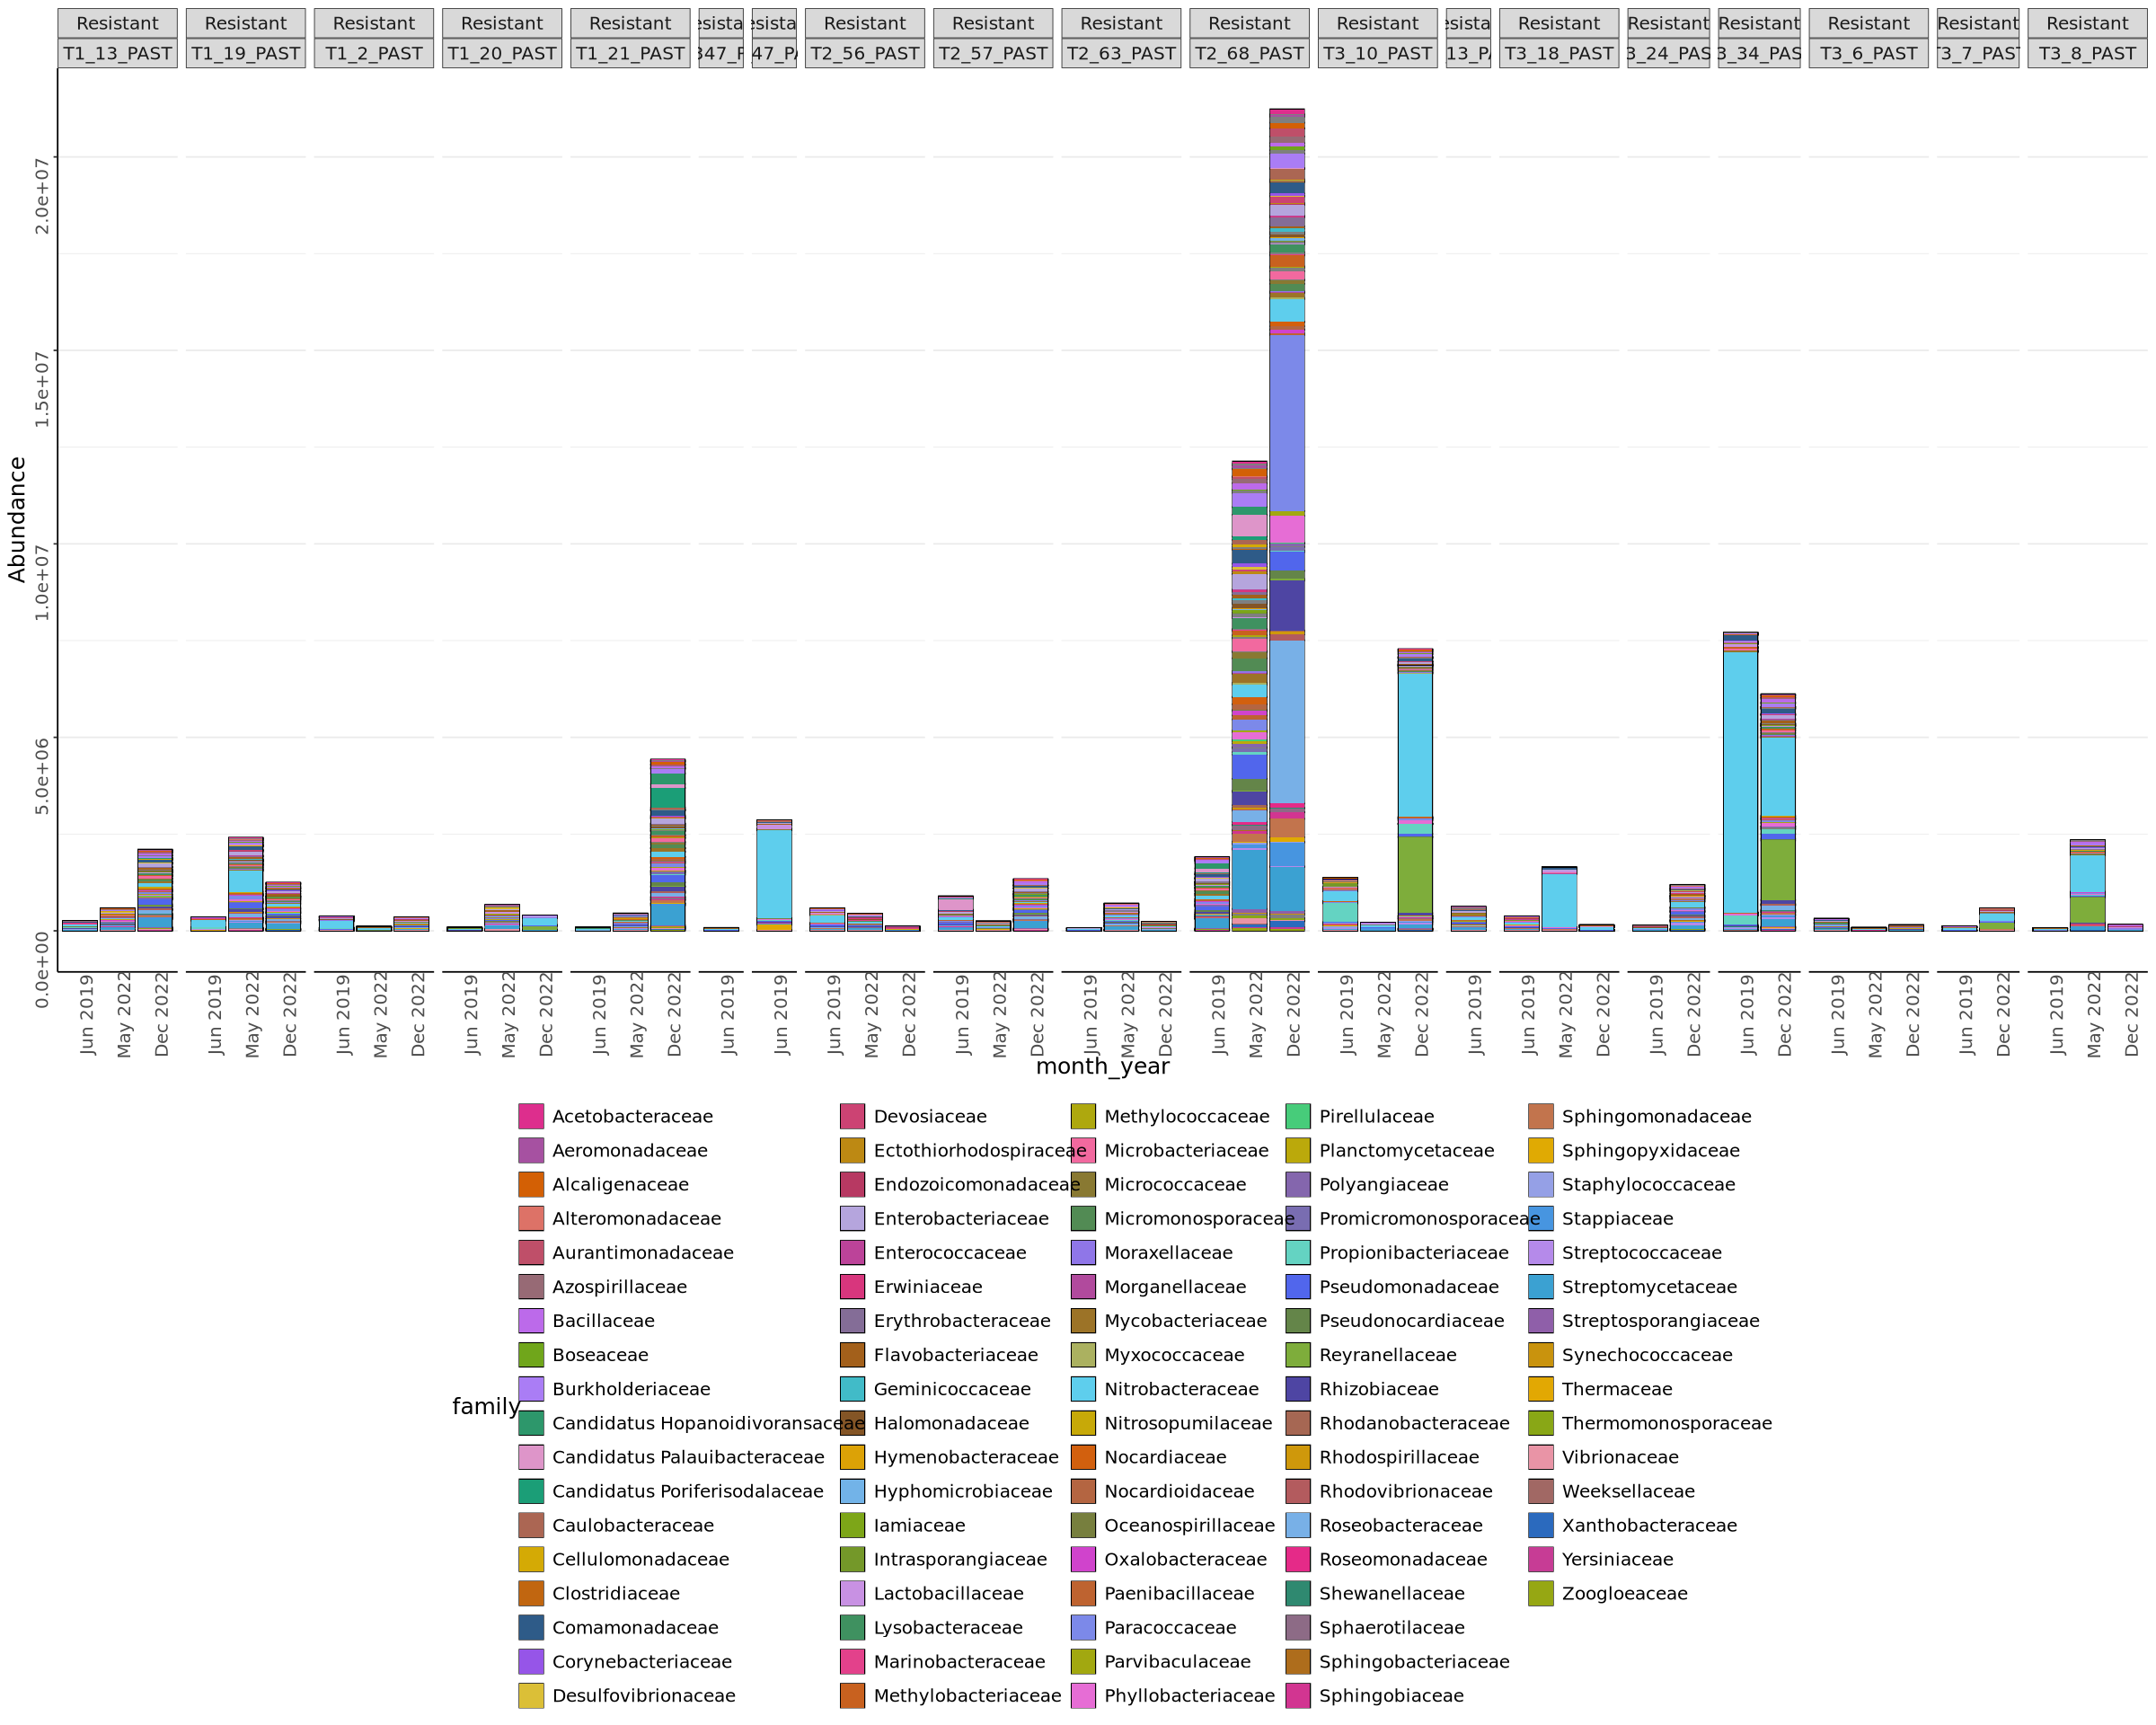

In [166]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PAST_100,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (family)

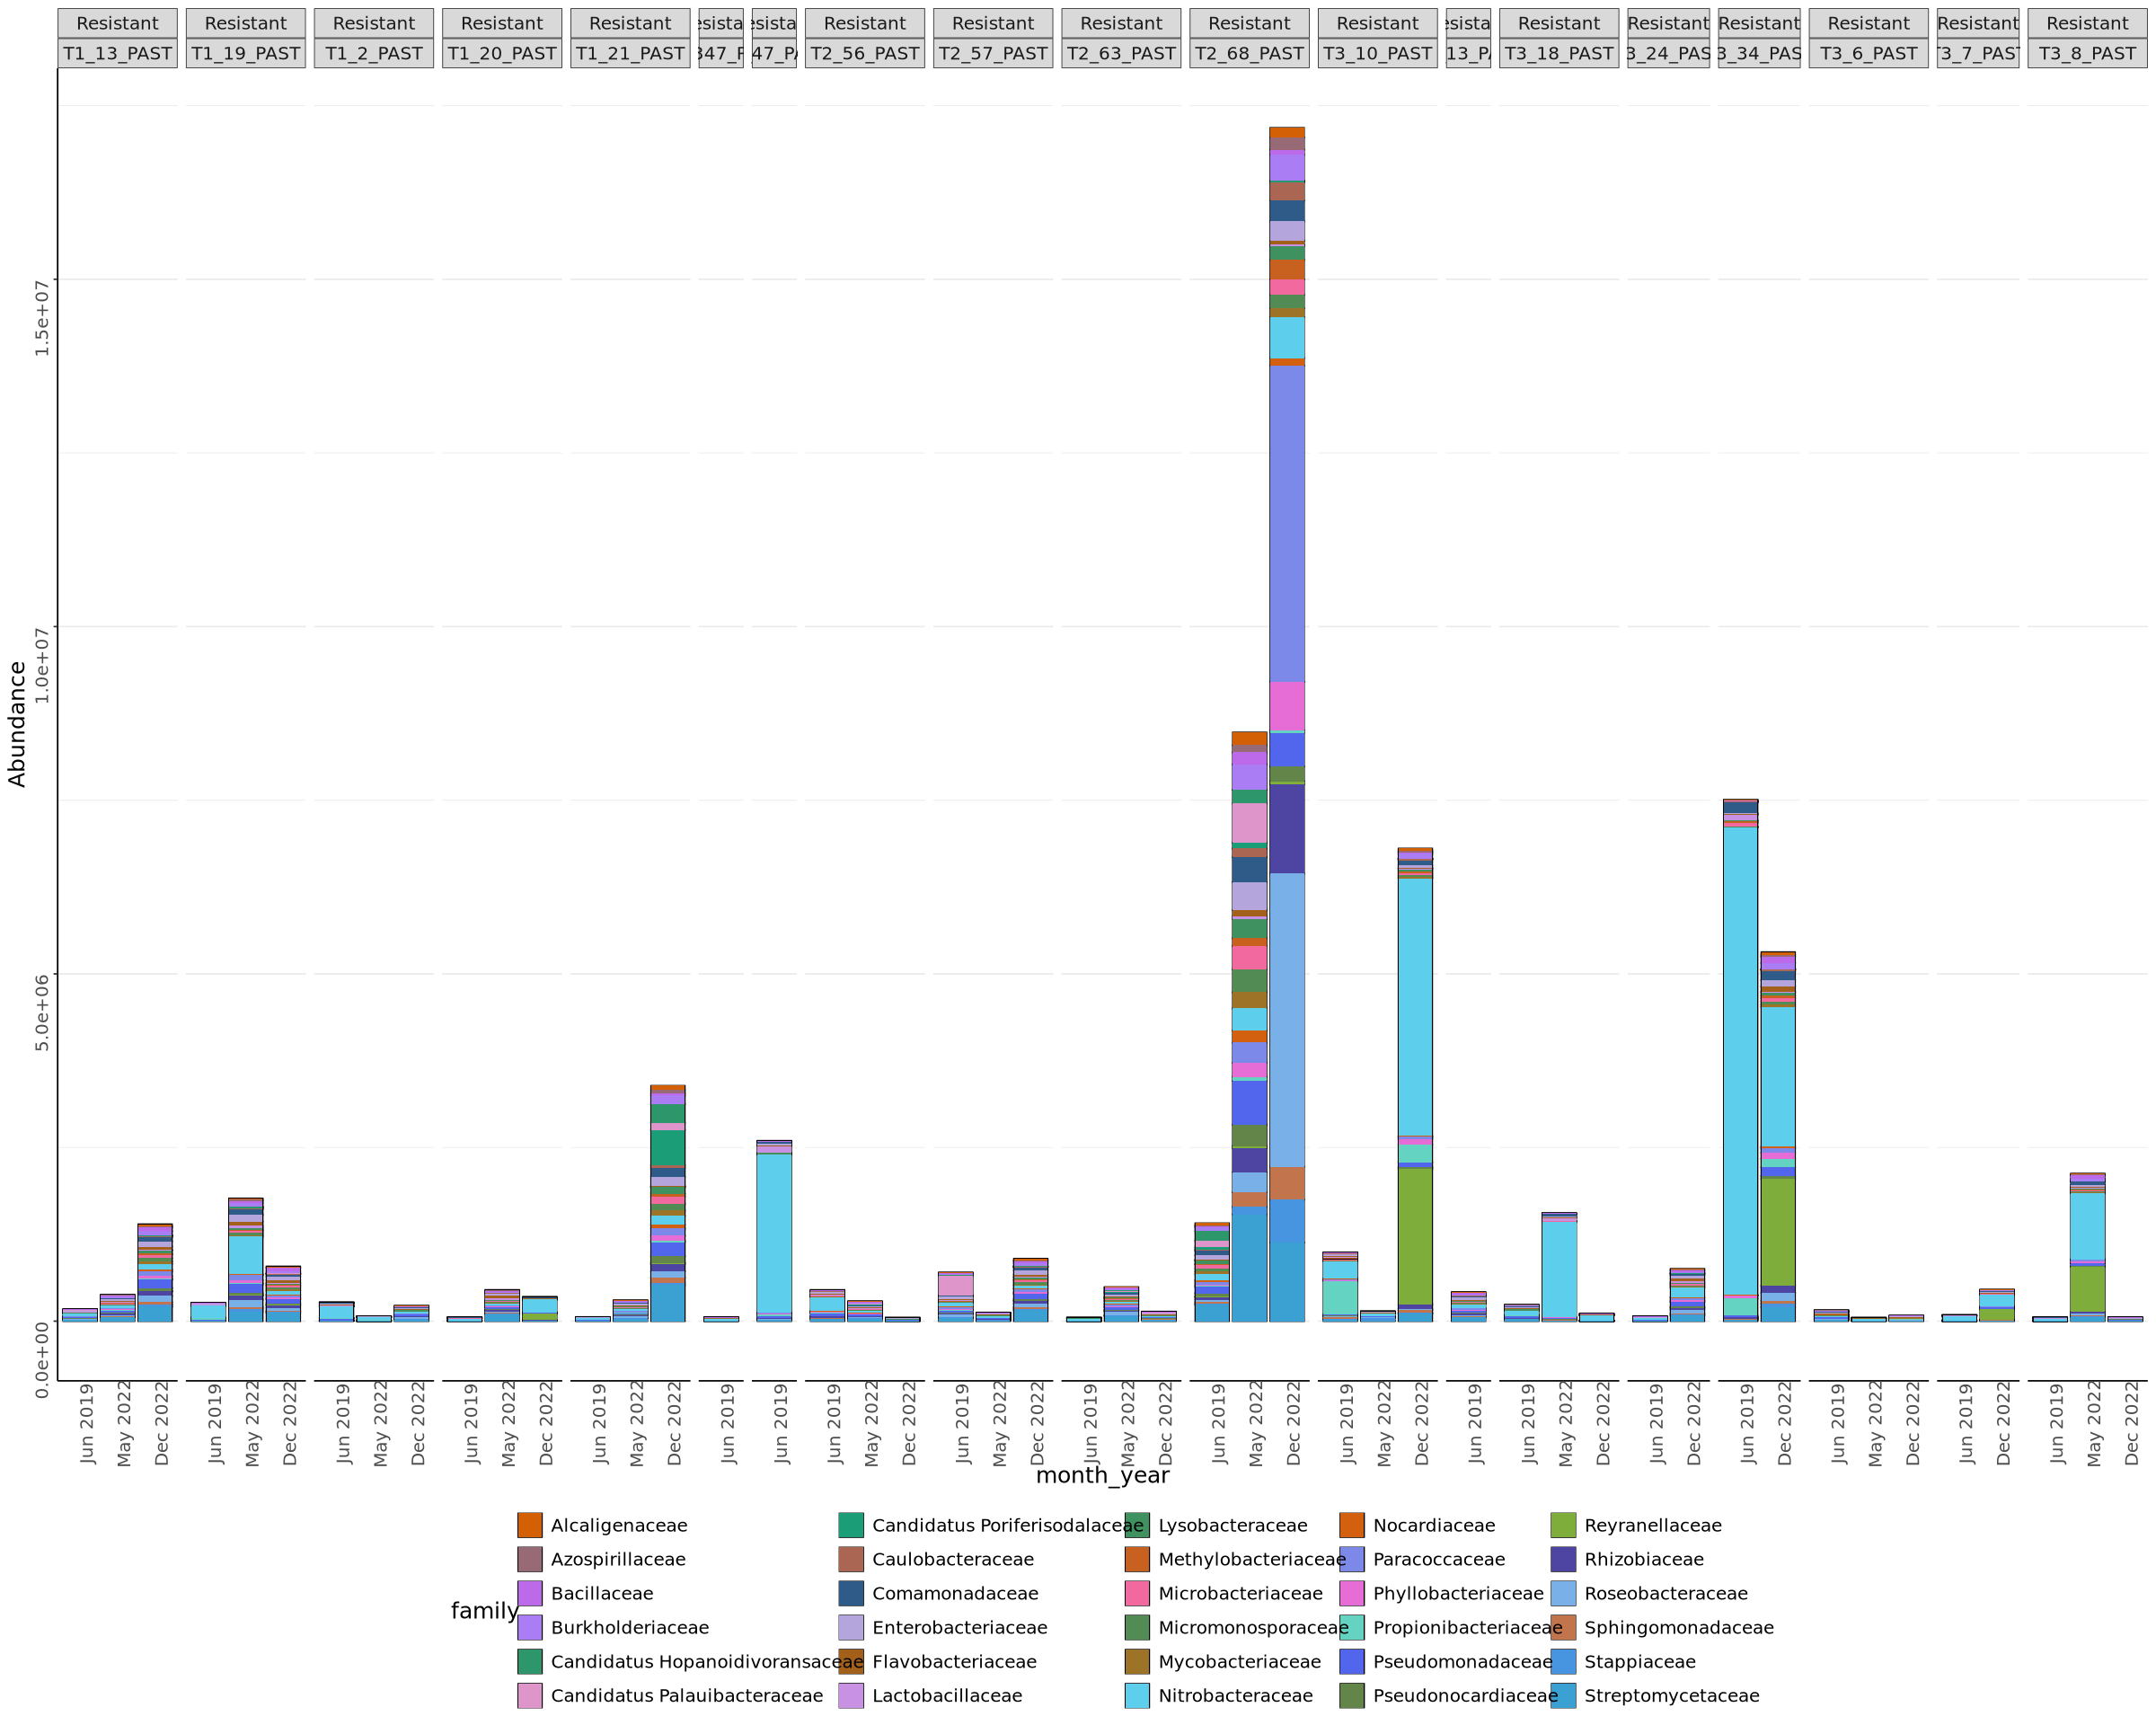

In [167]:
p<-plot_bar(PAST_30,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (family)